# Trabalho Data Processing with Python

Integrantes:

Matheus Sarafyan - RM368700

Camila Jenifer Mattos - RM369016

Olivia Mantovani Sampaio Barros - RM367570

Matheus Boffo de Sousa - RM367309

### Enunciado

A QuantumFinance possui um modelo de risco de crédito desatualizado, que tem concedido cartões para um número muito alto de mau pagadores e gerando problemas financeiros para a companhia.

O objetivo é realizar uma análise exploratória para compreender o comportamento dos dados e tentar descobrir um padrão que explique e diferencie clientes bons de maus pagadores.

Seu trabalho é:

1. Explorar e analisar os dados para entender a distribuição das características e a relação com a classificação de cada cliente. (5 pontos)

2. Responder as seguintes perguntas (5 pontos):

    * Como as features sexo, estado civil, quantidade de dependentes e nível educacional está relacionada com a variável meta?
    * Plote um gráfico que mostre a distribuição de bons e maus pagadores por estado. Escolha o gráfico que achar mais conveniente
    * Use boxplot para explicar como o tipo de residência interfere na classificação do pagador
    * Como as features renda pessoal mensal e outras rendas se relacionam com a variável meta? (obs: não é correlação estatística)
    * A idade interfere na classificação do pagador?

#### Entregáveis:

Jupyter Notebook:  O notebook deverá estar bem organizado com seções claras e textos que facilitem a compreensão da análise e decisões tomadas e que permita a obtenção do resultado final a partir do dataset disponibilizado. **NÃO SERÃO ACEITOS OUTROS FORMATOS**

Para subir no portal, compacte o arquivo em formato .zip. 


In [9]:

%pip install -q pandas numpy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


In [11]:

# %% Definição do cabeçalho (54 colunas) conforme especificação
cols = [
    'ID_CLIENTE','TIPO_FUNCIONARIO','DIA_PAGAMENTO','TIPO_ENVIO_APLICACAO','QUANT_CARTOES_ADICIONAIS','TIPO_ENDERECO_POSTAL','SEXO','ESTADO_CIVIL','QUANT_DEPENDENTES','NIVEL_EDUCACIONAL',
    'ESTADO_NASCIMENTO','CIDADE_NASCIMENTO','NACIONALIDADE','ESTADO_RESIDENCIA','CIDADE_RESIDENCIA','BAIRRO_RESIDENCIAL','FLAG_TELEFONE_RESIDENCIAL','CODIGO_AREA_TELEFONE_RESIDENCIAL','TIPO_RESIDENCIA','MESES_RESIDENCIA',
    'FLAG_TELEFONE_MOVEL','FLAG_EMAIL','RENDA_PESSOAL_MENSAL','OUTRAS_RENDAS','FLAG_VISA','FLAG_MASTERCARD','FLAG_DINERS','FLAG_AMERICAN_EXPRESS','FLAG_OUTROS_CARTOES','QUANT_CONTAS_BANCARIAS',
    'QUANT_CONTAS_BANCARIAS_ESPECIAIS','VALOR_PATRIMONIO_PESSOAL','QUANT_CARROS','EMPRESA','ESTADO_PROFISSIONAL','CIDADE_PROFISSIONAL','BAIRRO_PROFISSIONAL','FLAG_TELEFONE_PROFISSIONAL','CODIGO_AREA_TELEFONE_PROFISSIONAL','MESES_NO_TRABALHO',
    'CODIGO_PROFISSAO','TIPO_OCUPACAO','CODIGO_PROFISSAO_CONJUGE','NIVEL_EDUCACIONAL_CONJUGE','FLAG_DOCUMENTO_RESIDENCIAL','FLAG_RG','FLAG_CPF','FLAG_COMPROVANTE_RENDA','PRODUTO','FLAG_REGISTRO_ACSP',
    'IDADE','CEP_RESIDENCIAL_3','CEP_PROFISSIONAL_3','ROTULO_ALVO_MAU_1'
]
len(cols)  # deve retornar 54


54

In [12]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv", encoding='unicode_escape', sep='\t', header=None)
df.columns = cols
df.head()

,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL_3,CEP_PROFISSIONAL_3,ROTULO_ALVO_MAU_1
0,1,C,5,Web,0,1,F,6,1,0,...,0,0,0,0,1,N,32,595,595,1
1,2,C,15,Carga,0,1,F,2,0,0,...,0,0,0,0,1,N,34,230,230,1
2,3,C,5,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,27,591,591,0
3,4,C,20,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,61,545,545,0
4,5,C,10,Web,0,1,M,2,0,0,...,0,0,0,0,1,N,48,235,235,1


In [13]:
# %% Checagens rápidas
# 4.1) Amostra
display(df.sample(5, random_state=42))

# 4.2) Tipos atuais
print('Tipos atuais:')
display(df.dtypes)

# 4.3) Nulos por coluna
print('Valores nulos por coluna:')
display(df.isna().sum())

# 4.4) Distribuição do rótulo (ROTULO_ALVO_MAU_1)
if 'ROTULO_ALVO_MAU_1' in df.columns:
    print('Distribuição do rótulo ROTULO_ALVO_MAU_1:')
    display(df['ROTULO_ALVO_MAU_1'].value_counts(dropna=False))
else:
    print('A coluna ROTULO_ALVO_MAU_1 não foi encontrada.')

# 4.5) Sugestão de conversões leves (sem risco)
#    Observação: usamos errors='ignore' para não quebrar caso a coluna seja mista.
#    Se preferir forçar, substitua por 'coerce' e trate os NaNs resultantes.

# Flags binárias: tentar int (0/1) ou category
flags_binarias = [
    'FLAG_TELEFONE_RESIDENCIAL','FLAG_TELEFONE_MOVEL','FLAG_EMAIL',
    'FLAG_VISA','FLAG_MASTERCARD','FLAG_DINERS','FLAG_AMERICAN_EXPRESS',
    'FLAG_OUTROS_CARTOES','FLAG_TELEFONE_PROFISSIONAL',
    'FLAG_DOCUMENTO_RESIDENCIAL','FLAG_RG','FLAG_CPF',
    'FLAG_COMPROVANTE_RENDA','FLAG_REGISTRO_ACSP'
]
for col in flags_binarias:
    if col in df.columns:
        # tenta converter para inteiro; se não der, mantém como está
        df[col] = pd.to_numeric(df[col], errors='ignore')
        # se ficar numérico, converter para category para economizar memória
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].astype('category')

# Códigos/IDs que fazem sentido como string/category
codigos_categoricos = [
    'ID_CLIENTE','TIPO_FUNCIONARIO','TIPO_ENVIO_APLICACAO','TIPO_ENDERECO_POSTAL',
    'SEXO','ESTADO_CIVIL','NIVEL_EDUCACIONAL','ESTADO_NASCIMENTO','CIDADE_NASCIMENTO',
    'NACIONALIDADE','ESTADO_RESIDENCIA','CIDADE_RESIDENCIA','BAIRRO_RESIDENCIAL',
    'CODIGO_AREA_TELEFONE_RESIDENCIAL','TIPO_RESIDENCIA',
    'EMPRESA','ESTADO_PROFISSIONAL','CIDADE_PROFISSIONAL','BAIRRO_PROFISSIONAL',
    'CODIGO_AREA_TELEFONE_PROFISSIONAL','CODIGO_PROFISSAO','TIPO_OCUPACAO',
    'CODIGO_PROFISSAO_CONJUGE','NIVEL_EDUCACIONAL_CONJUGE',
    'PRODUTO','CEP_RESIDENCIAL_3','CEP_PROFISSIONAL_3'
]
for col in codigos_categoricos:
    if col in df.columns:
        df[col] = df[col].astype('string')
        # converter para category se desejar economizar memória
        df[col] = df[col].astype('category')

# 4.6) Estatísticas descritivas rápidas para numéricos
print('Estatísticas descritivas (numéricos):')
display(df.describe(include='number'))

# 4.7) Cardinalidade para categóricos
print('Cardinalidade de variáveis categóricas (top 10):')
for col in df.select_dtypes(include='category').columns[:10]:
    print(f'[{col}] nº de categorias:', df[col].nunique())

,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL_3,CEP_PROFISSIONAL_3,ROTULO_ALVO_MAU_1
33553,33554,C,20,0,0,1,F,2,0,0,...,0,0,0,0,2,N,32,520,520,1
9427,9428,C,10,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,67,563,563,0
199,200,C,25,Web,0,1,M,2,0,0,...,0,0,0,0,2,N,53,322,322,0
12447,12448,C,15,0,0,1,F,2,0,0,...,0,0,0,0,2,N,56,291,291,0
39489,39490,C,10,Web,0,1,F,5,2,0,...,0,0,0,0,1,N,49,780,780,1


Tipos atuais:


ID_CLIENTE                             int64
TIPO_FUNCIONARIO                      object
DIA_PAGAMENTO                          int64
TIPO_ENVIO_APLICACAO                  object
QUANT_CARTOES_ADICIONAIS               int64
TIPO_ENDERECO_POSTAL                   int64
SEXO                                  object
ESTADO_CIVIL                           int64
QUANT_DEPENDENTES                      int64
NIVEL_EDUCACIONAL                      int64
ESTADO_NASCIMENTO                     object
CIDADE_NASCIMENTO                     object
NACIONALIDADE                          int64
ESTADO_RESIDENCIA                     object
CIDADE_RESIDENCIA                     object
BAIRRO_RESIDENCIAL                    object
FLAG_TELEFONE_RESIDENCIAL             object
CODIGO_AREA_TELEFONE_RESIDENCIAL      object
TIPO_RESIDENCIA                      float64
MESES_RESIDENCIA                     float64
FLAG_TELEFONE_MOVEL                   object
FLAG_EMAIL                             int64
RENDA_PESS

Valores nulos por coluna:


ID_CLIENTE                               0
TIPO_FUNCIONARIO                         0
DIA_PAGAMENTO                            0
TIPO_ENVIO_APLICACAO                     0
QUANT_CARTOES_ADICIONAIS                 0
TIPO_ENDERECO_POSTAL                     0
SEXO                                     0
ESTADO_CIVIL                             0
QUANT_DEPENDENTES                        0
NIVEL_EDUCACIONAL                        0
ESTADO_NASCIMENTO                        0
CIDADE_NASCIMENTO                        0
NACIONALIDADE                            0
ESTADO_RESIDENCIA                        0
CIDADE_RESIDENCIA                        0
BAIRRO_RESIDENCIAL                       0
FLAG_TELEFONE_RESIDENCIAL                0
CODIGO_AREA_TELEFONE_RESIDENCIAL         0
TIPO_RESIDENCIA                       1349
MESES_RESIDENCIA                      3777
FLAG_TELEFONE_MOVEL                      0
FLAG_EMAIL                               0
RENDA_PESSOAL_MENSAL                     0
OUTRAS_REND

Distribuição do rótulo ROTULO_ALVO_MAU_1:


ROTULO_ALVO_MAU_1
0    36959
1    13041
Name: count, dtype: int64

Estatísticas descritivas (numéricos):


,DIA_PAGAMENTO,QUANT_CARTOES_ADICIONAIS,QUANT_DEPENDENTES,MESES_RESIDENCIA,RENDA_PESSOAL_MENSAL,OUTRAS_RENDAS,QUANT_CONTAS_BANCARIAS,QUANT_CONTAS_BANCARIAS_ESPECIAIS,VALOR_PATRIMONIO_PESSOAL,QUANT_CARROS,MESES_NO_TRABALHO,IDADE,ROTULO_ALVO_MAU_1
count,50000.000000,50000.0,50000.000000,46223.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.00000,50000.000000
mean,12.869920,0.0,0.650520,9.727149,886.678437,35.434760,0.357840,0.357840,2.322372e+03,0.336140,0.009320,43.24852,0.260820
std,6.608385,0.0,1.193655,10.668841,7846.959327,891.515142,0.479953,0.479953,4.235798e+04,0.472392,0.383453,14.98905,0.439086
min,1.000000,0.0,0.000000,0.000000,60.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,6.00000,0.000000
25%,10.000000,0.0,0.000000,1.000000,360.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,31.00000,0.000000
50%,10.000000,0.0,0.000000,6.000000,500.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,41.00000,0.000000
75%,15.000000,0.0,1.000000,15.000000,800.000000,0.000000,1.000000,1.000000,0.000000e+00,1.000000,0.000000,53.00000,1.000000
max,25.000000,0.0,53.000000,228.000000,959000.000000,194344.000000,2.000000,2.000000,6.000000e+06,1.000000,35.000000,106.00000,1.000000


Cardinalidade de variáveis categóricas (top 10):
[ID_CLIENTE] nº de categorias: 50000
[TIPO_FUNCIONARIO] nº de categorias: 1
[TIPO_ENVIO_APLICACAO] nº de categorias: 3
[TIPO_ENDERECO_POSTAL] nº de categorias: 2
[SEXO] nº de categorias: 4
[ESTADO_CIVIL] nº de categorias: 8
[NIVEL_EDUCACIONAL] nº de categorias: 1
[ESTADO_NASCIMENTO] nº de categorias: 29
[CIDADE_NASCIMENTO] nº de categorias: 9910
[NACIONALIDADE] nº de categorias: 3


In [14]:
# %% Salvar versão com cabeçalho
out_path = 'credit_with_header.csv'

# Escolha do separador no arquivo final:
# - vírgula (padrão CSV internacional):
# df.to_csv(out_path, index=False, sep=',')

# - ponto e vírgula (muito comum no Excel BR):
# df.to_csv(out_path, index=False, sep=';')

# Use uma das opções acima e comente a outra:
df.to_csv(out_path, index=False, sep=',')

print('Arquivo salvo em:', out_path)
print('Total de colunas gravadas:', len(df.columns))



Arquivo salvo em: credit_with_header.csv
Total de colunas gravadas: 54


# Parte 1. Exploração
Explorar e analisar os dados para entender a distribuição das características e a relação com a classificação de cada cliente

In [15]:

target = 'ROTULO_ALVO_MAU_1'  # 1=Mau pagador, 0=Bom pagador

# Garantir alvo numérico e categórico:
# - target_num: para agregações/medidas (corrige o TypeError da média sobre dtype 'category')
# - target_cat: para plots com hue
df[target] = pd.to_numeric(df[target], errors='coerce')  # 0/1
df['target_num'] = df[target].astype('int')              # int seguro para groupby/mean
df['target_cat'] = df['target_num'].astype('category')   # para gráficos

print('Dimensões:', df.shape)

Dimensões: (50000, 56)


Contagem por classe (0=BOM, 1=MAU):
target_num
0    36959
1    13041
Name: count, dtype: int64
Percentual MAU (1): 0.261


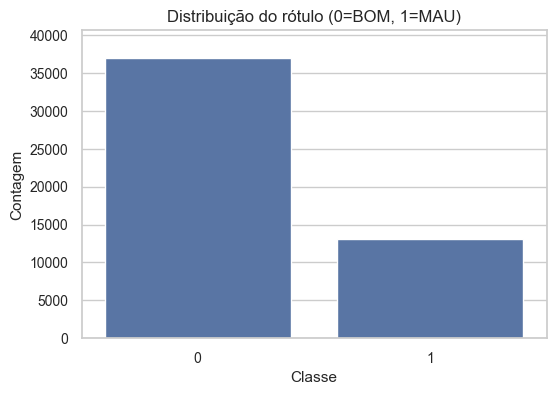

In [16]:
# %% Distribuição do alvo e interpretação
vc = df['target_num'].value_counts(dropna=False).sort_index()
total = vc.sum()
taxa_mau = (vc.get(1, 0) / total) if total else np.nan

print('Contagem por classe (0=BOM, 1=MAU):')
print(vc)
print(f'Percentual MAU (1): {taxa_mau:.3f}')

# Gráfico ajustando escala do eixo Y para caber bem (limite superior = 1.1x do máximo)
ax = sns.countplot(x=df['target_cat'])
ax.set_title('Distribuição do rótulo (0=BOM, 1=MAU)')
ax.set_xlabel('Classe')
ax.set_ylabel('Contagem')
ymax = vc.max() * 1.1
ax.set_ylim(0, ymax)
plt.show()

# Interpretação (comentários):
# - Em bases de crédito, MAU costuma ser minoria → problema desbalanceado.
# - Na modelagem, considerar class_weight, validação estratificada, e métricas como AUC-PR, F1 da classe 1.


Maus pagadores representam 26.1% da base total de clientes.

Preparação e escolha de variáveis numéricas e categóricas: Foram normalizadas para facilitar a EDA e evitar viés de outliers 

In [17]:
# %% Seleção de colunas e conversões numéricas
numeric_candidates = [
    'DIA_PAGAMENTO','QUANT_DEPENDENTES','MESES_RESIDENCIA',
    'RENDA_PESSOAL_MENSAL','OUTRAS_RENDAS','QUANT_CONTAS_BANCARIAS',
    'QUANT_CONTAS_BANCARIAS_ESPECIAIS','VALOR_PATRIMONIO_PESSOAL',
    'QUANT_CARROS','MESES_NO_TRABALHO','IDADE'
]
for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

num_cols = [c for c in numeric_candidates if c in df.columns]
cat_cols = [c for c in df.columns if c not in num_cols + [target, 'target_num', 'target_cat']]


Distribuições por classe (BOM vs MAU) com corte de outliers

[INFO] num_cols (12): ['DIA_PAGAMENTO', 'QUANT_CARTOES_ADICIONAIS', 'QUANT_DEPENDENTES', 'MESES_RESIDENCIA', 'RENDA_PESSOAL_MENSAL', 'OUTRAS_RENDAS', 'QUANT_CONTAS_BANCARIAS', 'QUANT_CONTAS_BANCARIAS_ESPECIAIS', 'VALOR_PATRIMONIO_PESSOAL', 'QUANT_CARROS', 'MESES_NO_TRABALHO', 'IDADE']
[INFO] cat_cols (10): ['TIPO_ENDERECO_POSTAL', 'SEXO', 'ESTADO_CIVIL', 'NIVEL_EDUCACIONAL', 'ESTADO_RESIDENCIA', 'CIDADE_RESIDENCIA', 'TIPO_RESIDENCIA', 'EMPRESA', 'CODIGO_PROFISSAO', 'TIPO_OCUPACAO']


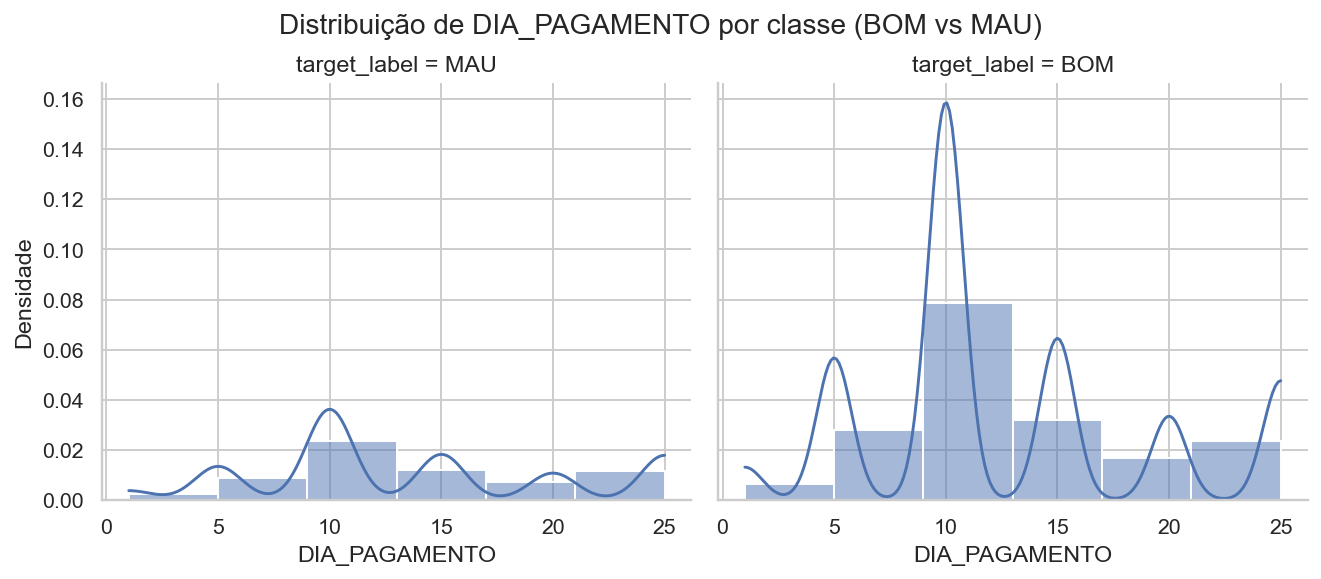

[INFO] KDE desativado em 'QUANT_CARTOES_ADICIONAIS' (amostra pequena/variância baixa).


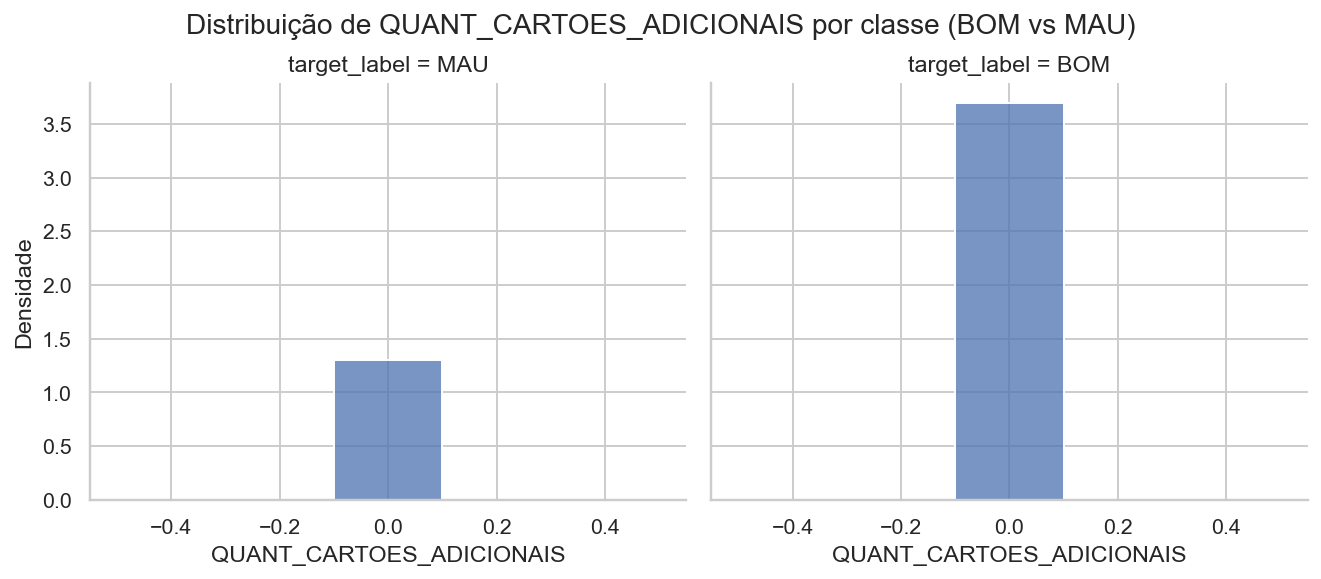

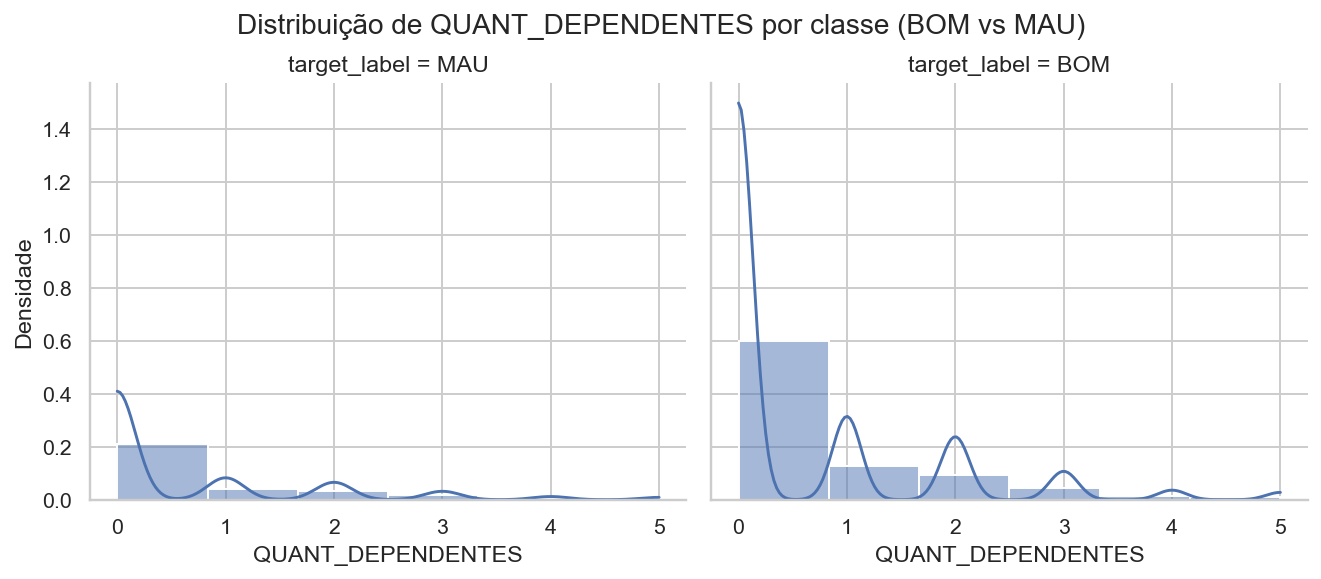

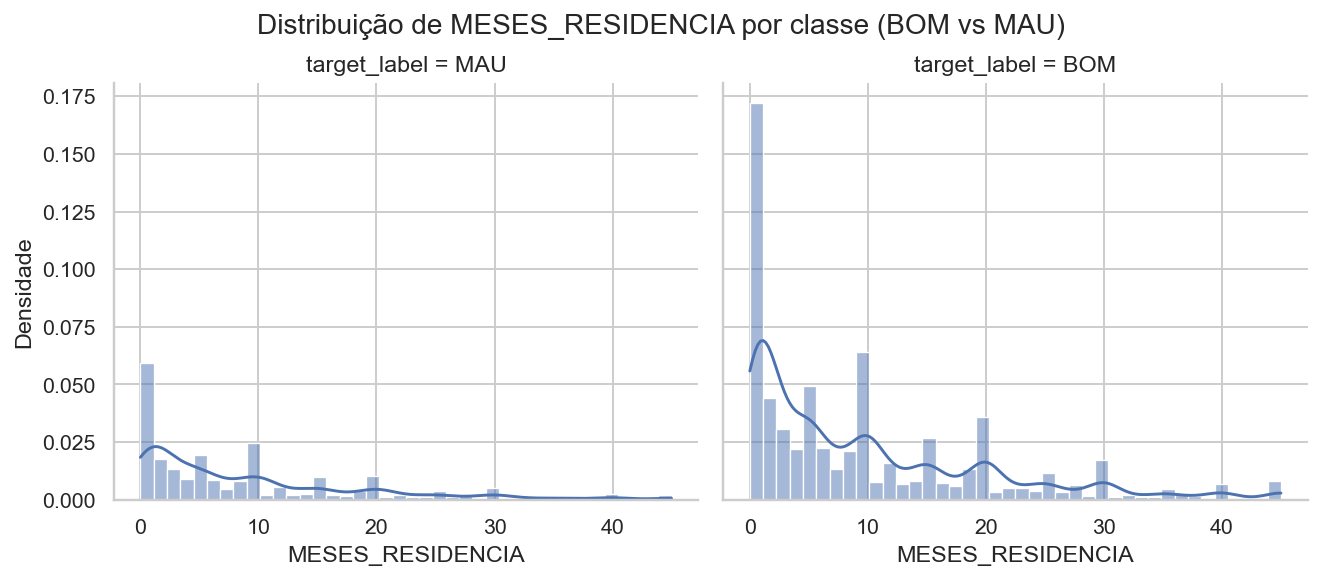

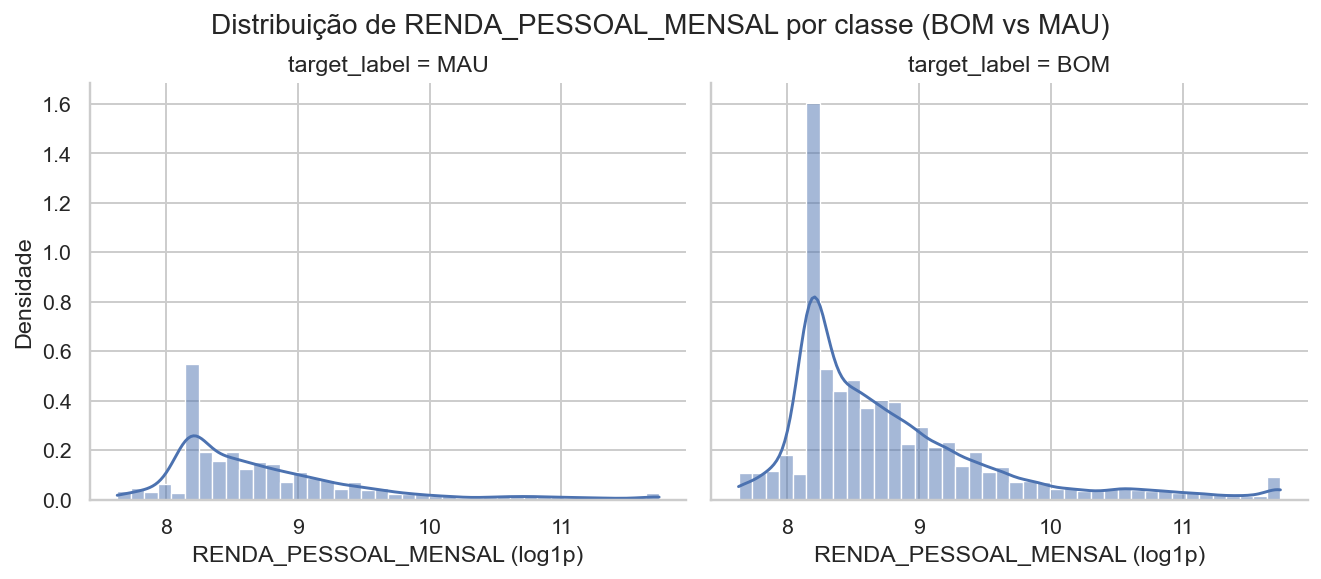

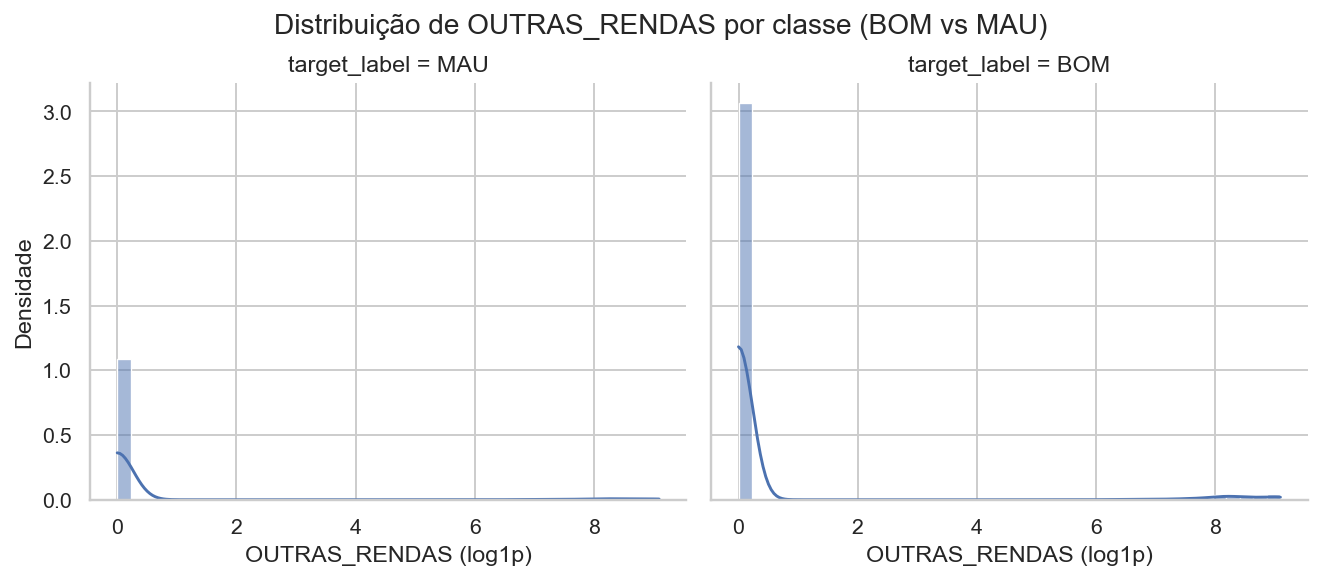

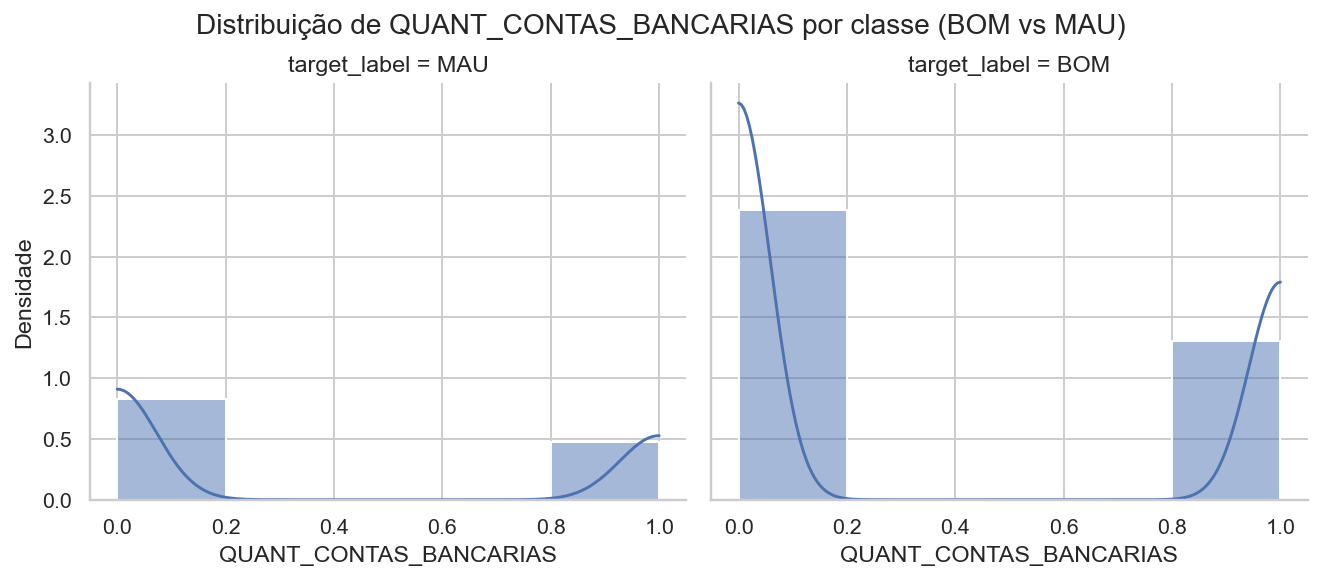

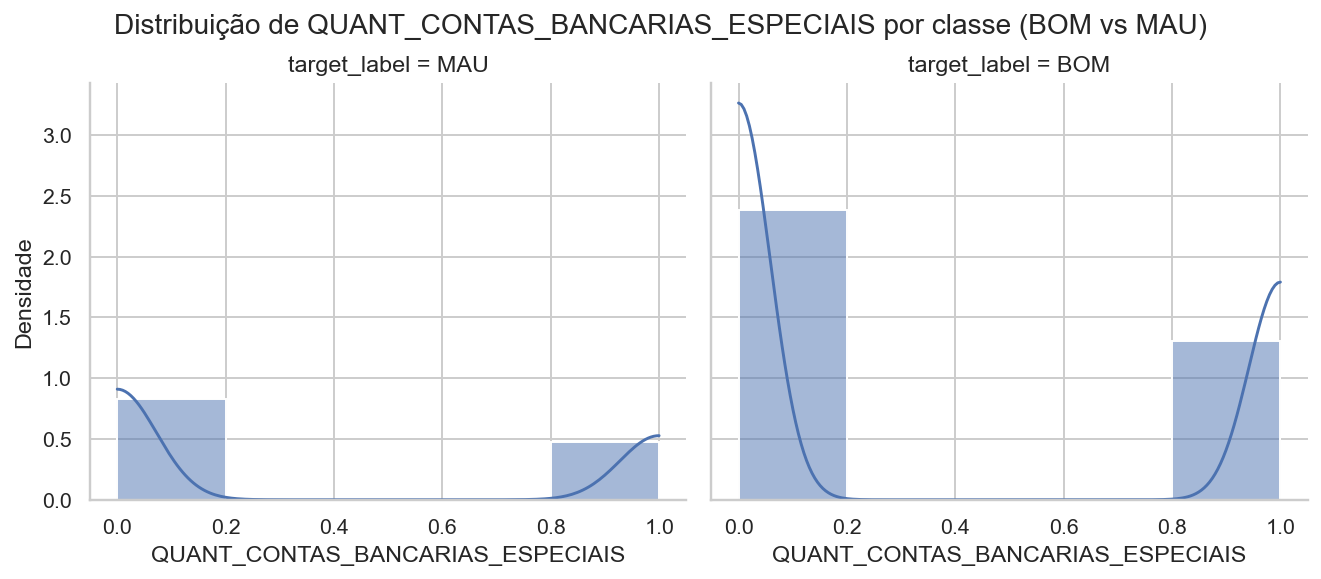

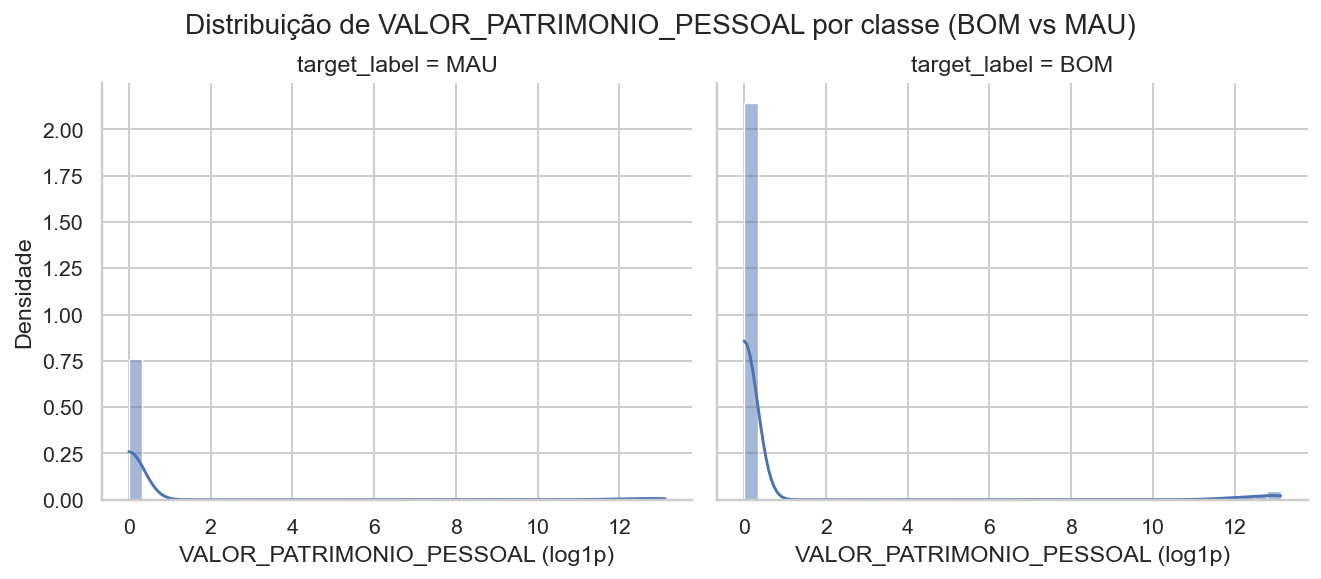

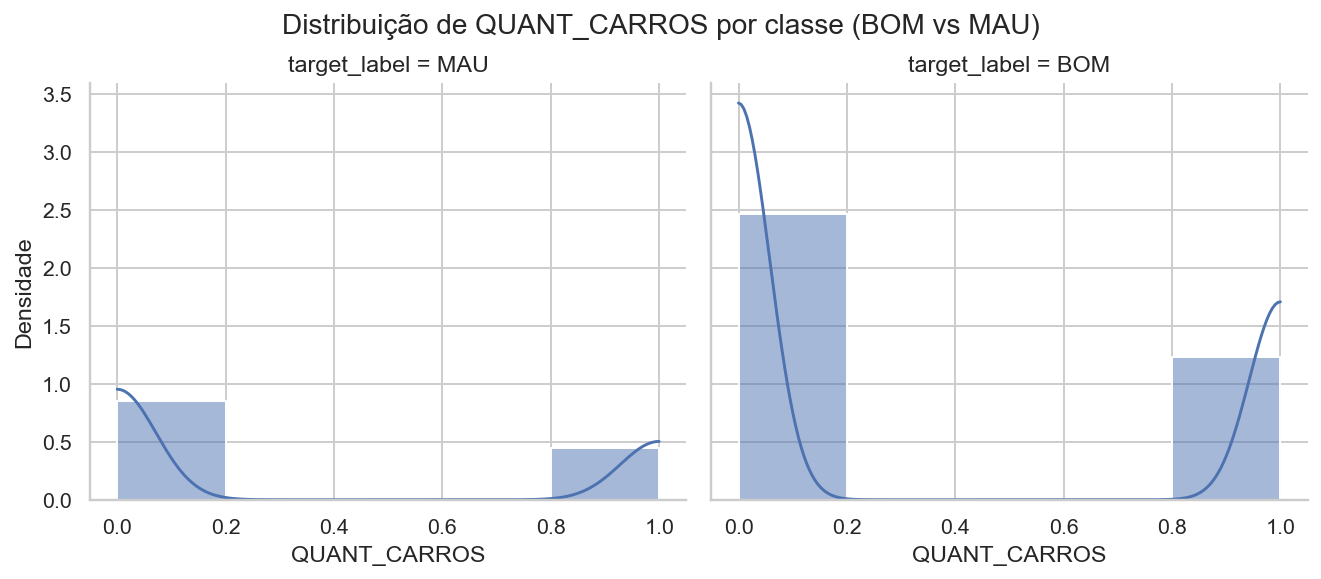

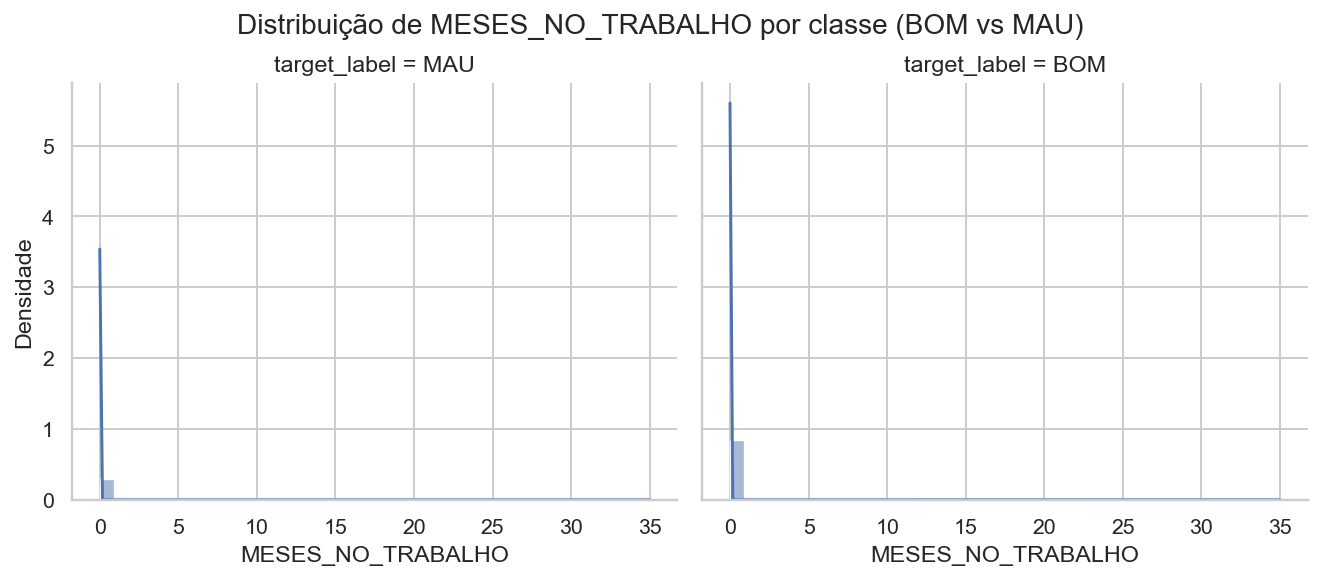

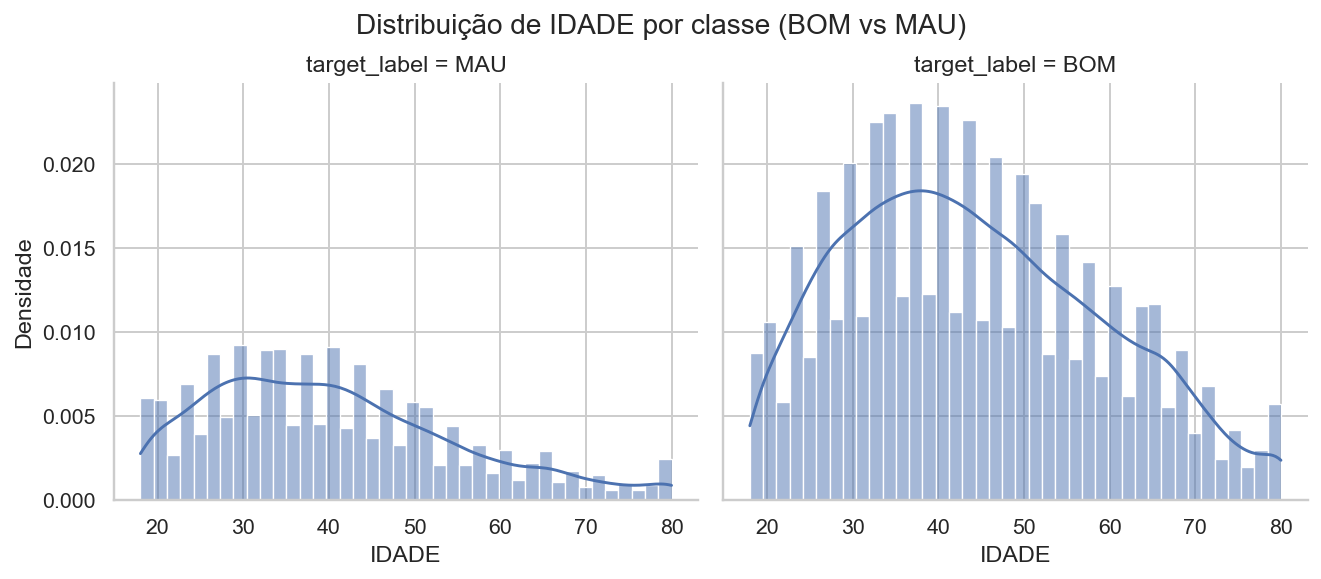

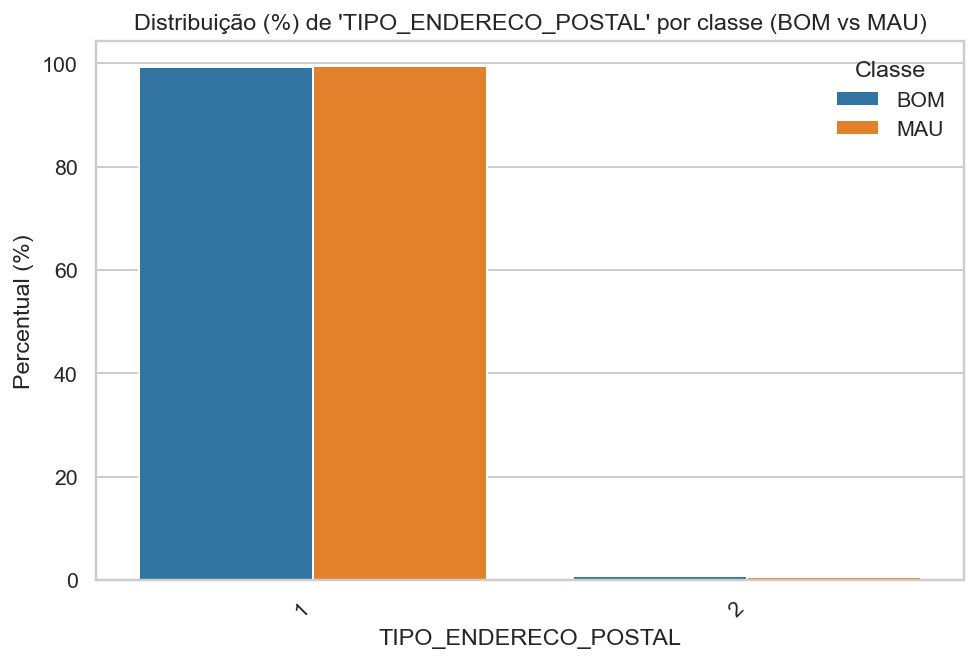

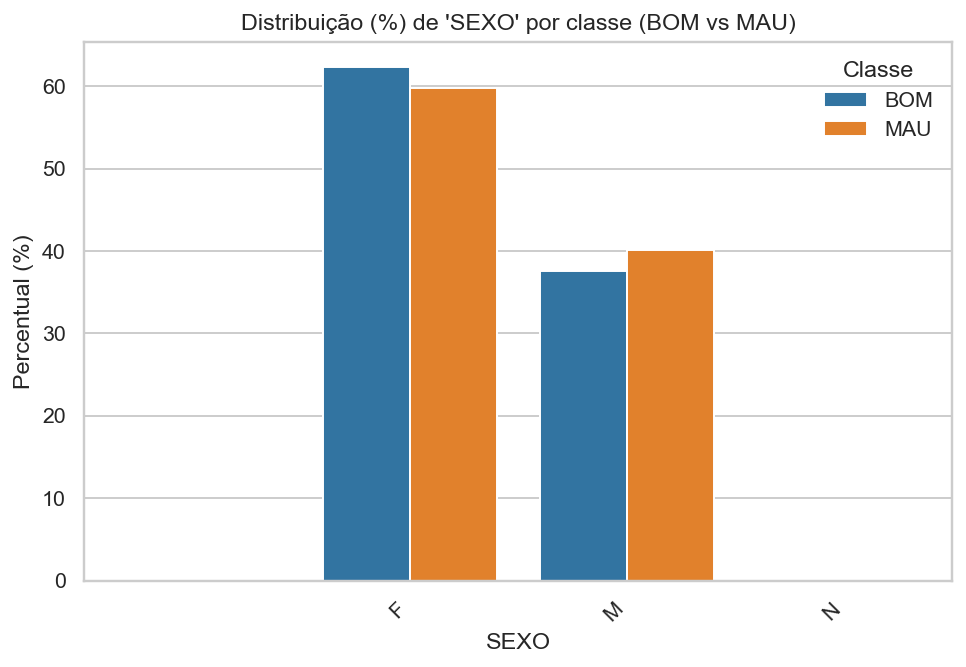

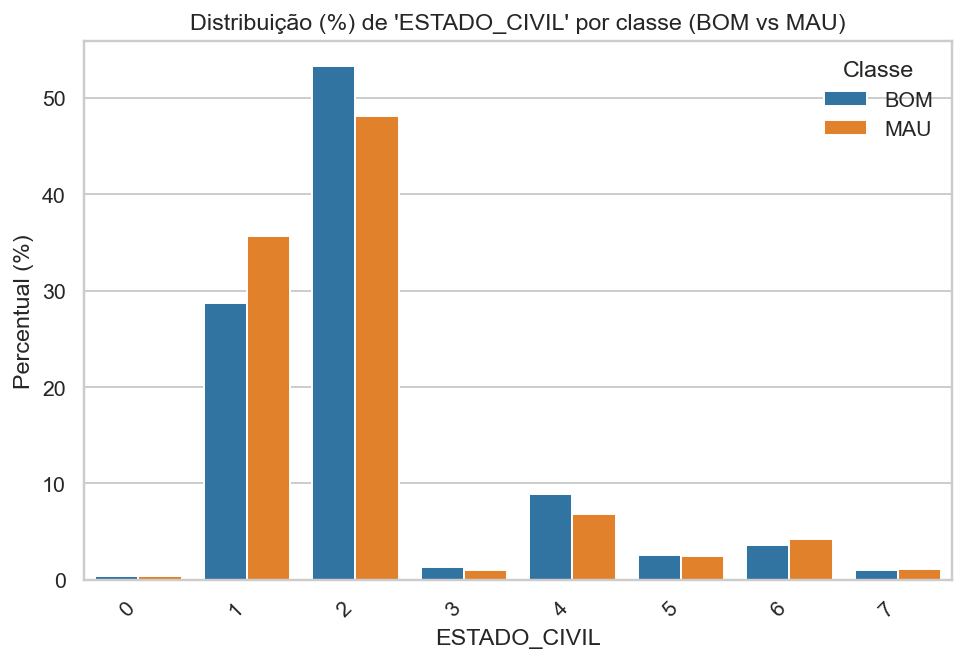

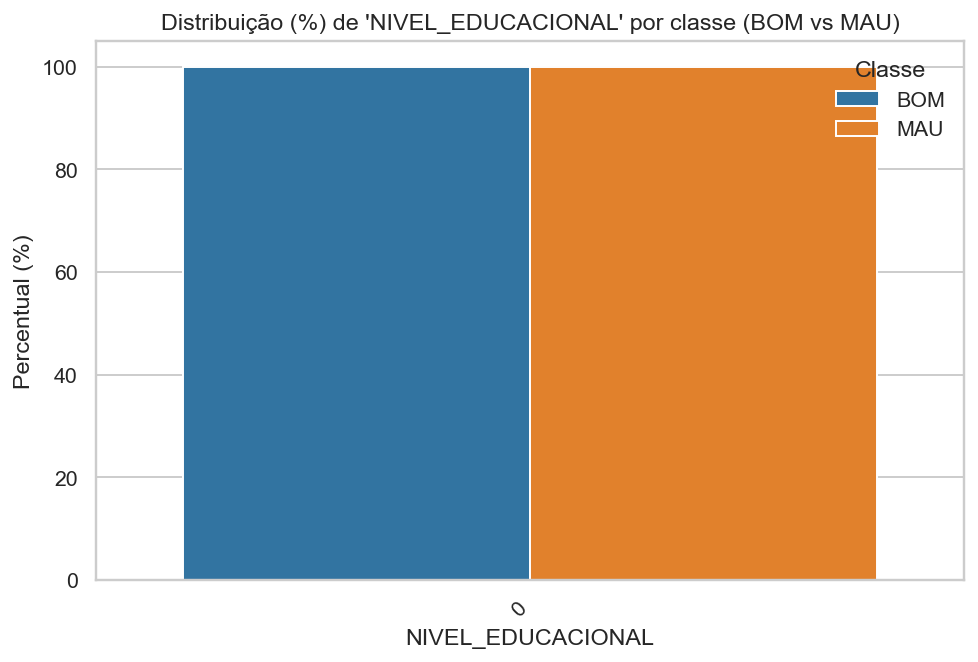

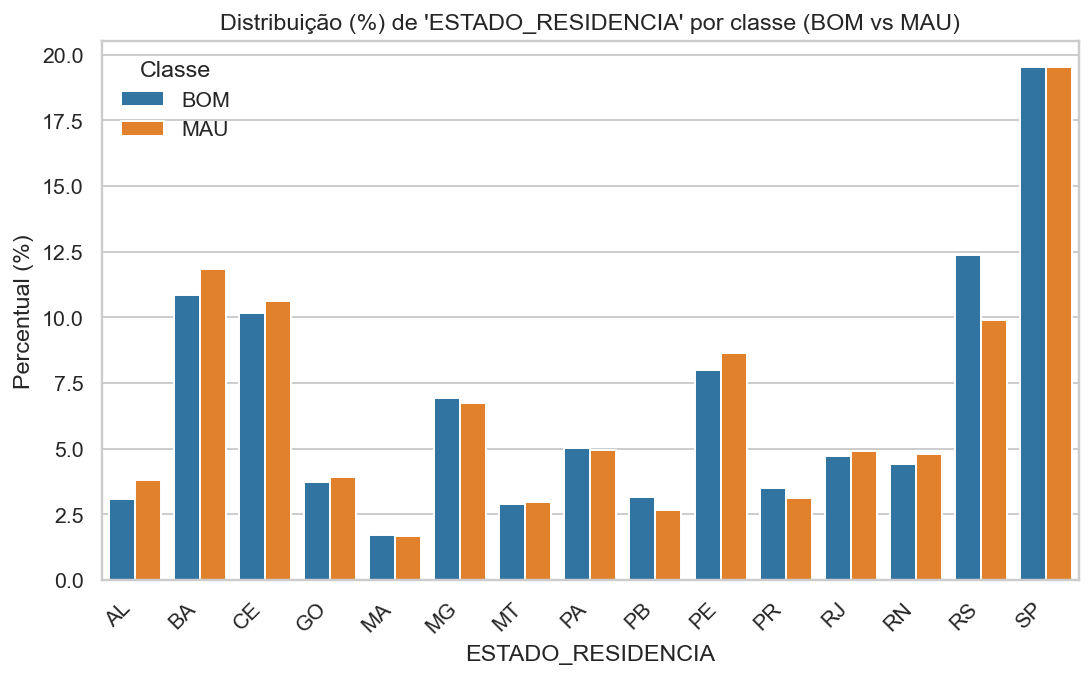

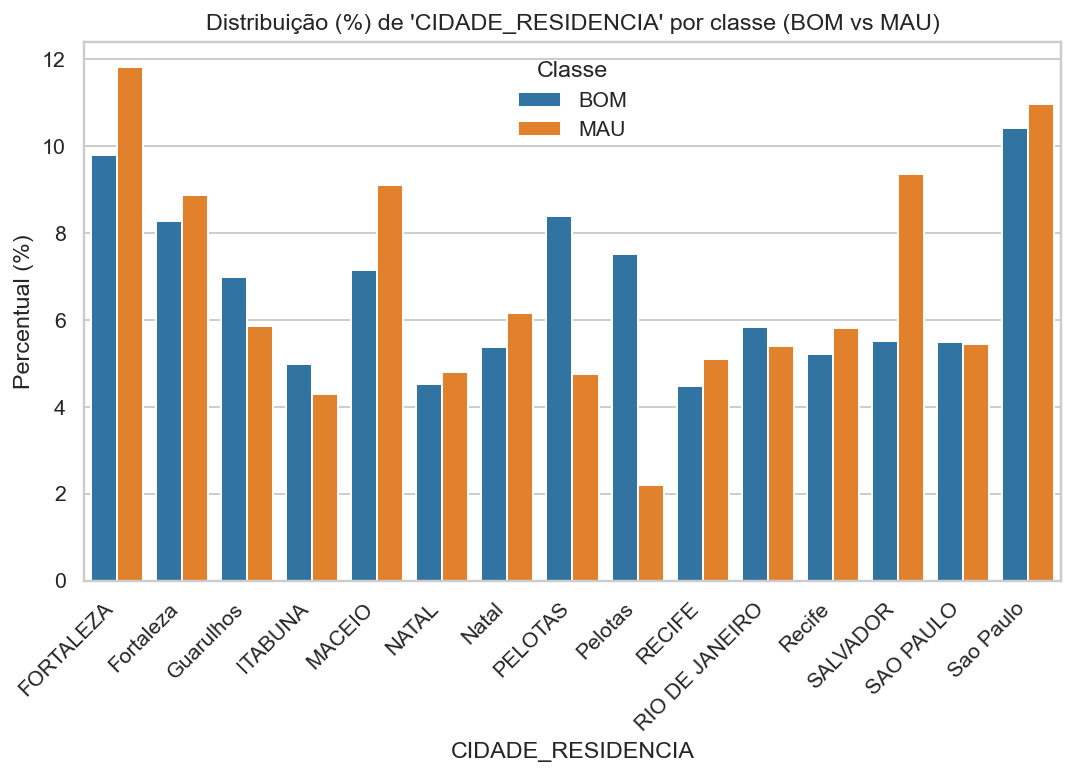

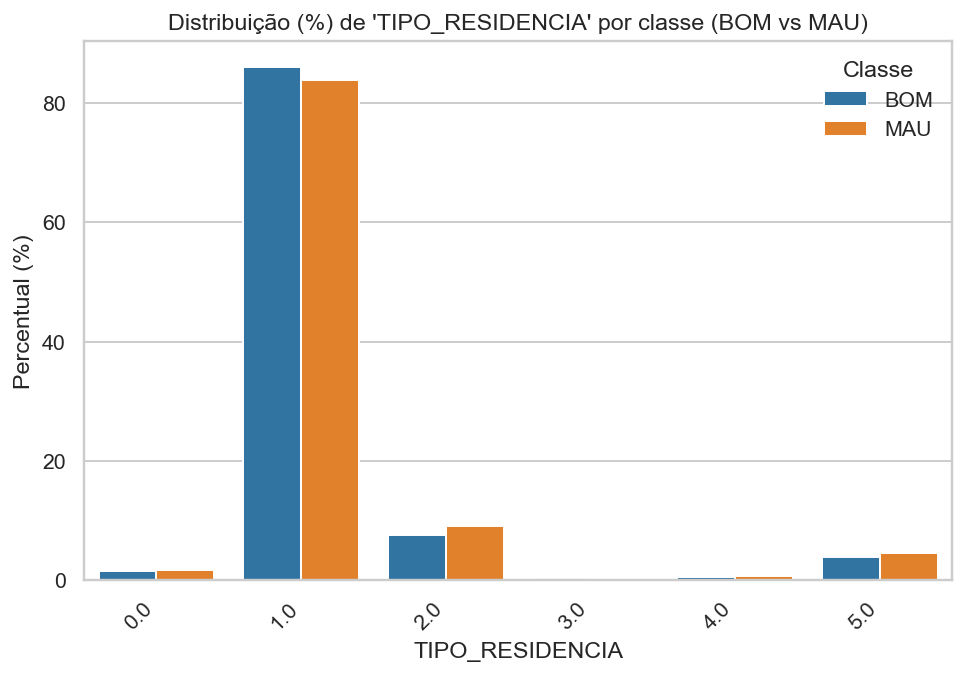

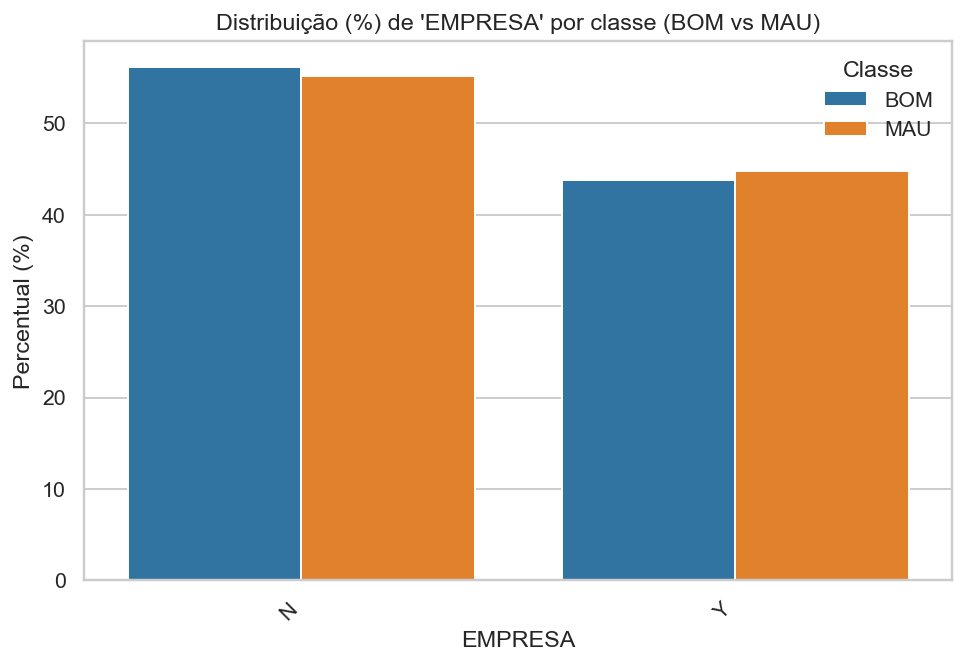

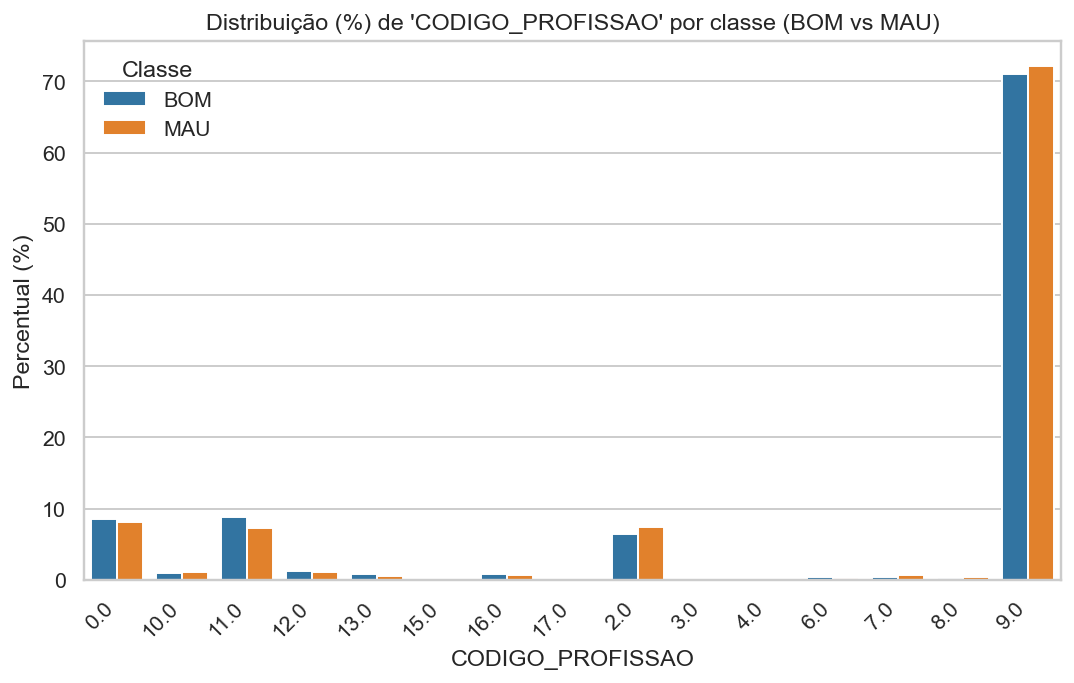

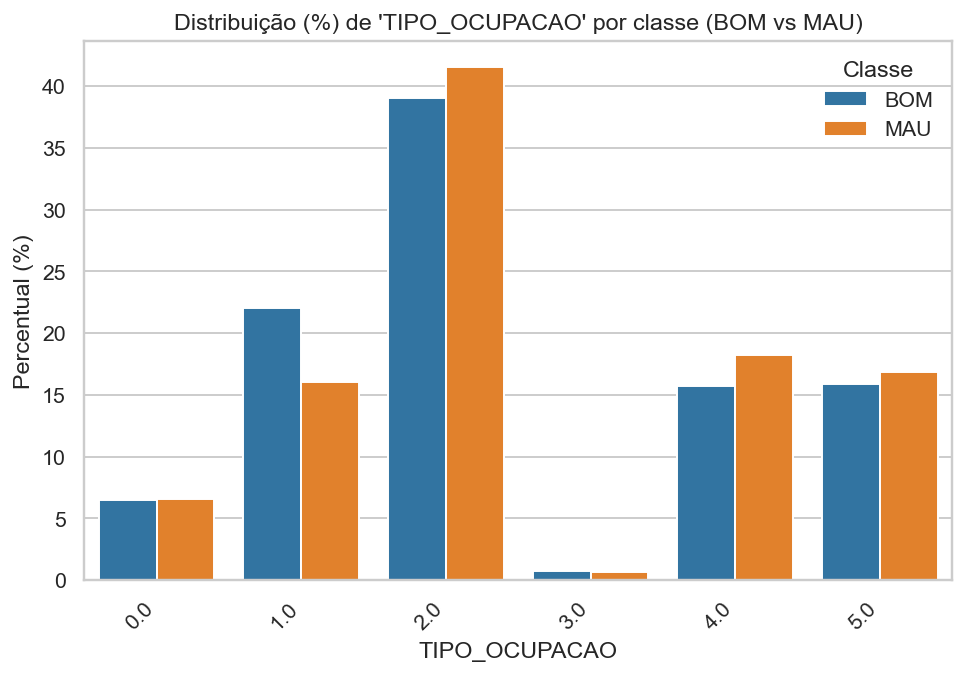

In [18]:
# %% Configuração e imports
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 140  # melhora nitidez


SELECTED_VARS = [
    'DIA_PAGAMENTO','QUANT_CARTOES_ADICIONAIS','TIPO_ENDERECO_POSTAL','SEXO','ESTADO_CIVIL',
    'QUANT_DEPENDENTES','NIVEL_EDUCACIONAL','ESTADO_RESIDENCIA','CIDADE_RESIDENCIA','TIPO_RESIDENCIA',
    'MESES_RESIDENCIA','RENDA_PESSOAL_MENSAL','OUTRAS_RENDAS','QUANT_CONTAS_BANCARIAS',
    'QUANT_CONTAS_BANCARIAS_ESPECIAIS','VALOR_PATRIMONIO_PESSOAL','QUANT_CARROS','EMPRESA',
    'MESES_NO_TRABALHO','CODIGO_PROFISSAO','TIPO_OCUPACAO','IDADE','ROTULO_ALVO_MAU_1'
]

# Interseção com colunas existentes no df (para evitar erro se algo faltar)
cols_in_df = [c for c in SELECTED_VARS if c in df.columns]
missing = sorted(set(SELECTED_VARS) - set(cols_in_df))
if missing:
    print("[WARN] As seguintes colunas não foram encontradas e serão ignoradas:", missing)

df_sel = df[cols_in_df].copy()

# =============================================================================
# 2) Preparação do alvo (BOM vs MAU)
# =============================================================================
TARGET_COL = 'ROTULO_ALVO_MAU_1'
if TARGET_COL not in df_sel.columns:
    raise KeyError(f"A coluna '{TARGET_COL}' não foi encontrada em df_sel.")

df_sel['target_num']   = pd.to_numeric(df_sel[TARGET_COL], errors='coerce')
df_sel['target_label'] = df_sel['target_num'].map({0: 'BOM', 1: 'MAU'})

n_invalid = df_sel['target_num'].isna().sum() + df_sel.loc[~df_sel['target_num'].isin([0,1]), 'target_num'].count()
if n_invalid > 0:
    print(f"[WARN] {n_invalid} registros com alvo inválido/ausente (fora de {len(df_sel)}).")

# =============================================================================
# 3) Tipagem: numéricas vs categóricas
# =============================================================================
# Numéricas
NUM_COLS_WHITELIST = [
    'DIA_PAGAMENTO','QUANT_CARTOES_ADICIONAIS','QUANT_DEPENDENTES',
    'MESES_RESIDENCIA','RENDA_PESSOAL_MENSAL','OUTRAS_RENDAS',
    'QUANT_CONTAS_BANCARIAS','QUANT_CONTAS_BANCARIAS_ESPECIAIS',
    'VALOR_PATRIMONIO_PESSOAL','QUANT_CARROS','MESES_NO_TRABALHO','IDADE'
]

# Categóricas
CAT_COLS_WHITELIST = [
    'TIPO_ENDERECO_POSTAL','SEXO','ESTADO_CIVIL','NIVEL_EDUCACIONAL',
    'ESTADO_RESIDENCIA','CIDADE_RESIDENCIA','TIPO_RESIDENCIA','EMPRESA',
    'CODIGO_PROFISSAO','TIPO_OCUPACAO'
]

# Mantém apenas as que existem em df_sel
num_cols = [c for c in NUM_COLS_WHITELIST if c in df_sel.columns]
cat_cols = [c for c in CAT_COLS_WHITELIST if c in df_sel.columns]

print(f"[INFO] num_cols ({len(num_cols)}): {num_cols}")
print(f"[INFO] cat_cols ({len(cat_cols)}): {cat_cols}")

# =============================================================================
# 4) Normalização decimal BR e conversão numérica
# =============================================================================
def normalize_decimal_br(series: pd.Series) -> pd.Series:
    # remove milhar '.' e troca vírgula ',' por ponto '.'
    s = series.astype(str).str.strip()
    s = s.str.replace('.', '', regex=False)   # remove milhar
    s = s.str.replace(',', '.', regex=False)  # decimal
    return pd.to_numeric(s, errors='coerce')

decimal_br_cols = {'RENDA_PESSOAL_MENSAL','OUTRAS_RENDAS','VALOR_PATRIMONIO_PESSOAL'}
for c in decimal_br_cols:
    if c in df_sel.columns:
        df_sel[c] = normalize_decimal_br(df_sel[c])

# Converte demais numéricas
for c in num_cols:
    if c not in decimal_br_cols:
        df_sel[c] = pd.to_numeric(df_sel[c], errors='coerce')

# =============================================================================
# 5) Funções de plot
# =============================================================================
def clip_percentiles(series: pd.Series, p_low=1, p_high=99) -> pd.Series:
    vals = series.dropna()
    if vals.empty:
        return series
    try:
        low, high = np.percentile(vals, [p_low, p_high])
    except Exception as err:
        print(f"[WARN] Percentile falhou: {err}. Usando min/max.")
        low, high = float(vals.min()), float(vals.max())
    if not np.isfinite(low) or not np.isfinite(high) or low == high:
        low, high = float(vals.min()), float(vals.max())
    return series.clip(lower=low, upper=high)

def kde_is_safe(tmp: pd.DataFrame, value_col: str, min_points=30) -> bool:
    """KDE seguro se, em cada classe (BOM/MAU), n>=min_points, var>~0 e >=2 valores distintos."""
    for cls in ['BOM', 'MAU']:
        v = tmp.loc[tmp['target_label'] == cls, value_col]
        if v.size < min_points or np.nanvar(v) <= 1e-12 or pd.Series(v).nunique() < 2:
            return False
    return True

def displot_by_class(df_plot, col, use_log=False, p_low=1, p_high=99, save=False, outdir="plots"):
    """Displot para variável numérica, facet por classe (BOM vs MAU), com KDE opcional."""
    if col not in df_plot.columns:
        print(f"[ERRO] Coluna '{col}' não existe em df_plot."); 
        return

    s = pd.to_numeric(df_plot[col], errors='coerce')
    mask = s.notna() & df_plot['target_num'].notna()
    if not mask.any():
        print(f"[Sem dados válidos] {col}")
        return

    s_clip = clip_percentiles(s[mask], p_low=p_low, p_high=p_high)

    # Log1p só se seguro
    if use_log and (s_clip.min() < -1):
        print(f"[WARN] {col}: valores < -1; log1p desativado.")
        use_log = False
    s_plot = np.log1p(s_clip) if use_log else s_clip
    xlab = f"{col} (log1p)" if use_log else col

    tmp = pd.DataFrame({
        col: s_plot.values,
        'target_label': df_plot.loc[mask, 'target_label'].values
    })

    bins = 40
    uniq = tmp[col].nunique()
    if uniq < 20:
        bins = max(int(uniq), 5)

    kde_flag = kde_is_safe(tmp, value_col=col, min_points=30)

    g = sns.displot(
        data=tmp, x=col, col='target_label',
        kde=kde_flag, stat='density', bins=bins,
        height=4.0, aspect=1.2
    )
    g.set_axis_labels(xlab, "Densidade")
    g.fig.suptitle(f"Distribuição de {col} por classe (BOM vs MAU)", y=1.03)
    if not kde_flag:
        print(f"[INFO] KDE desativado em '{col}' (amostra pequena/variância baixa).")

    if save:
        os.makedirs(outdir, exist_ok=True)
        fname = os.path.join(outdir, f"dist_by_class_{col}.png")
        plt.savefig(fname, dpi=160, bbox_inches="tight")
        print(f"[OK] Salvo: {fname}")
    plt.show()

def barplot_categorical_by_class(df_plot, col, top_n=15, normalize=True, save=False, outdir="plots"):
    """
    Barplot para variável categórica comparando BOM vs MAU.
    - normalize=True: mostra % dentro de cada classe (BOM/MAU).
    - top_n: mostra apenas as categorias mais frequentes (melhora a leitura).
    """
    if col not in df_plot.columns:
        print(f"[ERRO] Coluna '{col}' não existe em df_plot."); 
        return

    tmp = df_plot[['target_label', col]].copy()
    tmp = tmp.dropna(subset=['target_label'])
    tmp[col] = tmp[col].astype('string').str.strip()

    # Top-n categorias por frequência total
    top_cats = tmp[col].value_counts().nlargest(top_n).index
    tmp = tmp[tmp[col].isin(top_cats)]

    if normalize:
        counts = (
            tmp.groupby(['target_label', col])
               .size().reset_index(name='n')
        )
        totals = counts.groupby('target_label')['n'].sum().rename('total')
        counts = counts.merge(totals, on='target_label', how='left')
        counts['pct'] = counts['n'] / counts['total'] * 100

        plt.figure(figsize=(max(8, min(16, 0.6*len(top_cats))), 5))
        ax = sns.barplot(
            data=counts, x=col, y='pct', hue='target_label',
            palette=['#1f77b4', '#ff7f0e']
        )
        ax.set_title(f"Distribuição (%) de '{col}' por classe (BOM vs MAU)")
        ax.set_ylabel("Percentual (%)"); ax.set_xlabel(col)
        plt.xticks(rotation=45, ha='right'); plt.legend(title="Classe")
    else:
        plt.figure(figsize=(max(8, min(16, 0.6*len(top_cats))), 5))
        ax = sns.countplot(
            data=tmp, x=col, hue='target_label',
            palette=['#1f77b4', '#ff7f0e']
        )
        ax.set_title(f"Contagem de '{col}' por classe (BOM vs MAU)")
        ax.set_ylabel("Contagem"); ax.set_xlabel(col)
        plt.xticks(rotation=45, ha='right'); plt.legend(title="Classe")

    if save:
        os.makedirs(outdir, exist_ok=True)
        fname = os.path.join(outdir, f"cat_by_class_{col}.png")
        plt.savefig(fname, dpi=160, bbox_inches="tight")
        print(f"[OK] Salvo: {fname}")
    plt.show()

# =============================================================================
# 6) Execução: NUMÉRICAS (displot) + CATEGÓRICAS (barplot)
# =============================================================================
# Log apenas nas colunas muito assimétricas
LOG_COLS = {'RENDA_PESSOAL_MENSAL','OUTRAS_RENDAS','VALOR_PATRIMONIO_PESSOAL'}

# --- NUMÉRICAS ---
for col in num_cols:
    displot_by_class(
        df_sel, col,
        use_log=(col in LOG_COLS),
        p_low=1, p_high=99,
        save=False,            # mude para True para salvar PNG
        outdir="plots"
    )

# --- CATEGÓRICAS ---
for col in cat_cols:
    barplot_categorical_by_class(
        df_sel, col,
        top_n=15,             # ajuste conforme necessidade
        normalize=True,       # percentuais por classe
        save=False,           # mude para True para salvar PNG
        outdir="plots"
    )

Perfil Maus pagadores: Deixam para pagar contas no final do mês, possuem menos meses de residência, renda pessoal predominante até R$6.5K, possuem mais contas especiais do que clientes comuns e são mais jovens. 

Comparação numéricas vs alvo (Box/Violin + tamanho de efeito)

Balanceamento do alvo:
target_num
0    36959
1    13041
Name: count, dtype: int64
Numéricas presentes: ['DIA_PAGAMENTO', 'QUANT_DEPENDENTES', 'MESES_RESIDENCIA', 'RENDA_PESSOAL_MENSAL', 'OUTRAS_RENDAS', 'QUANT_CONTAS_BANCARIAS', 'QUANT_CONTAS_BANCARIAS_ESPECIAIS', 'VALOR_PATRIMONIO_PESSOAL', 'QUANT_CARROS', 'MESES_NO_TRABALHO', 'IDADE']


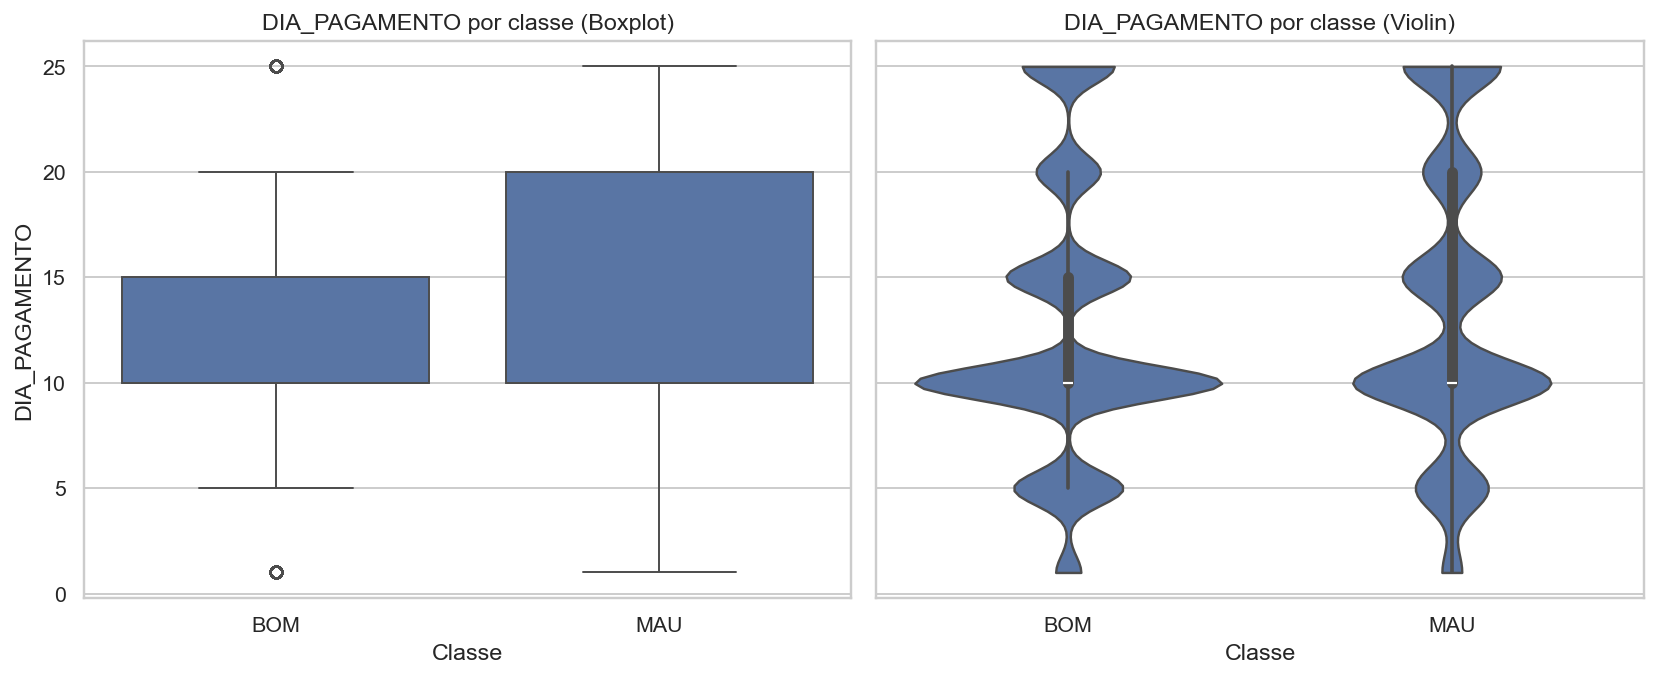

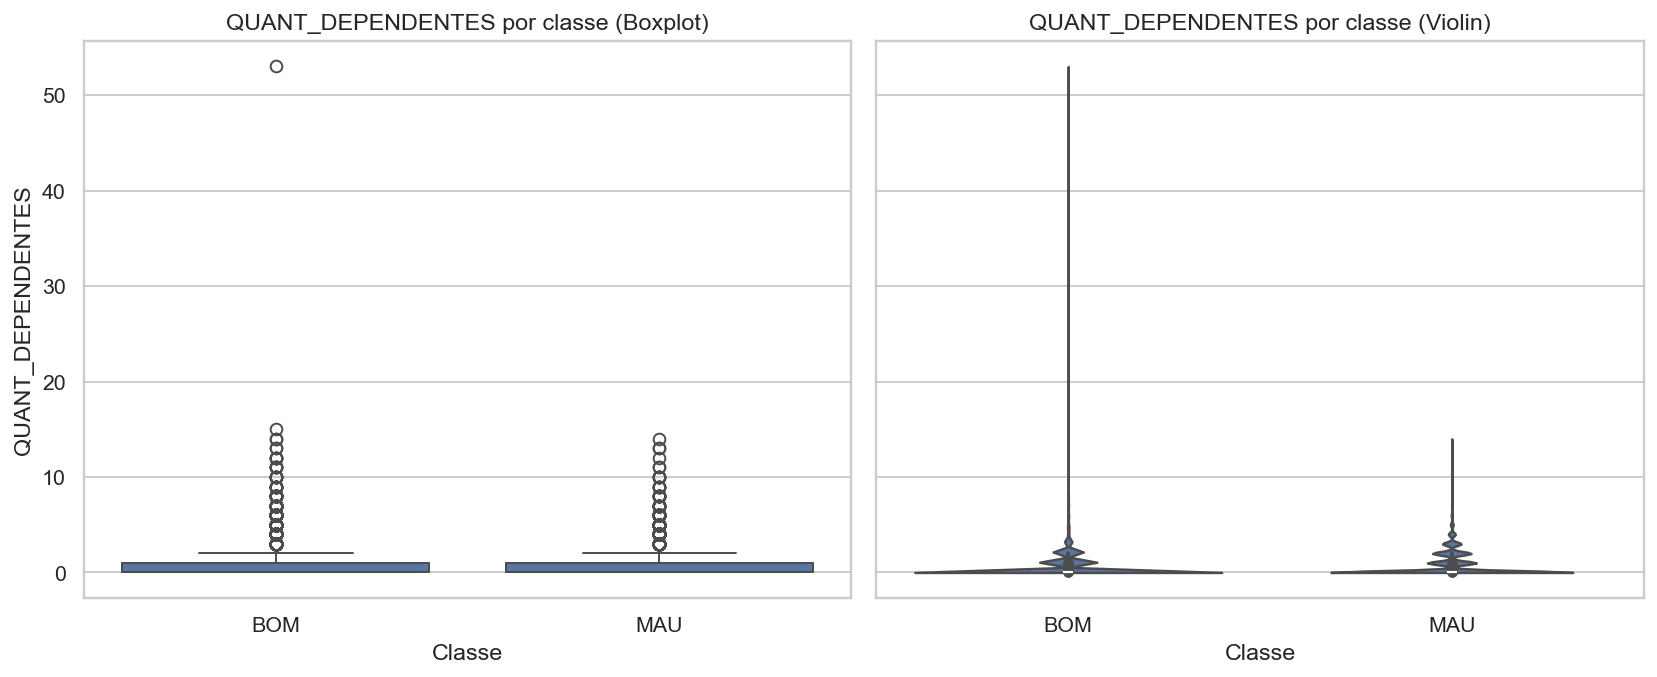

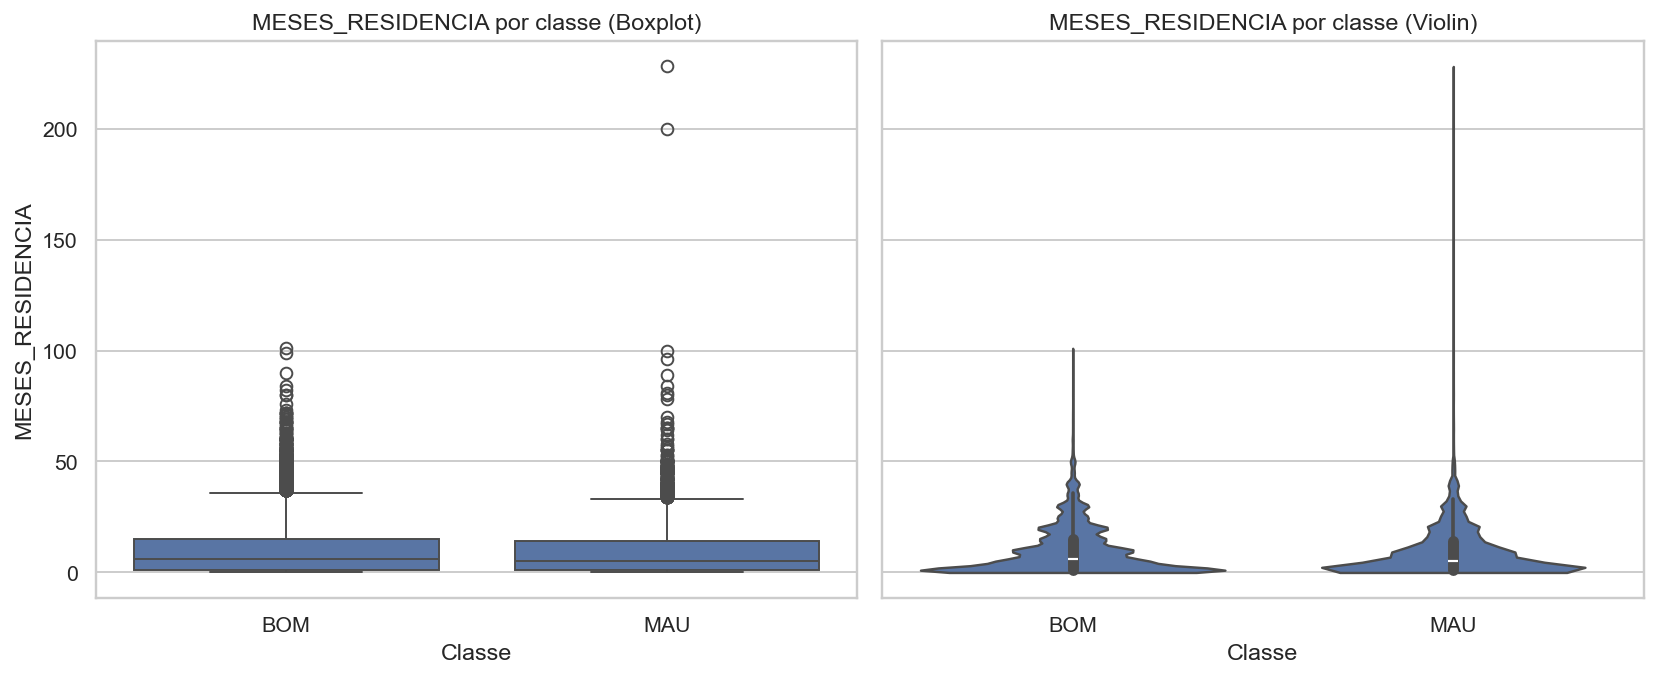

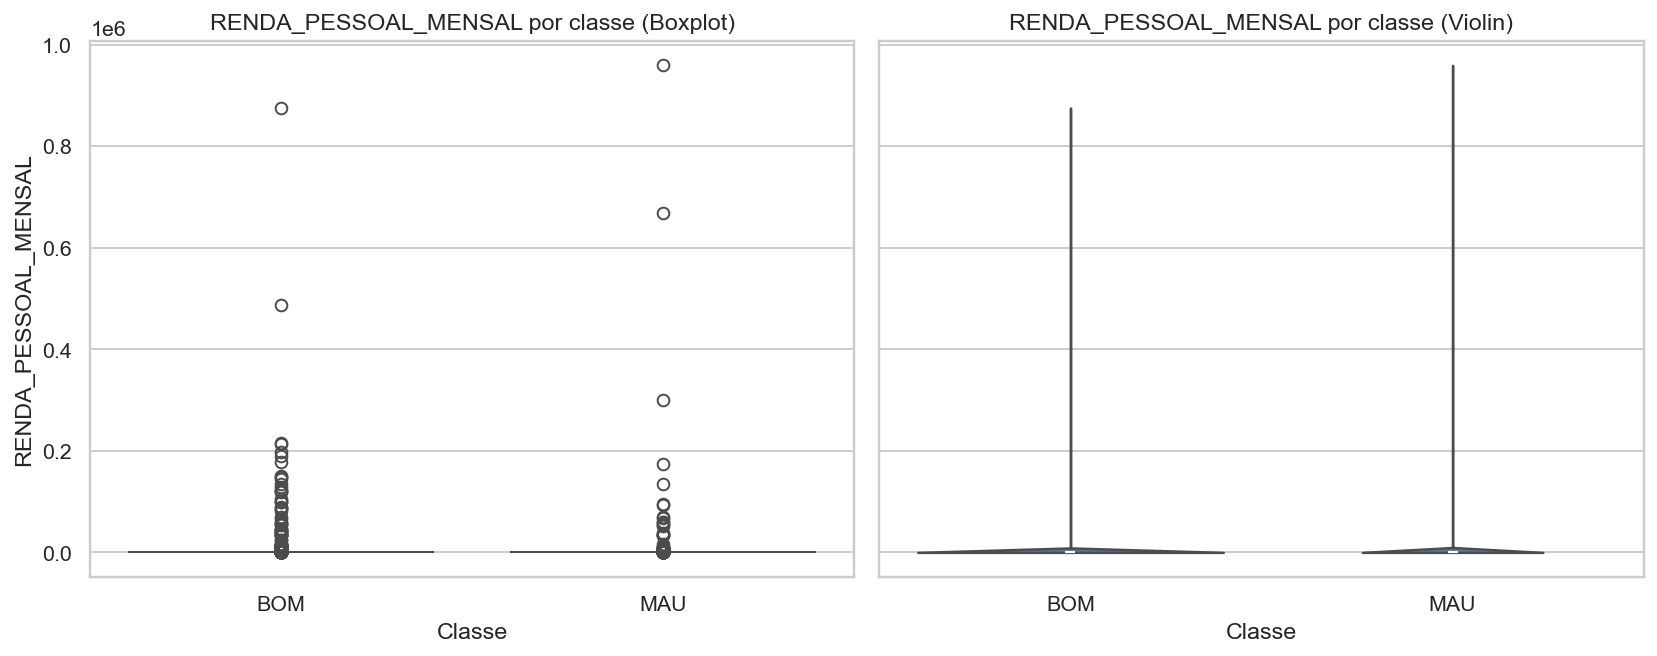

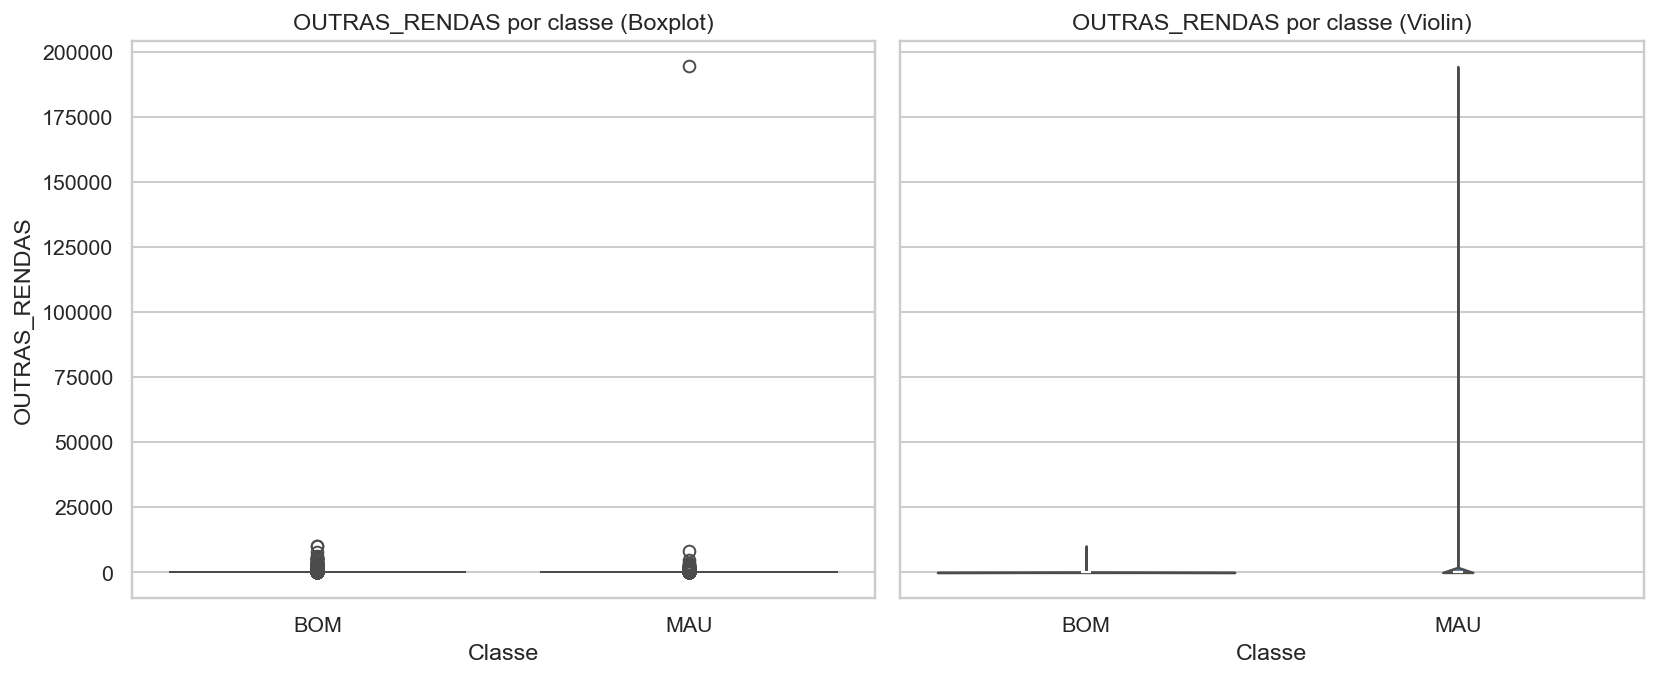

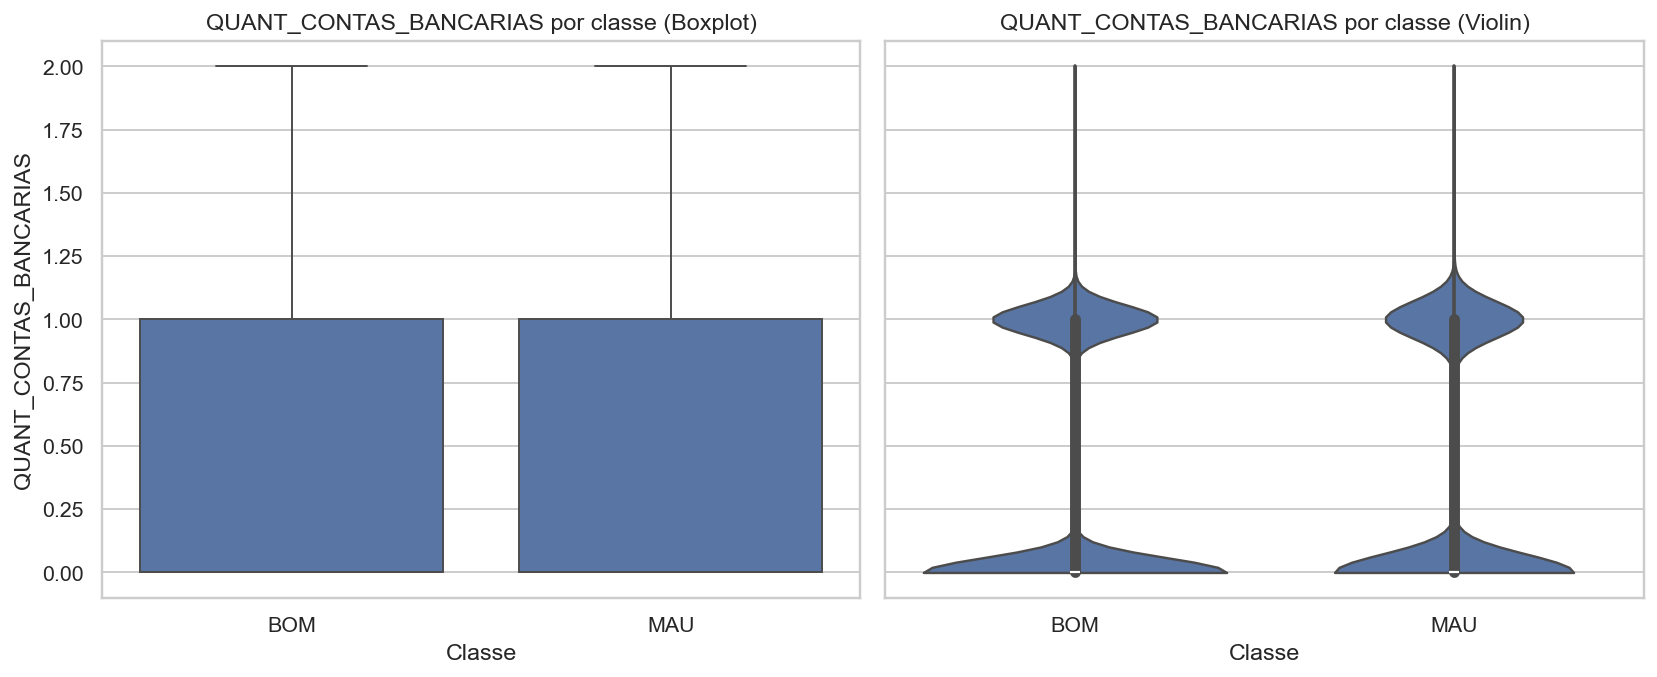

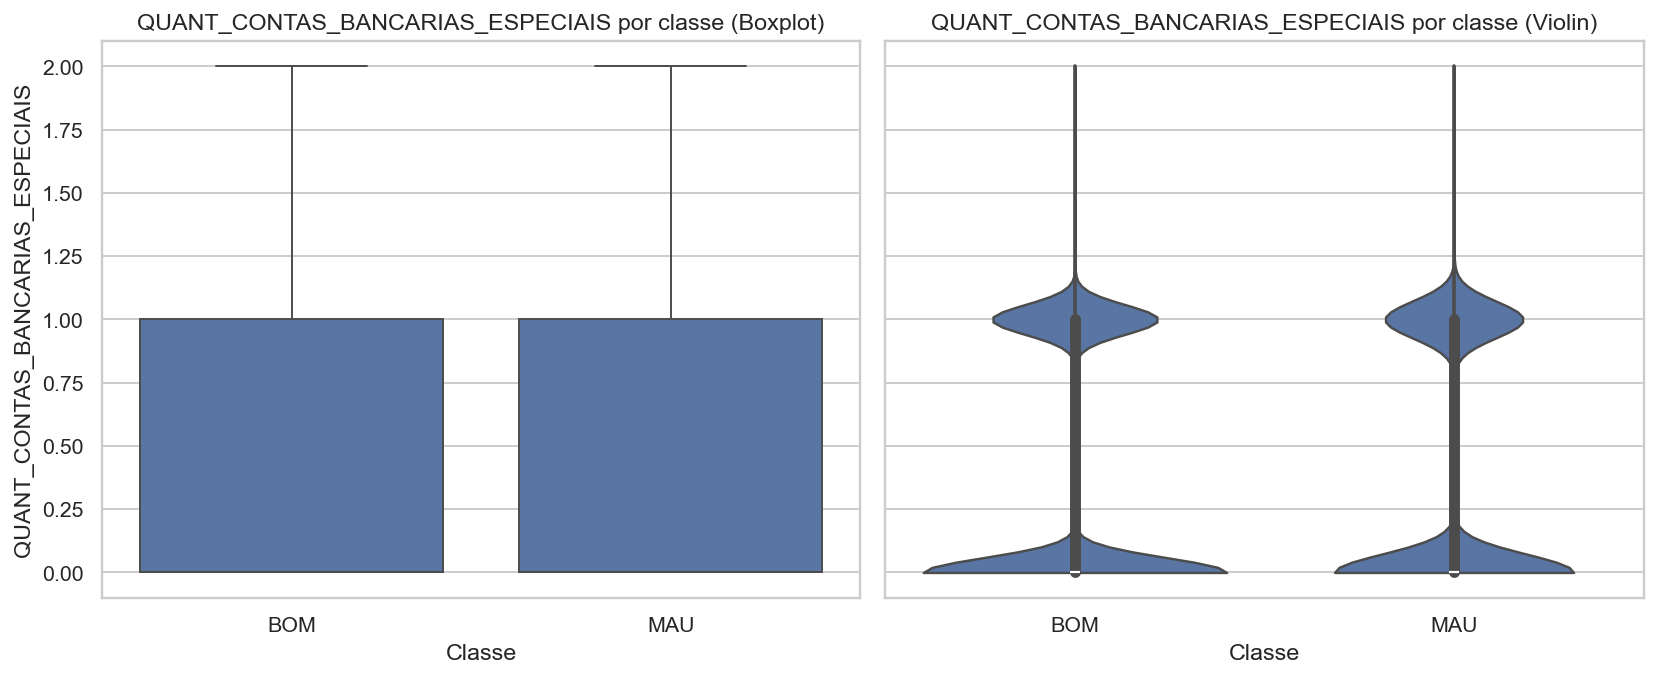

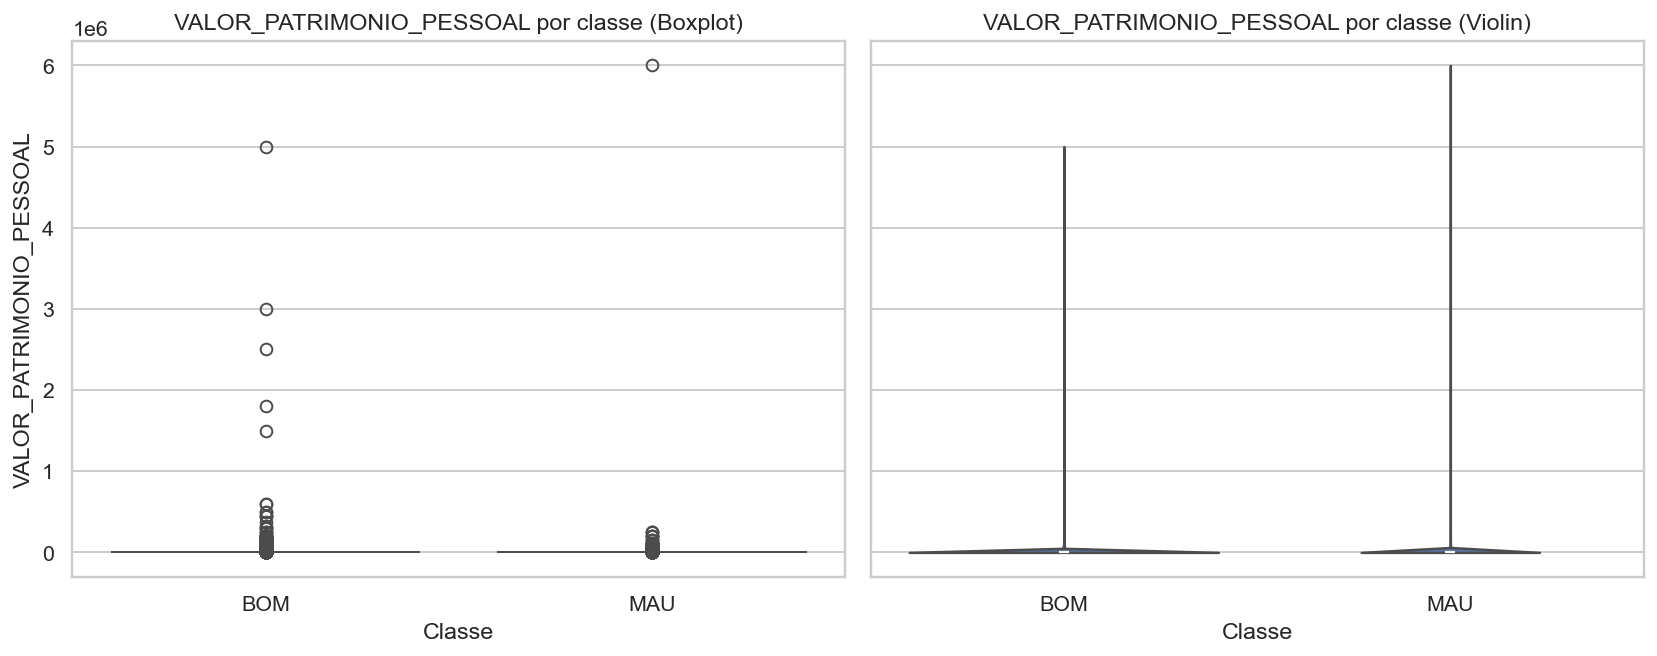

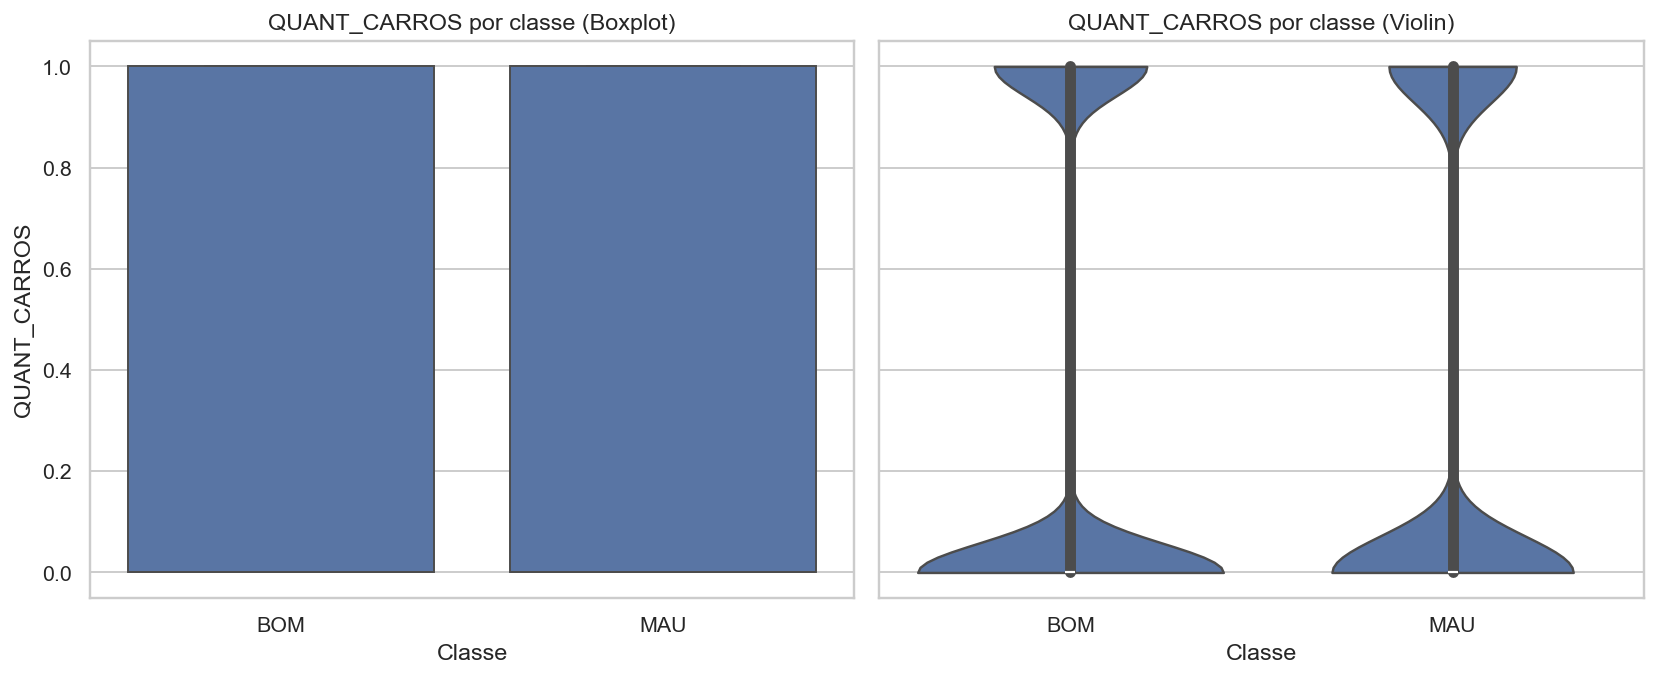

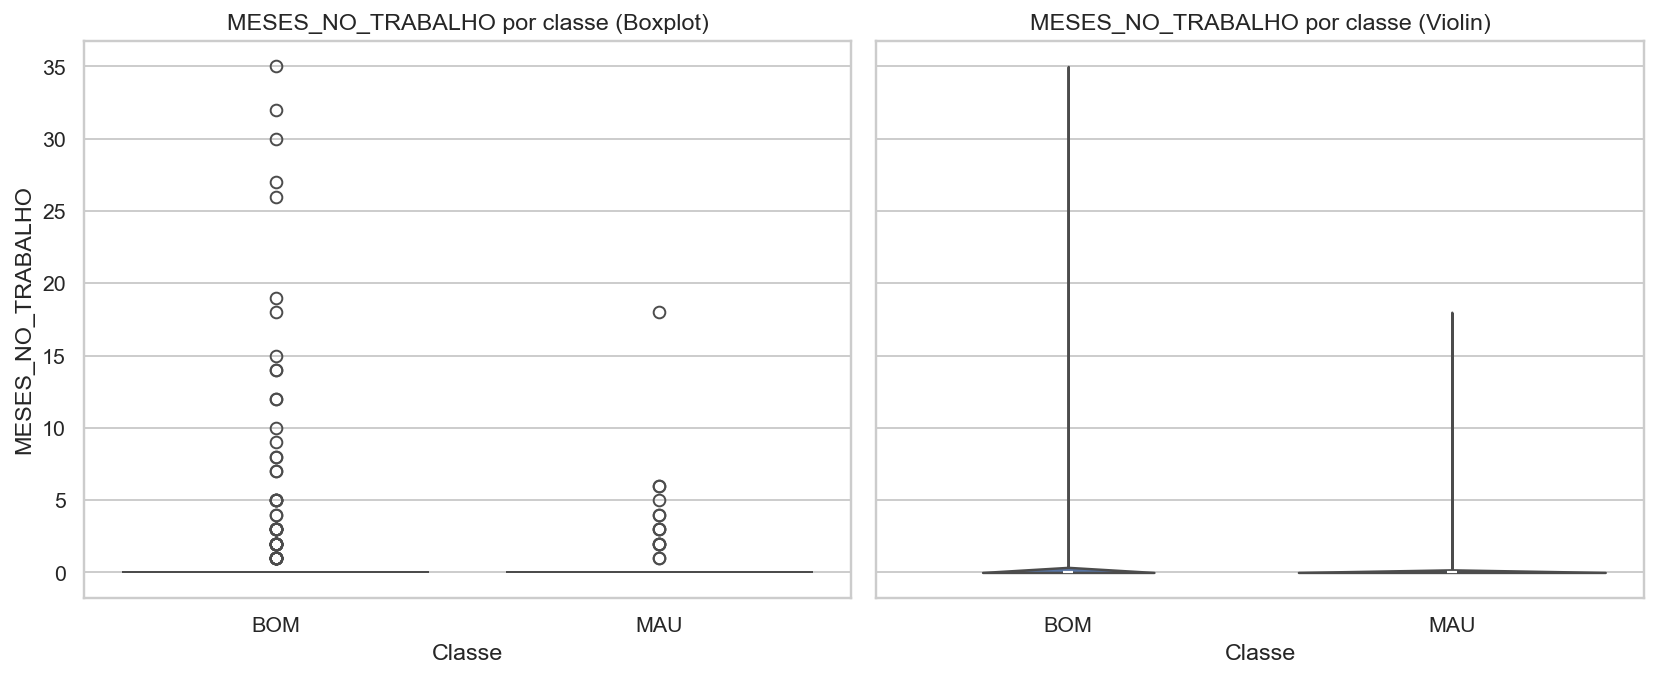

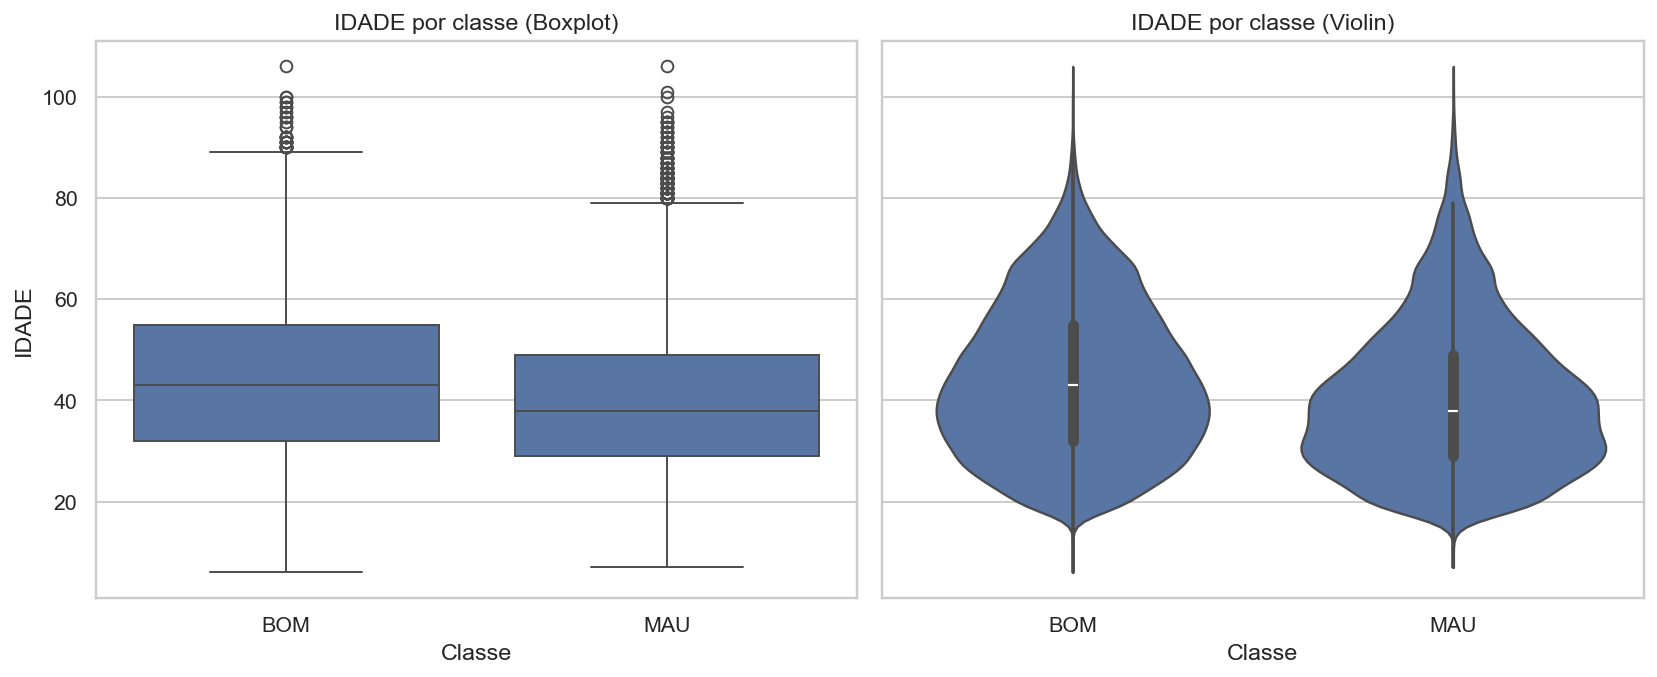

Resumo (ordenado por |Cohen's d|):


,variavel,media_BOM,media_MAU,cohens_d,n_BOM,n_MAU,abs_d
10,IDADE,44.209097,40.526187,-0.247147,36959,13041,0.247147
0,DIA_PAGAMENTO,12.592657,13.655701,0.161264,36959,13041,0.161264
2,MESES_RESIDENCIA,9.913543,9.201620,-0.066757,34121,12102,0.066757
1,QUANT_DEPENDENTES,0.641900,0.674948,0.027688,36959,13041,0.027688
6,QUANT_CONTAS_BANCARIAS_ESPECIAIS,0.354420,0.367533,0.027324,36959,13041,0.027324
5,QUANT_CONTAS_BANCARIAS,0.354420,0.367533,0.027324,36959,13041,0.027324
8,QUANT_CARROS,0.332855,0.345449,0.026661,36959,13041,0.026661
9,MESES_NO_TRABALHO,0.010931,0.004754,-0.016109,36959,13041,0.016109
4,OUTRAS_RENDAS,33.082406,42.101475,0.010117,36959,13041,0.010117
7,VALOR_PATRIMONIO_PESSOAL,2420.152250,2045.258186,-0.008851,36959,13041,0.008851


In [19]:
# 1) Garantir alvo e rótulos BOM/MAU
assert 'ROTULO_ALVO_MAU_1' in df.columns, "Alvo 'ROTULO_ALVO_MAU_1' não está no df."
df['ROTULO_ALVO_MAU_1'] = pd.to_numeric(df['ROTULO_ALVO_MAU_1'], errors='coerce')

# Se houver NaN no alvo, filtre antes de criar target_num
if df['ROTULO_ALVO_MAU_1'].isna().any():
    df = df[df['ROTULO_ALVO_MAU_1'].notna()].copy()

df['target_num'] = df['ROTULO_ALVO_MAU_1'].astype('int')
df['target_label'] = df['target_num'].map({0:'BOM', 1:'MAU'}).astype('category')

print("Balanceamento do alvo:")
print(df['target_num'].value_counts(dropna=False))

# 2) Tratar colunas numéricas (inclui BRL quando necessário)
numeric_candidates = [
    'DIA_PAGAMENTO','QUANT_DEPENDENTES','MESES_RESIDENCIA',
    'RENDA_PESSOAL_MENSAL','OUTRAS_RENDAS','QUANT_CONTAS_BANCARIAS',
    'QUANT_CONTAS_BANCARIAS_ESPECIAIS','VALOR_PATRIMONIO_PESSOAL',
    'QUANT_CARROS','MESES_NO_TRABALHO','IDADE'
]

def to_float_brl(x):
    if pd.isna(x): return np.nan
    x = str(x).strip().replace('R$', '').replace('.', '').replace(',', '.')
    try: return float(x)
    except: return np.nan

for col in numeric_candidates:
    if col in df.columns:
        looks_brl = df[col].astype(str).str.contains(r'R\$|,\d{2}$', regex=True).any()
        df[col] = df[col].map(to_float_brl) if looks_brl else pd.to_numeric(df[col], errors='coerce')

num_cols = [c for c in numeric_candidates if c in df.columns]
print("Numéricas presentes:", num_cols)

# 3) Versão robusta da função (se ainda não tiver no seu notebook)
def numeric_vs_target(df, cols):
    results = []
    for c in cols:
        if c not in df.columns:
            print(f"[Ignorado] {c} não existe."); continue
        g = df[[c, 'target_num', 'target_label']].copy()
        g[c] = pd.to_numeric(g[c], errors='coerce')
        g = g.dropna(subset=[c, 'target_num'])
        if g.empty:
            print(f"[Sem dados válidos] {c}"); continue

        # Gráficos
        fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)
        sns.boxplot(data=g, x='target_label', y=c, ax=axes[0])
        axes[0].set_title(f"{c} por classe (Boxplot)")
        sns.violinplot(data=g, x='target_label', y=c, ax=axes[1], cut=0)
        axes[1].set_title(f"{c} por classe (Violin)")
        for ax in axes:
            ax.set_xlabel("Classe"); ax.set_ylabel(c)
        plt.tight_layout(); plt.show()

        # Estatísticas e Cohen's d
        grp0, grp1 = g[g['target_num']==0][c], g[g['target_num']==1][c]
        m0, m1 = grp0.mean(), grp1.mean()
        s0, s1 = grp0.std(ddof=1), grp1.std(ddof=1)
        n0, n1 = grp0.size, grp1.size
        if n0 > 1 and n1 > 1 and s0 > 0 and s1 > 0:
            pooled = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2) / (n0 + n1 - 2))
            d = (m1 - m0) / pooled if pooled > 0 else np.nan
        else:
            d = np.nan
        results.append({"variavel": c, "media_BOM": m0, "media_MAU": m1,
                        "cohens_d": d, "n_BOM": n0, "n_MAU": n1})
    res = (pd.DataFrame(results)
           .assign(abs_d=lambda x: x['cohens_d'].abs())
           .sort_values('abs_d', ascending=False))
    print("Resumo (ordenado por |Cohen's d|):")
    display(res)
    return res

# 4) Chamar a função (executa gráficos e retorna tabela)
res_num = numeric_vs_target(df, num_cols)


As maiores médias de desvio padrão entre bons e maus pagadores ocorrem em idade e dia de pagamento principalmente. De forma geral, maus pagadores têm perfil mais jovem, com poucos meses de residência, no trabalho e patrimônimo menor que a média de bom pagadores.  

Relação bivariada (numéricos vs alvo) com escalas ajustadas

Diferenças de mediana/forma entre classes sugerem poder discriminativo.

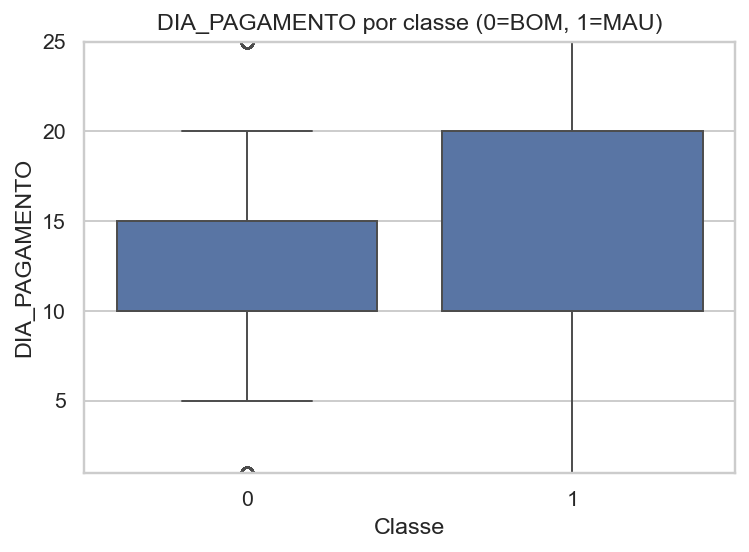

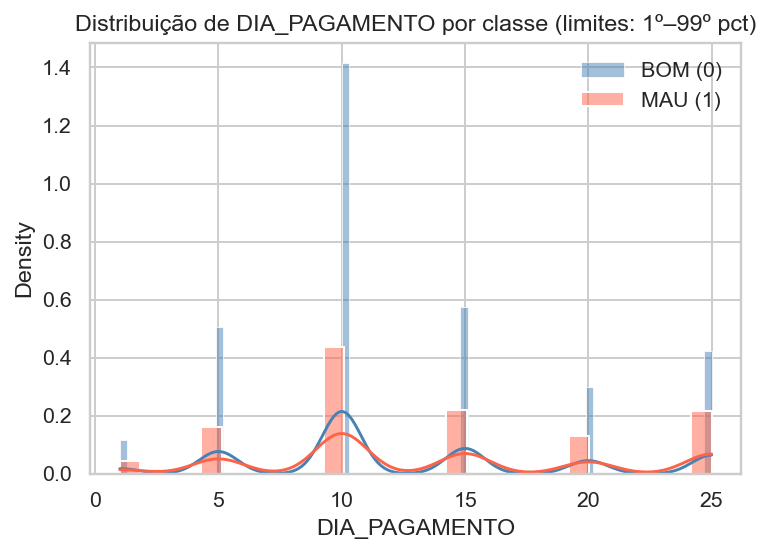

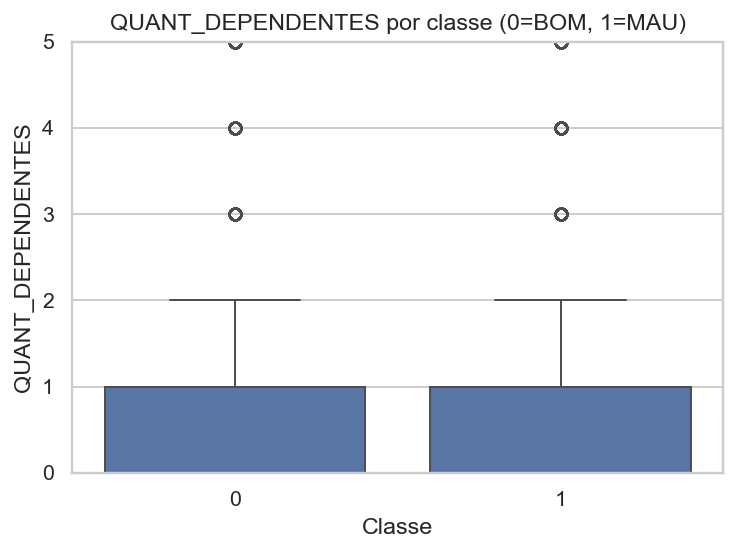

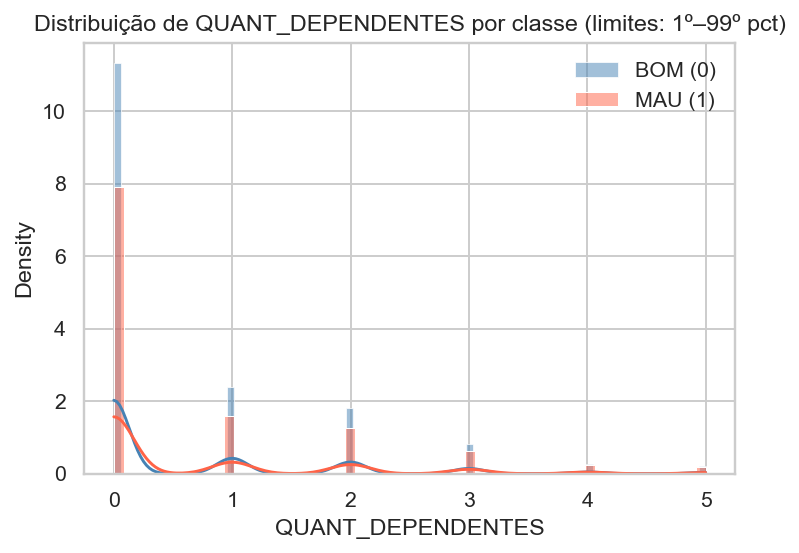

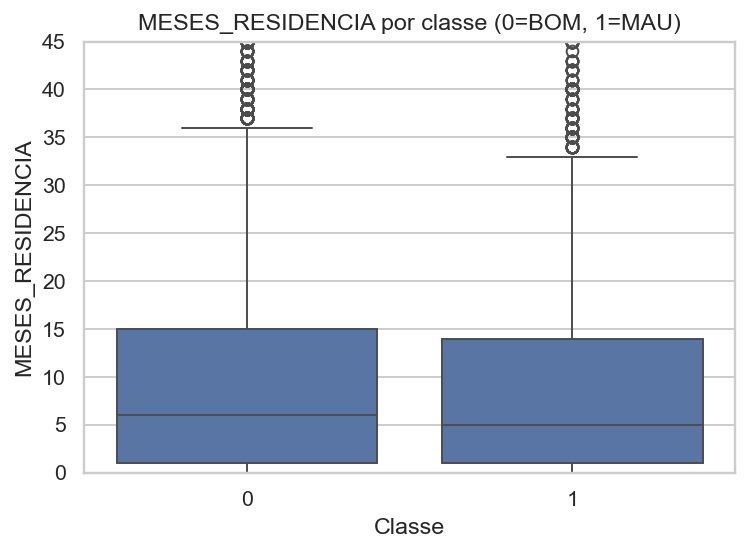

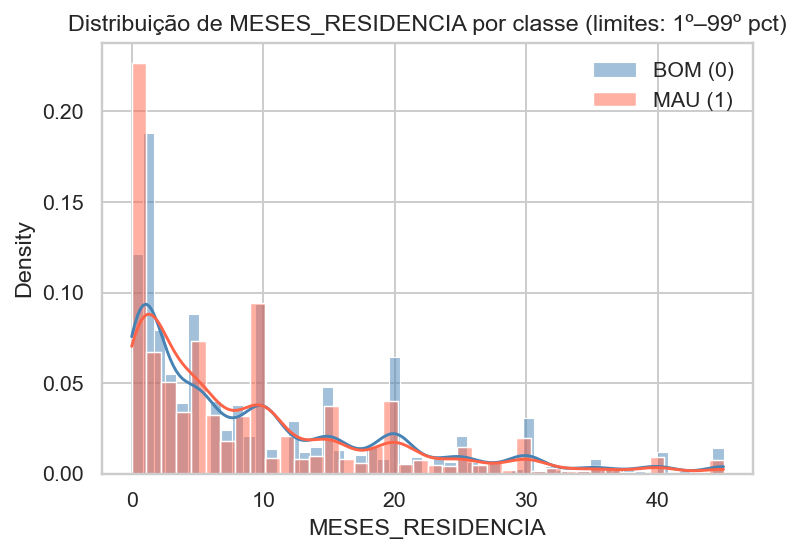

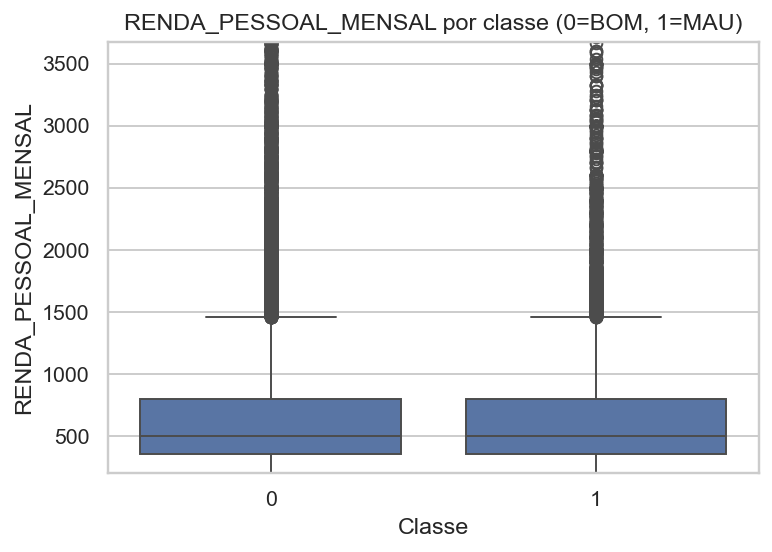

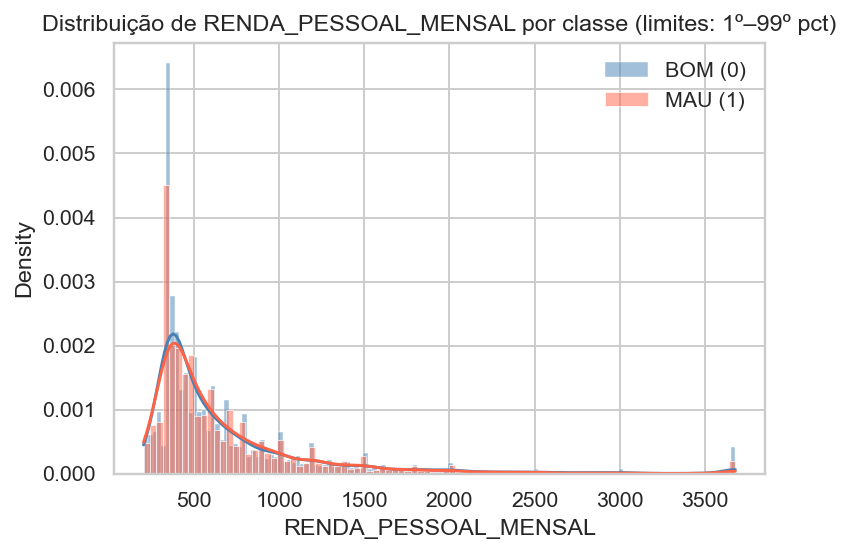

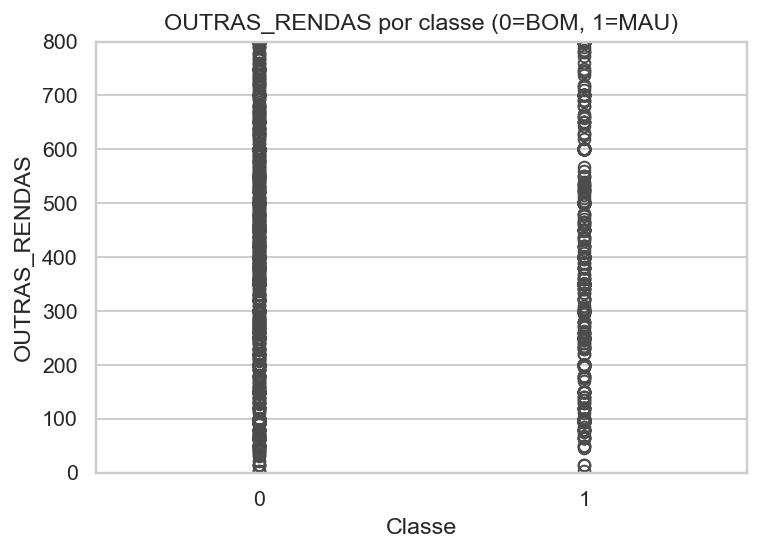

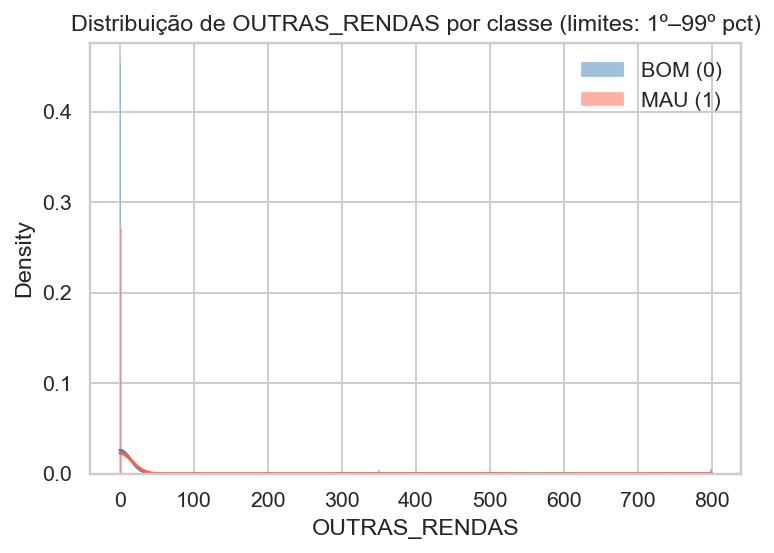

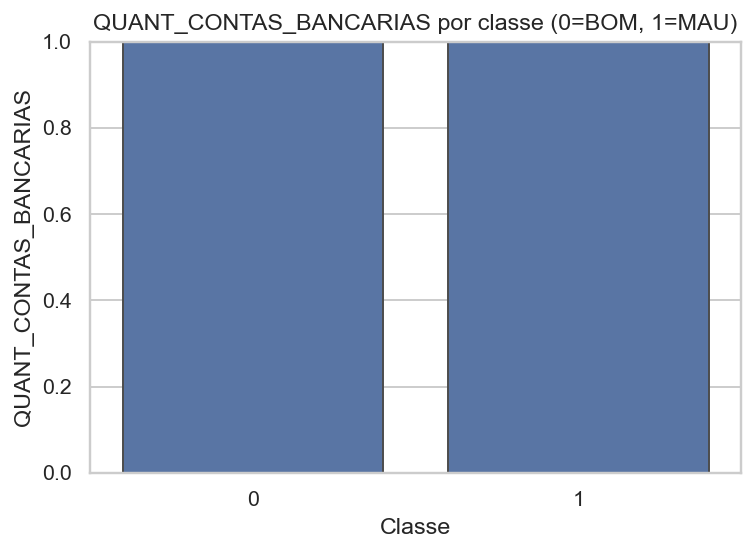

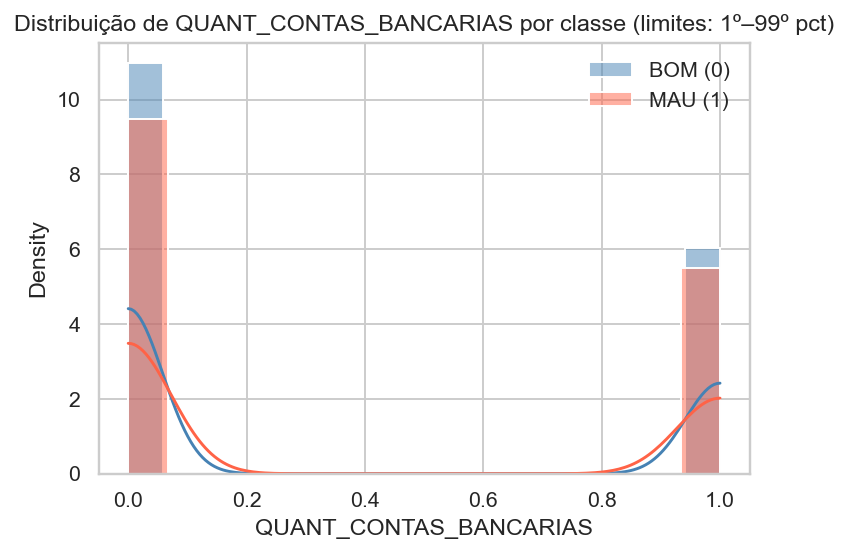

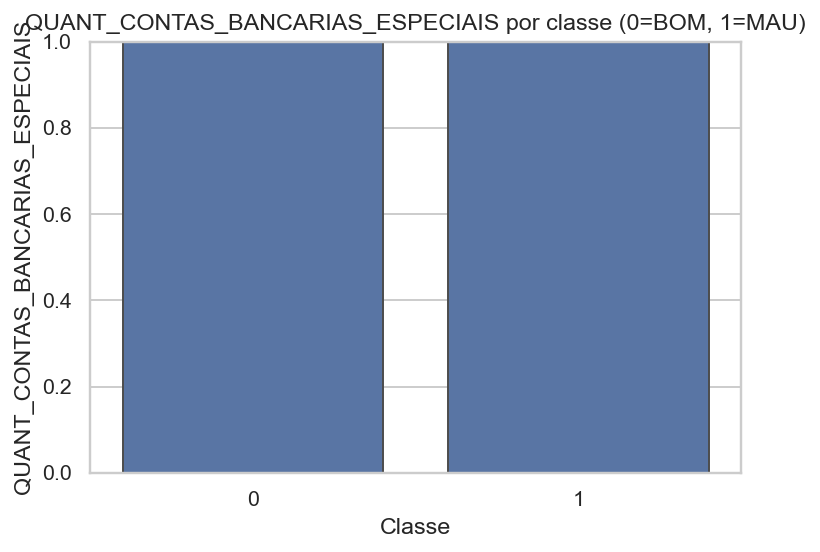

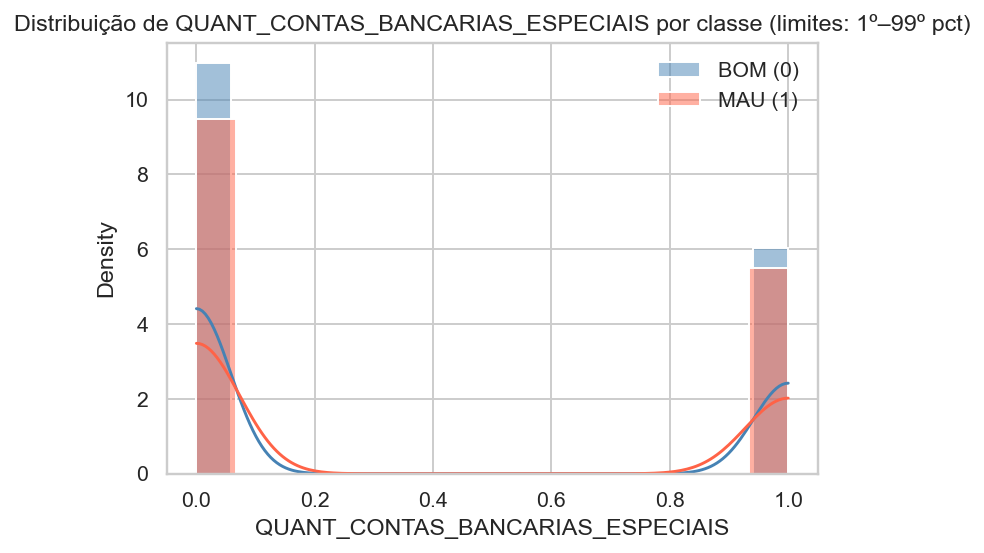

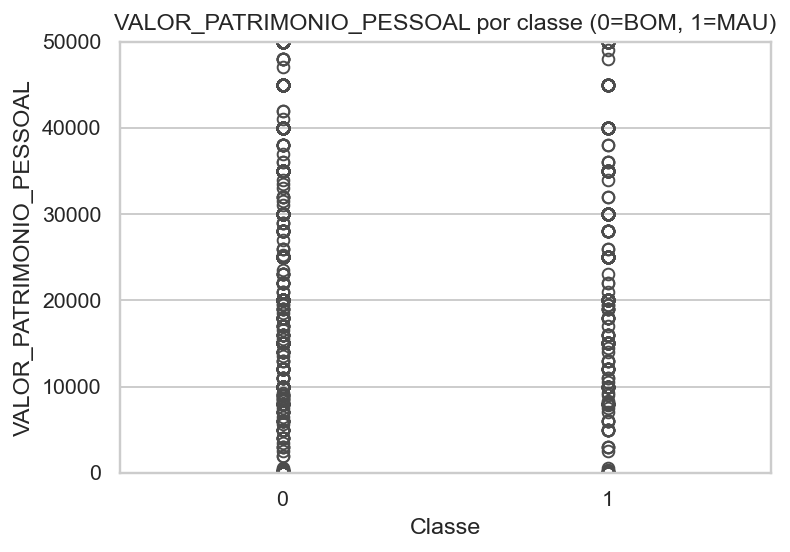

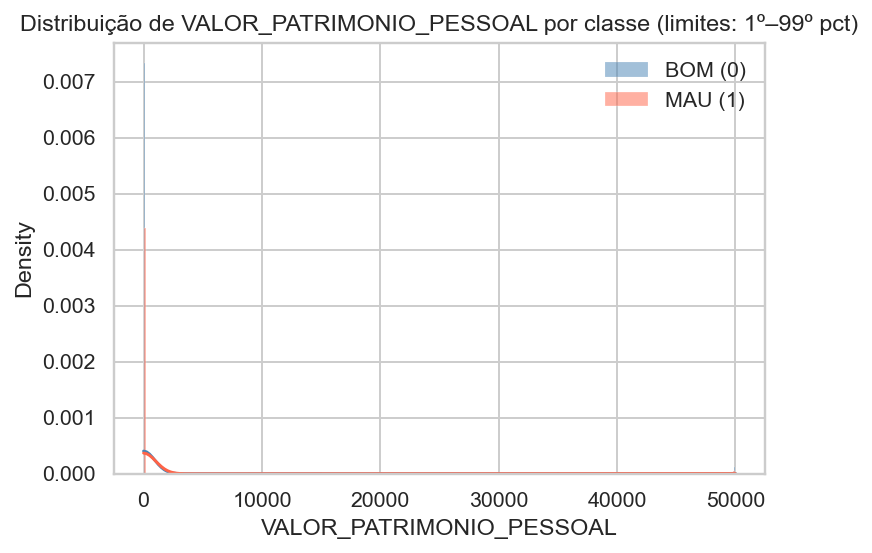

In [20]:
# %% Bivariado (numéricos vs alvo): boxplot e hist sobreposto por classe
y_int = df['target_num']
for col in num_cols[:8]:  # limitar para não gerar muitos gráficos
    # Boxplot por classe
    ax = sns.boxplot(x=y_int, y=df[col])
    ax.set_title(f'{col} por classe (0=BOM, 1=MAU)')
    ax.set_xlabel('Classe')
    ax.set_ylabel(col)
    # Ajuste de escala (limites por percentis para maior legibilidade)
    s = pd.to_numeric(df[col], errors='coerce').dropna()
    if not s.empty:
        low, high = np.percentile(s, [1, 99])
        ax.set_ylim(low, high)
    plt.show()

    # Histograma sobreposto por classe com limites por percentis
    s0 = df.loc[y_int==0, col]
    s1 = df.loc[y_int==1, col]
    s_all = pd.concat([s0.dropna(), s1.dropna()])
    if s_all.empty: 
        continue
    low, high = np.percentile(s_all, [1, 99])
    ax = sns.histplot(pd.to_numeric(s0, errors='coerce').clip(low, high), color='steelblue', label='BOM (0)', kde=True, stat='density')
    sns.histplot(pd.to_numeric(s1, errors='coerce').clip(low, high), color='tomato', label='MAU (1)', kde=True, stat='density')
    ax.set_title(f'Distribuição de {col} por classe (limites: 1º–99º pct)')
    ax.set_xlabel(col)
    ax.legend()
    plt.show()

    # Interpretação (comentário):
    # - Diferenças visíveis de mediana ou forma entre as classes indicam que a variável ajuda a separar MAU/BOM.


Perfil Maus pagadores: Deixam para pagar contas no final do mês, possuem menos meses de residência, renda pessoal predominante até R$6.5K, possuem mais contas especiais do que clientes comuns e são mais jovens. 

Clusterização estratificada por classe (KMeans por BOM e por MAU)
Agrupamos somente numéricos, tratamos nulos com mediana e usamos RobustScaler (mais estável com outliers).
Comparamos centros (em unidade original) para entender perfis típicos dentro de BOM (0) e MAU (1)

In [21]:
# %% Clusterização estratificada por classe
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans

# 8.1) Preparação dos numéricos
X_num = df[num_cols].copy()
# imputação simples por mediana
X_num = X_num.apply(lambda s: s.fillna(s.median()))
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_num)

# 8.2) Função para clusterizar por classe (subset) e retornar centros no espaço original
def cluster_por_classe(df, classe, k=3):
    mask = df['target_num'] == classe
    X_sub = X_num[mask]
    if X_sub.shape[0] < k:
        raise ValueError(f'Classe {classe} tem poucas linhas para k={k}.')
    # Ajusta scaler no subset para evitar viés de escala? 
    # Aqui usamos o scaler global para manter comparabilidade entre classes.
    X_sub_scaled = scaler.transform(X_sub)
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_sub_scaled)
    centers_scaled = km.cluster_centers_
    centers_original = pd.DataFrame(scaler.inverse_transform(centers_scaled), columns=X_num.columns)
    sizes = pd.Series(labels).value_counts().sort_index()
    return labels, centers_original, sizes

# 8.3) Executa KMeans para BOM (0) e MAU (1)
labels_bom, centers_bom, sizes_bom = cluster_por_classe(df, classe=0, k=3)
labels_mau, centers_mau, sizes_mau = cluster_por_classe(df, classe=1, k=3)

print('Centros (BOM=0) em unidade original:')
display(centers_bom.round(2))
print('Tamanhos dos clusters (BOM=0):')
display(sizes_bom)

print('Centros (MAU=1) em unidade original:')
display(centers_mau.round(2))
print('Tamanhos dos clusters (MAU=1):')
display(sizes_mau)

# Interpretação (comentário):
# - Compare médias/medianas dos centros entre BOM e MAU (ex.: renda/idade/meses).
# - Clusters de MAU com renda menor e menor tempo de residência/trabalho podem indicar perfis de maior risco.


Centros (BOM=0) em unidade original:


,DIA_PAGAMENTO,QUANT_DEPENDENTES,MESES_RESIDENCIA,RENDA_PESSOAL_MENSAL,OUTRAS_RENDAS,QUANT_CONTAS_BANCARIAS,QUANT_CONTAS_BANCARIAS_ESPECIAIS,VALOR_PATRIMONIO_PESSOAL,QUANT_CARROS,MESES_NO_TRABALHO,IDADE
0,12.59,0.64,9.61,872.56,33.08,0.35,0.35,2047.04,0.33,0.01,44.21
1,10.00,6.00,63.00,350.00,200.00,0.00,0.00,5000000.00,0.00,0.00,63.00
2,10.00,1.25,8.75,10065.50,0.00,0.25,0.25,2200000.00,0.25,0.00,46.00


Tamanhos dos clusters (BOM=0):


0    36954
1        1
2        4
Name: count, dtype: int64

Centros (MAU=1) em unidade original:


,DIA_PAGAMENTO,QUANT_DEPENDENTES,MESES_RESIDENCIA,RENDA_PESSOAL_MENSAL,OUTRAS_RENDAS,QUANT_CONTAS_BANCARIAS,QUANT_CONTAS_BANCARIAS_ESPECIAIS,VALOR_PATRIMONIO_PESSOAL,QUANT_CARROS,MESES_NO_TRABALHO,IDADE
0,13.67,0.67,8.89,925.60,41.57,0.37,0.37,498.42,0.34,0.0,40.49
1,10.00,1.00,13.00,543.00,0.00,0.00,0.00,6000000.00,0.00,0.0,38.00
2,13.07,0.73,13.13,834.24,71.00,0.44,0.44,60299.58,0.50,0.1,42.45


Tamanhos dos clusters (MAU=1):


0    12803
1        1
2      237
Name: count, dtype: int64

Com o pipeline de classificação, conseguimos descobrir sub‑perfis dentro de cada classe do alvo (BOM=0 e MAU=1) usando apenas variáveis numéricas. 
MAU‑0: menor número de dependentes, valor do patrimônio baixo → perfil de maior risco estrutural
MAU‑2: complementa renda com outras atividades, mais contas bancárias → risco talvez ligado a outro fator (ex.: endividamento)
- Visto que as médias de idade nos clusters MAU ficam abaixo das médias de idade nos clusters BOM, idade provavelmente diferencia risco. Meses de residência segue a mesma lógica.

# Perguntas a responder

### 2.1 Como as features sexo, estado civil, quantidade de dependentes e nível educacional está relacionada com a variável meta?


=== SEXO — Comparação MAU (1) vs BOM (0) ===


,taxa_mau,freq,taxa_bom
SEXO,,,
,0.411765,17,0.588235
N,0.333333,48,0.666667
M,0.273288,19130,0.726712
F,0.252881,30805,0.747119


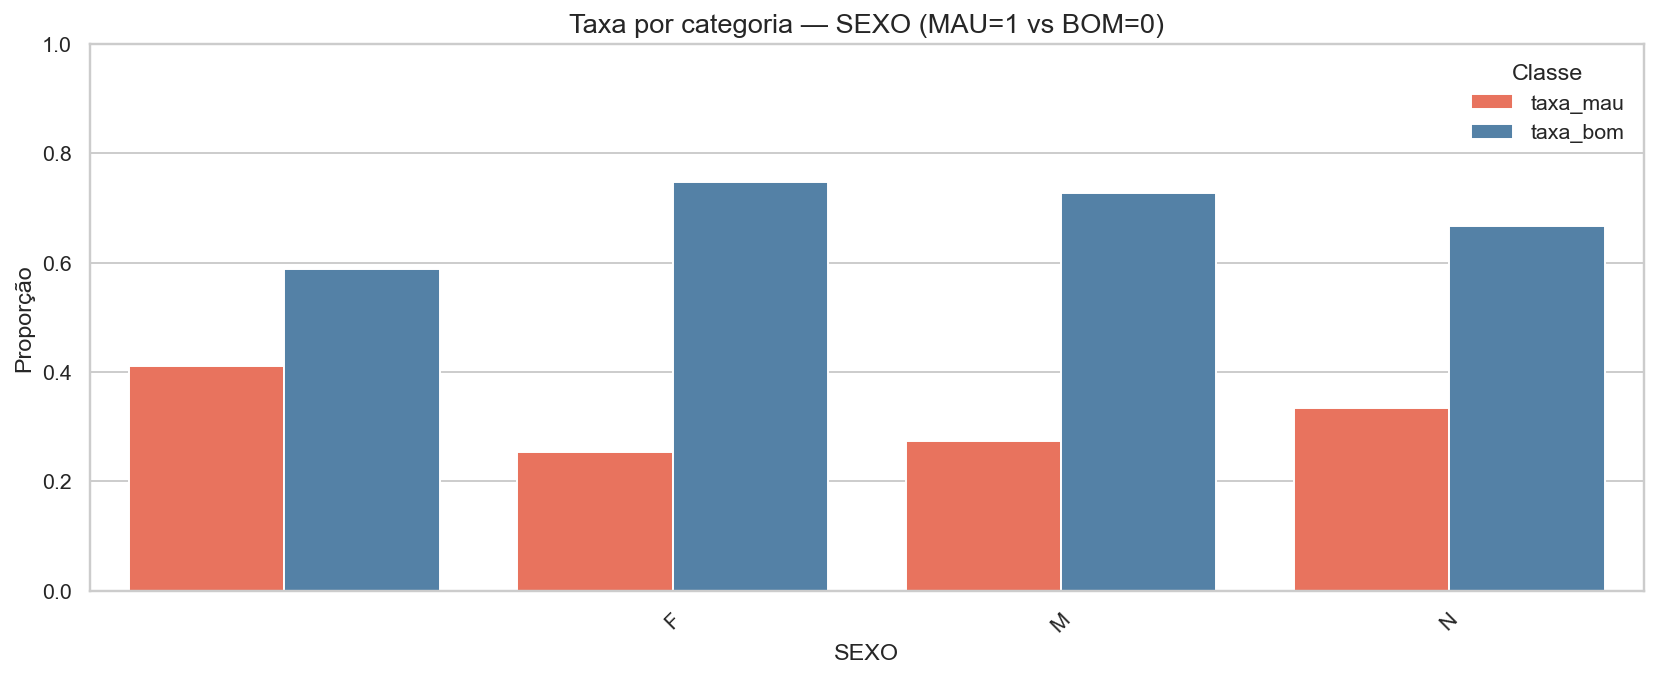

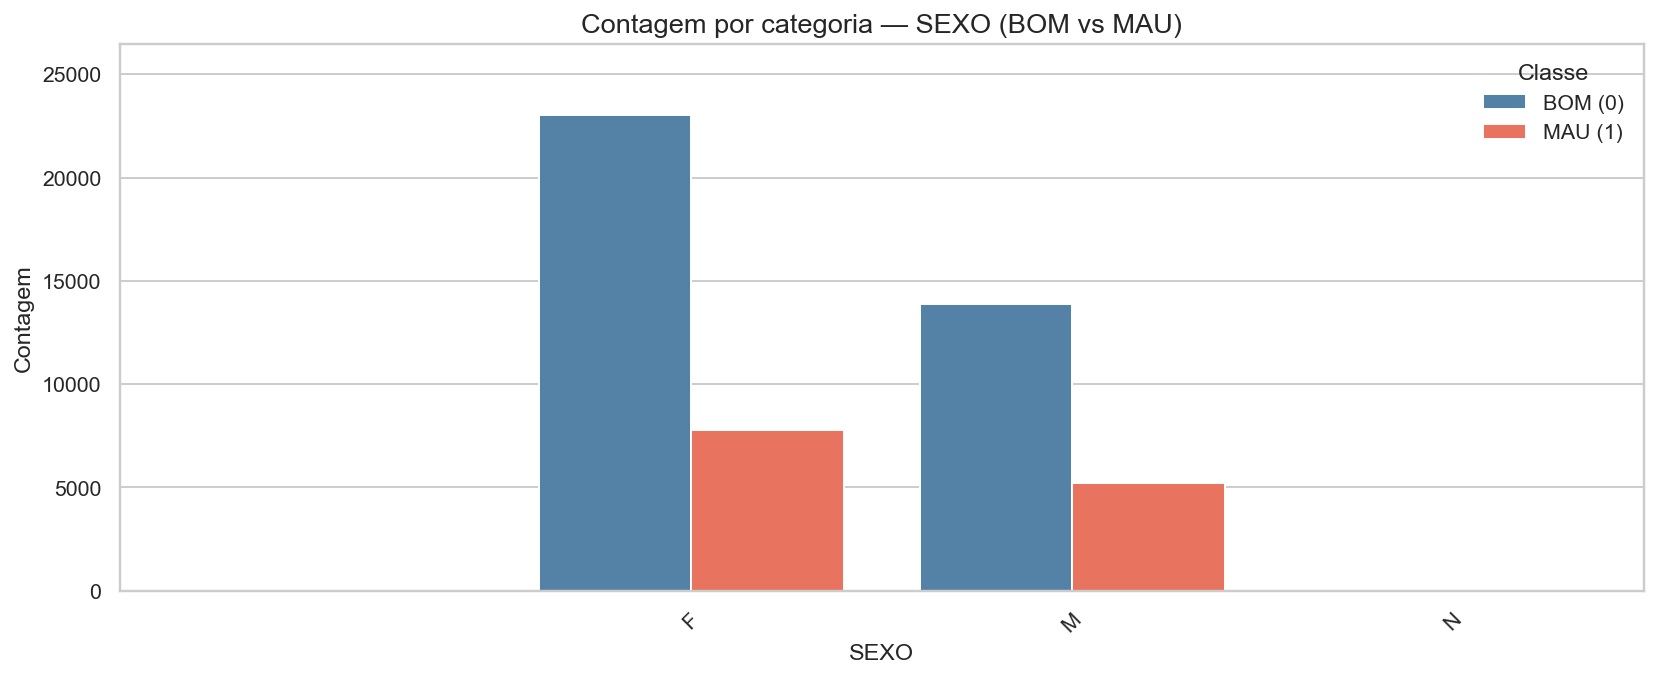


=== ESTADO_CIVIL — Comparação MAU (1) vs BOM (0) ===


,taxa_mau,freq,taxa_bom
ESTADO_CIVIL,,,
1,0.304527,15286,0.695473
6,0.291422,1877,0.708578
0,0.272277,202,0.727723
7,0.265918,534,0.734082
5,0.253858,1296,0.746142
2,0.241730,25967,0.758270
3,0.219937,632,0.780063
4,0.213267,4206,0.786733


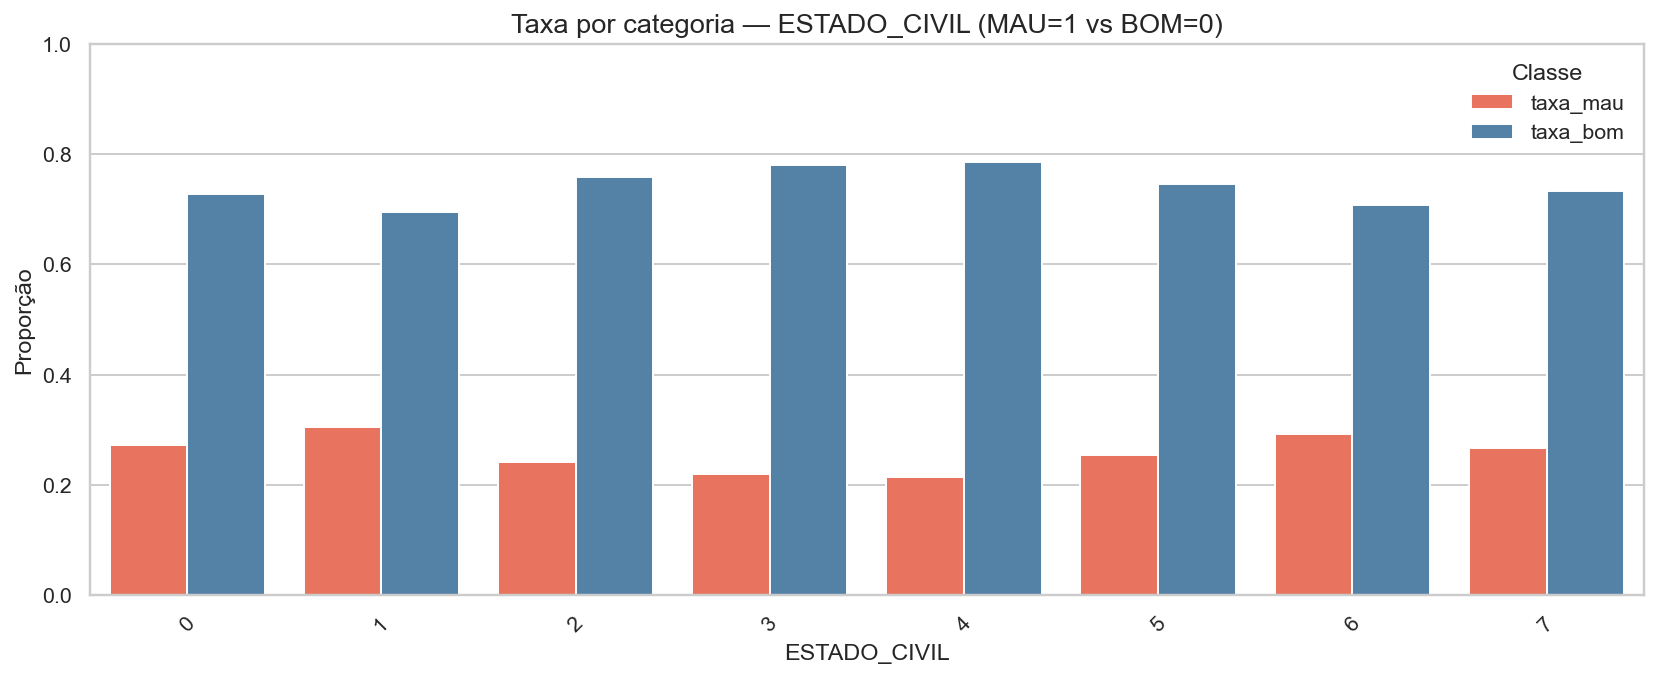

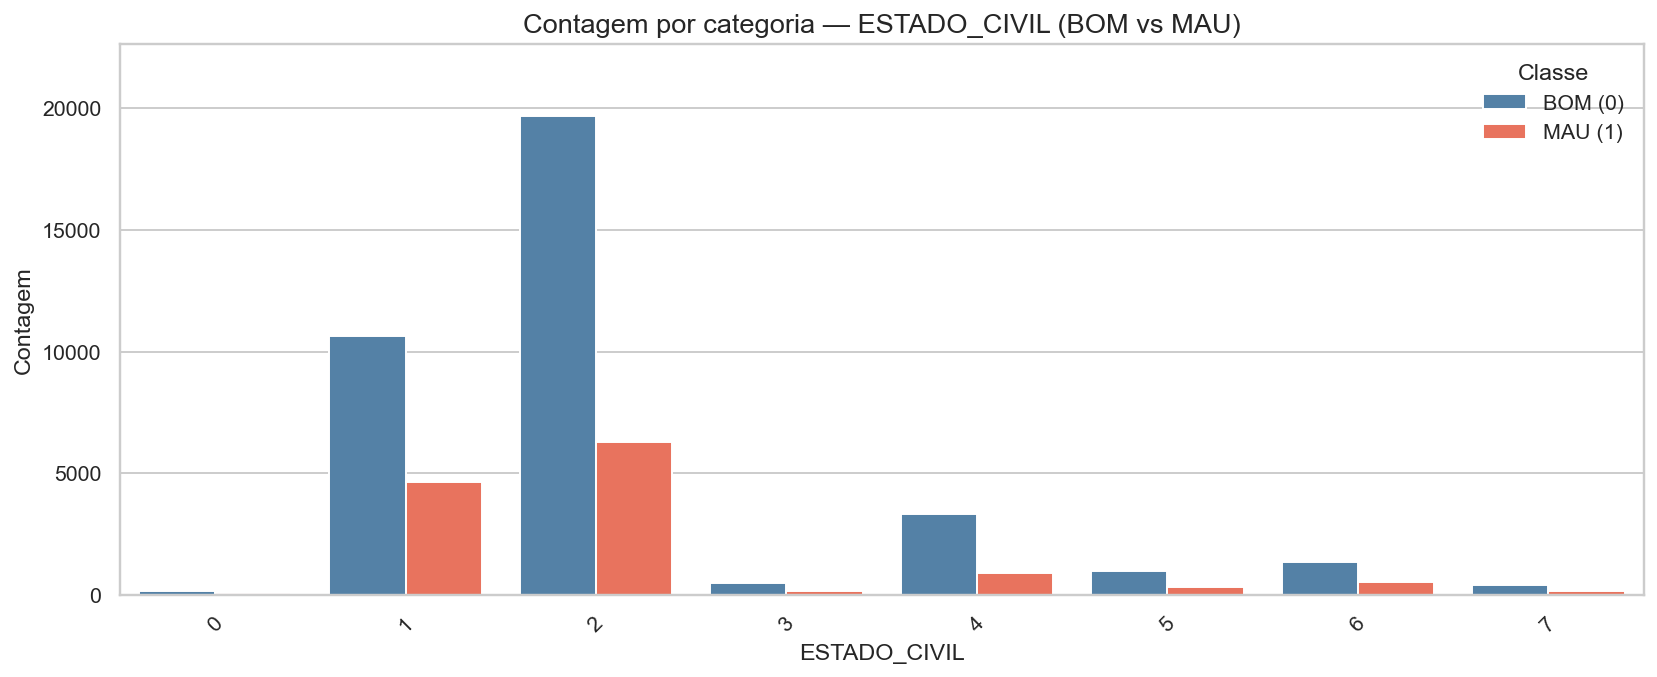


=== NIVEL_EDUCACIONAL — Comparação MAU (1) vs BOM (0) ===


,taxa_mau,freq,taxa_bom
NIVEL_EDUCACIONAL,,,
0,0.26082,50000,0.73918


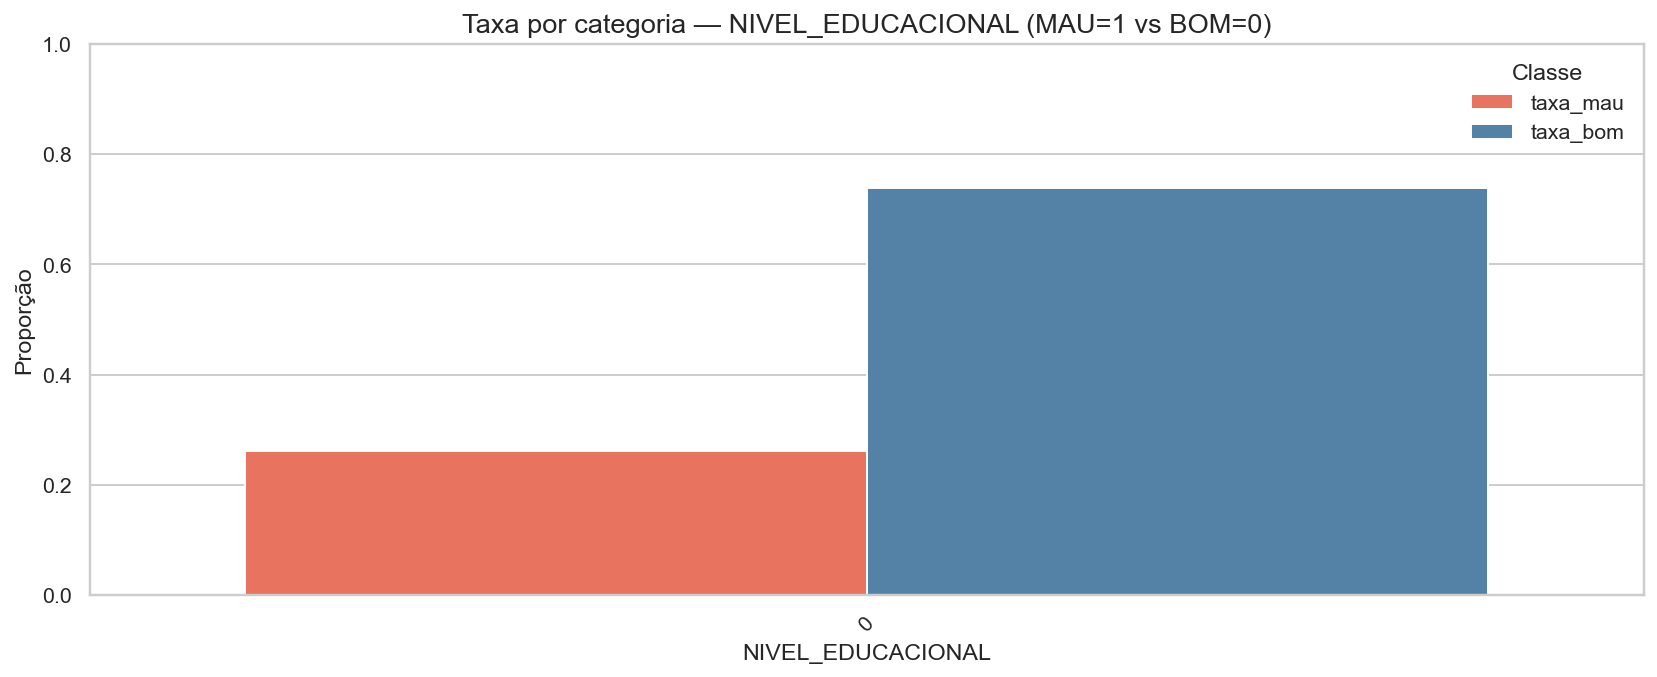

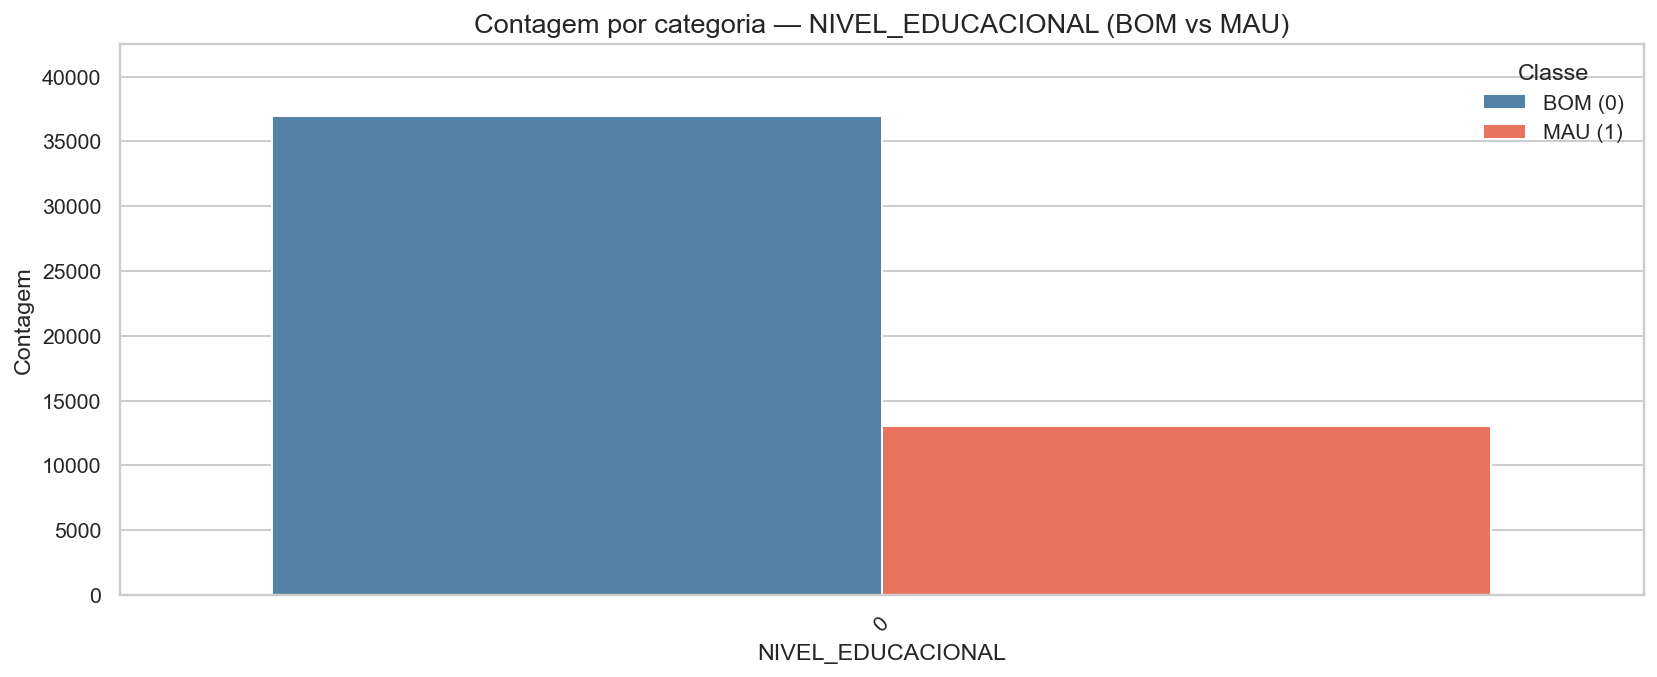

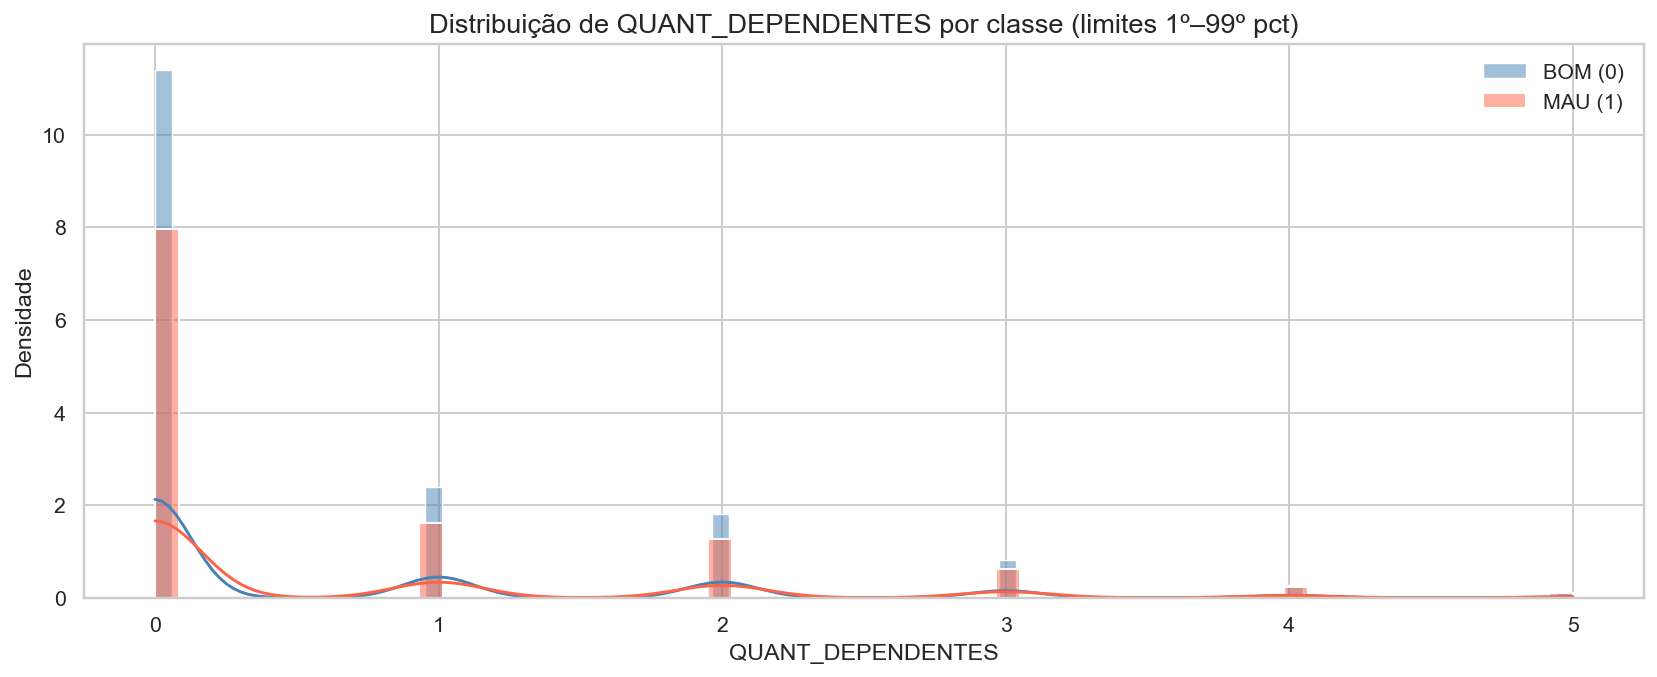

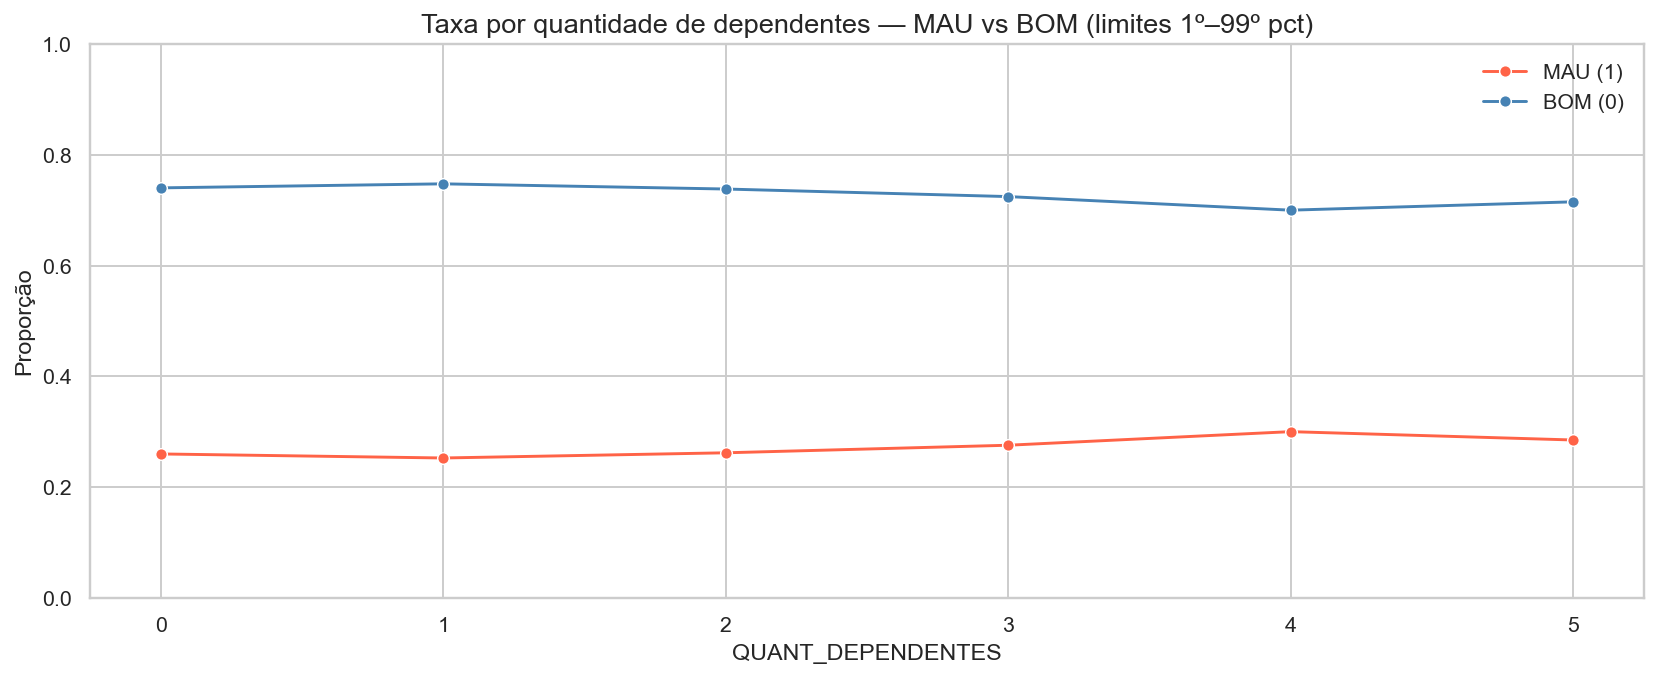

,taxa_mau,freq,taxa_bom
DEP_BIN,,,
0,0.259724,33655,0.740276
1-2,0.256489,12367,0.743511
3-4,0.281805,3325,0.718195
5+,0.292496,653,0.707504


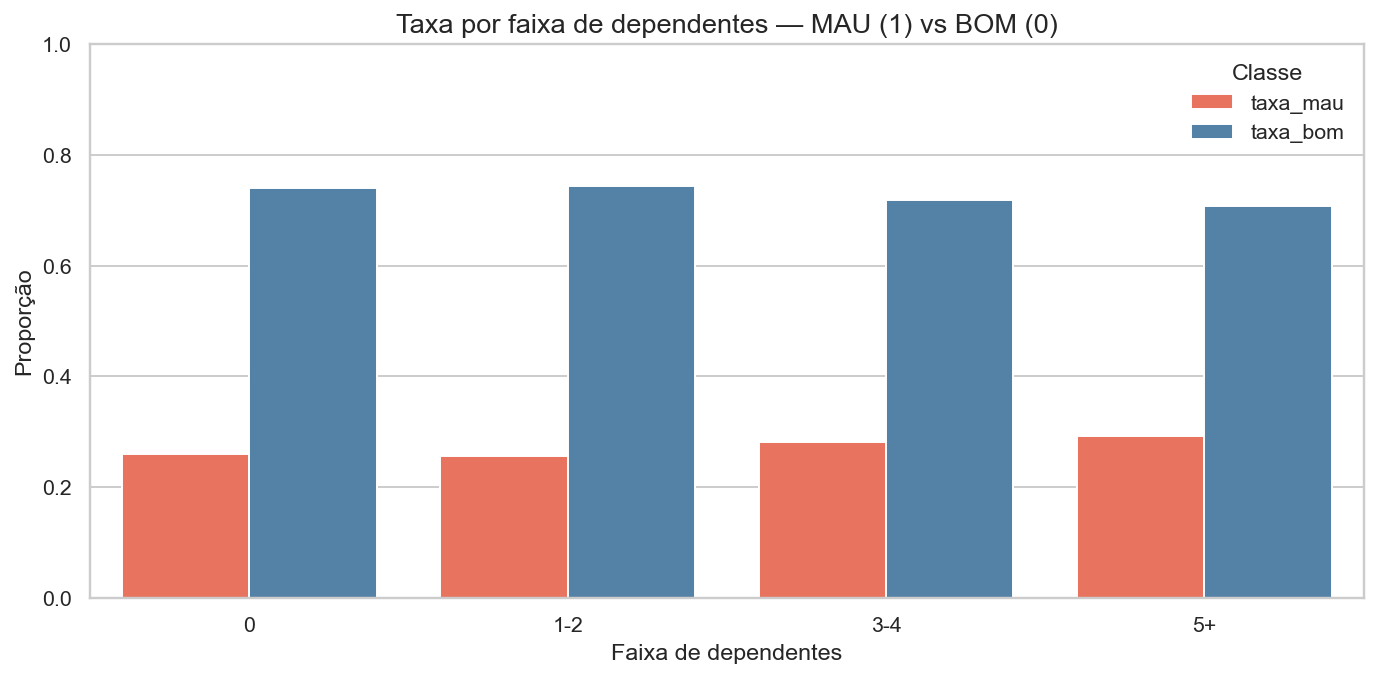

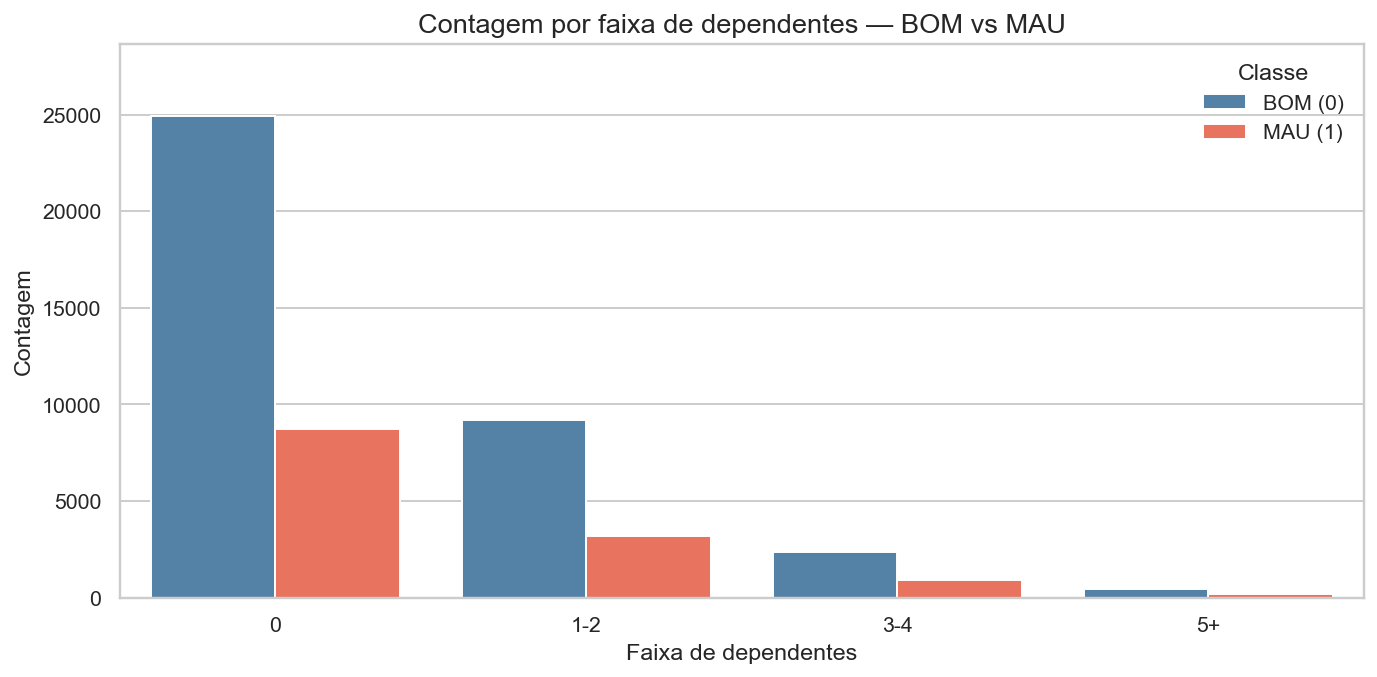

In [22]:
# %% Análise focada em 1=MAU e 0=BOM, com gráficos para ambas as classes
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ----------------------------
# 0) Preparação do alvo e das features
# ----------------------------
target = 'ROTULO_ALVO_MAU_1'      # 1 = MAU, 0 = BOM
df[target] = pd.to_numeric(df[target], errors='coerce').astype('Int64')
df['target_num'] = df[target].astype('int')
df['classe_txt'] = df['target_num'].map({0: 'BOM (0)', 1: 'MAU (1)'}).astype('category')

# Converter categóricas para 'category'
for c in ['SEXO', 'ESTADO_CIVIL', 'NIVEL_EDUCACIONAL']:
    if c in df.columns:
        df[c] = df[c].astype('category')

# Dependentes como numérica
if 'QUANT_DEPENDENTES' in df.columns:
    df['QUANT_DEPENDENTES'] = pd.to_numeric(df['QUANT_DEPENDENTES'], errors='coerce')

# ----------------------------
# Funções auxiliares de visualização
# ----------------------------
def barras_taxa_mau_vs_bom(df, col, min_freq=1):
    """
    Mostra duas visões:
      (a) Taxa de MAU por categoria, lado a lado com taxa de BOM (1 - taxa_mau).
      (b) Contagem de observações por categoria, lado a lado por classe (BOM vs MAU).
    """
    print(f'\n=== {col} — Comparação MAU (1) vs BOM (0) ===')
    # Tabela de taxa de MAU e frequência total
    tab = df.groupby(col)['target_num'].agg(['mean', 'count']).rename(columns={'mean': 'taxa_mau', 'count': 'freq'})
    tab = tab[tab['freq'] >= min_freq].copy()
    tab['taxa_bom'] = 1.0 - tab['taxa_mau']
    display(tab.sort_values('taxa_mau', ascending=False))

    # (a) Barras lado a lado: taxa de MAU x taxa de BOM
    tab_plot = tab[['taxa_mau', 'taxa_bom']].reset_index().melt(id_vars=col, var_name='classe', value_name='taxa')
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))
    sns.barplot(data=tab_plot, x=col, y='taxa', hue='classe', palette=['tomato', 'steelblue'], ax=ax)
    ax.set_title(f'Taxa por categoria — {col} (MAU=1 vs BOM=0)')
    ax.set_xlabel(col); ax.set_ylabel('Proporção')
    ax.set_ylim(0, 1)  # proporções dentro de 0..1
    ax.legend(title='Classe', loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # (b) Contagem lado a lado: BOM vs MAU
    cont = pd.crosstab(df[col], df['classe_txt'])
    cont_plot = cont.reset_index().melt(id_vars=col, var_name='classe', value_name='contagem')
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))
    sns.barplot(data=cont_plot, x=col, y='contagem', hue='classe', palette=['steelblue', 'tomato'], ax=ax)
    ax.set_title(f'Contagem por categoria — {col} (BOM vs MAU)')
    ax.set_xlabel(col); ax.set_ylabel('Contagem')
    ymax = cont_plot['contagem'].max() * 1.15
    ax.set_ylim(0, ymax)
    ax.legend(title='Classe', loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def hist_dependentes_por_classe(df, col='QUANT_DEPENDENTES'):
    """
    Histogramas/KDE por classe (BOM vs MAU), com ajuste de escala por percentis (1º–99º)
    para reduzir a influência de outliers.
    Também plota a curva de taxa de MAU e BOM por valor de dependentes.
    """
    if col not in df.columns:
        print('Coluna de dependentes não encontrada.'); return

    s = df[col].dropna()
    if s.empty:
        print('Sem dados válidos para dependentes.'); return

    # Limites por percentis para melhor legibilidade
    low, high = np.percentile(s, [1, 99])
    df_clip = df[(df[col] >= low) & (df[col] <= high)].copy()

    # Histogramas por classe
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))
    sns.histplot(df_clip.loc[df_clip['target_num'] == 0, col], color='steelblue', label='BOM (0)', kde=True, stat='density', ax=ax)
    sns.histplot(df_clip.loc[df_clip['target_num'] == 1, col], color='tomato', label='MAU (1)', kde=True, stat='density', ax=ax)
    ax.set_title(f'Distribuição de {col} por classe (limites 1º–99º pct)')
    ax.set_xlabel(col); ax.set_ylabel('Densidade')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Taxa por valor de dependentes — duas linhas (MAU e BOM)
    dep_rate = df_clip.groupby(col)['target_num'].mean().rename('taxa_mau').to_frame()
    dep_rate['taxa_bom'] = 1.0 - dep_rate['taxa_mau']
    dep_rate = dep_rate.reset_index()

    fig, ax = plt.subplots(1, 1, figsize=(12, 5))
    sns.lineplot(x=col, y='taxa_mau', data=dep_rate, marker='o', color='tomato', label='MAU (1)', ax=ax)
    sns.lineplot(x=col, y='taxa_bom', data=dep_rate, marker='o', color='steelblue', label='BOM (0)', ax=ax)
    ax.set_title(f'Taxa por quantidade de dependentes — MAU vs BOM (limites 1º–99º pct)')
    ax.set_xlabel(col); ax.set_ylabel('Proporção')
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

def binning_dependentes_comparacao(df, col='QUANT_DEPENDENTES'):
    """
    Binning em faixas de dependentes e comparação MAU vs BOM:
      - Barras de taxa (MAU x BOM)
      - Contagem por faixa e classe
    """
    if col not in df.columns:
        print('Coluna de dependentes não encontrada.'); return

    labels = ['0', '1-2', '3-4', '5+']
    bins = [-np.inf, 0, 2, 4, np.inf]
    df['DEP_BIN'] = pd.cut(df[col], bins=bins, labels=labels)

    # Tabela de taxa e frequência
    tab = df.groupby('DEP_BIN')['target_num'].agg(['mean','count']).rename(columns={'mean':'taxa_mau','count':'freq'}).copy()
    tab['taxa_bom'] = 1.0 - tab['taxa_mau']
    display(tab)

    # Barras taxa MAU vs BOM
    tab_plot = tab[['taxa_mau','taxa_bom']].reset_index().melt(id_vars='DEP_BIN', var_name='classe', value_name='taxa')
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sns.barplot(data=tab_plot, x='DEP_BIN', y='taxa', hue='classe', palette=['tomato','steelblue'], ax=ax)
    ax.set_title('Taxa por faixa de dependentes — MAU (1) vs BOM (0)')
    ax.set_xlabel('Faixa de dependentes'); ax.set_ylabel('Proporção')
    ax.set_ylim(0, 1)
    ax.legend(title='Classe')
    plt.tight_layout()
    plt.show()

    # Contagem por faixa e classe
    cont = pd.crosstab(df['DEP_BIN'], df['classe_txt']).reset_index().melt(id_vars='DEP_BIN', var_name='classe', value_name='contagem')
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sns.barplot(data=cont, x='DEP_BIN', y='contagem', hue='classe', palette=['steelblue','tomato'], ax=ax)
    ax.set_title('Contagem por faixa de dependentes — BOM vs MAU')
    ax.set_xlabel('Faixa de dependentes'); ax.set_ylabel('Contagem')
    ymax = cont['contagem'].max() * 1.15
    ax.set_ylim(0, ymax)
    ax.legend(title='Classe')
    plt.tight_layout()
    plt.show()

# ----------------------------
# 1) SEXO — gráficos para MAU e BOM
# ----------------------------
if 'SEXO' in df.columns:
    barras_taxa_mau_vs_bom(df, 'SEXO', min_freq=1)
    # Interpretação:
    # - Barras mais altas em 'taxa_mau' indicam maior proporção de MAU naquela categoria.
    # - A comparação com 'taxa_bom' revela o contraste entre as classes.

# ----------------------------
# 2) ESTADO_CIVIL — gráficos para MAU e BOM
# ----------------------------
if 'ESTADO_CIVIL' in df.columns:
    barras_taxa_mau_vs_bom(df, 'ESTADO_CIVIL', min_freq=1)
    # Interpretação:
    # - Diferenças de taxa entre 'solteiro', 'casado' etc. podem indicar perfis distintos de risco.
    # - Use junto da contagem para avaliar robustez amostral de cada categoria.

# ----------------------------
# 3) NIVEL_EDUCACIONAL — gráficos para MAU e BOM
# ----------------------------
if 'NIVEL_EDUCACIONAL' in df.columns:
    barras_taxa_mau_vs_bom(df, 'NIVEL_EDUCACIONAL', min_freq=1)
    # Interpretação:
    # - Taxas mais altas em certos níveis sugerem associação com inadimplência.
    # - Lembre que correlação ≠ causalidade; variáveis podem captar efeitos socioeconômicos mais amplos.

# ----------------------------
# 4) QUANT_DEPENDENTES — gráficos para MAU e BOM
# ----------------------------
if 'QUANT_DEPENDENTES' in df.columns:
    hist_dependentes_por_classe(df, col='QUANT_DEPENDENTES')
    binning_dependentes_comparacao(df, col='QUANT_DEPENDENTES')
    # Interpretação:
    # - Histogramas/KDE por classe mostram a distribuição de dependentes em BOM vs MAU.
    # - As linhas de taxa por valor revelam tendência (ex.: mais dependentes → maior/menor taxa de MAU).
    # - O binning estabiliza a leitura (por faixas) e facilita a comparação de MAU vs BOM.


Dentro da variável target, Maus pagadores têm maior proporção no gênero masculino, o estado civil 1 possui maior proporção de maus pagadores, o nível educacional de maus pagadores é menor se comparado a bons e a taxa de maus pagadores sobe a partir de 3 dependentes.

In [23]:

# %% Preparação
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

target = 'ROTULO_ALVO_MAU_1'  # 1 = MAU, 0 = BOM
df[target] = pd.to_numeric(df[target], errors='coerce').astype('Int64')
df['target_num'] = df[target].astype('int')              # para cálculos/agrupamentos
df['classe_txt'] = df['target_num'].map({0: 'BOM (0)', 1: 'MAU (1)'}).astype('category')

# Converter categóricas para category
for c in ['SEXO', 'ESTADO_CIVIL', 'NIVEL_EDUCACIONAL']:
    if c in df.columns:
        df[c] = df[c].astype('category')

# Dependentes como numérica
if 'QUANT_DEPENDENTES' in df.columns:
    df['QUANT_DEPENDENTES'] = pd.to_numeric(df['QUANT_DEPENDENTES'], errors='coerce')



=== SEXO — Qui-quadrado & Cramér's V ===


target_num,0,1
SEXO,,
,10,7
F,23015,7790
M,13902,5228
N,32,16


Qui-quadrado: chi2=28.814, p-valor=2.45e-06, gl=3
Cramér's V: 0.024 (0=sem associação; ~0.1=fraca; ~0.3=média; ~0.5=f Forte)


,taxa_mau,freq,taxa_bom
SEXO,,,
,0.411765,17,0.588235
N,0.333333,48,0.666667
M,0.273288,19130,0.726712
F,0.252881,30805,0.747119


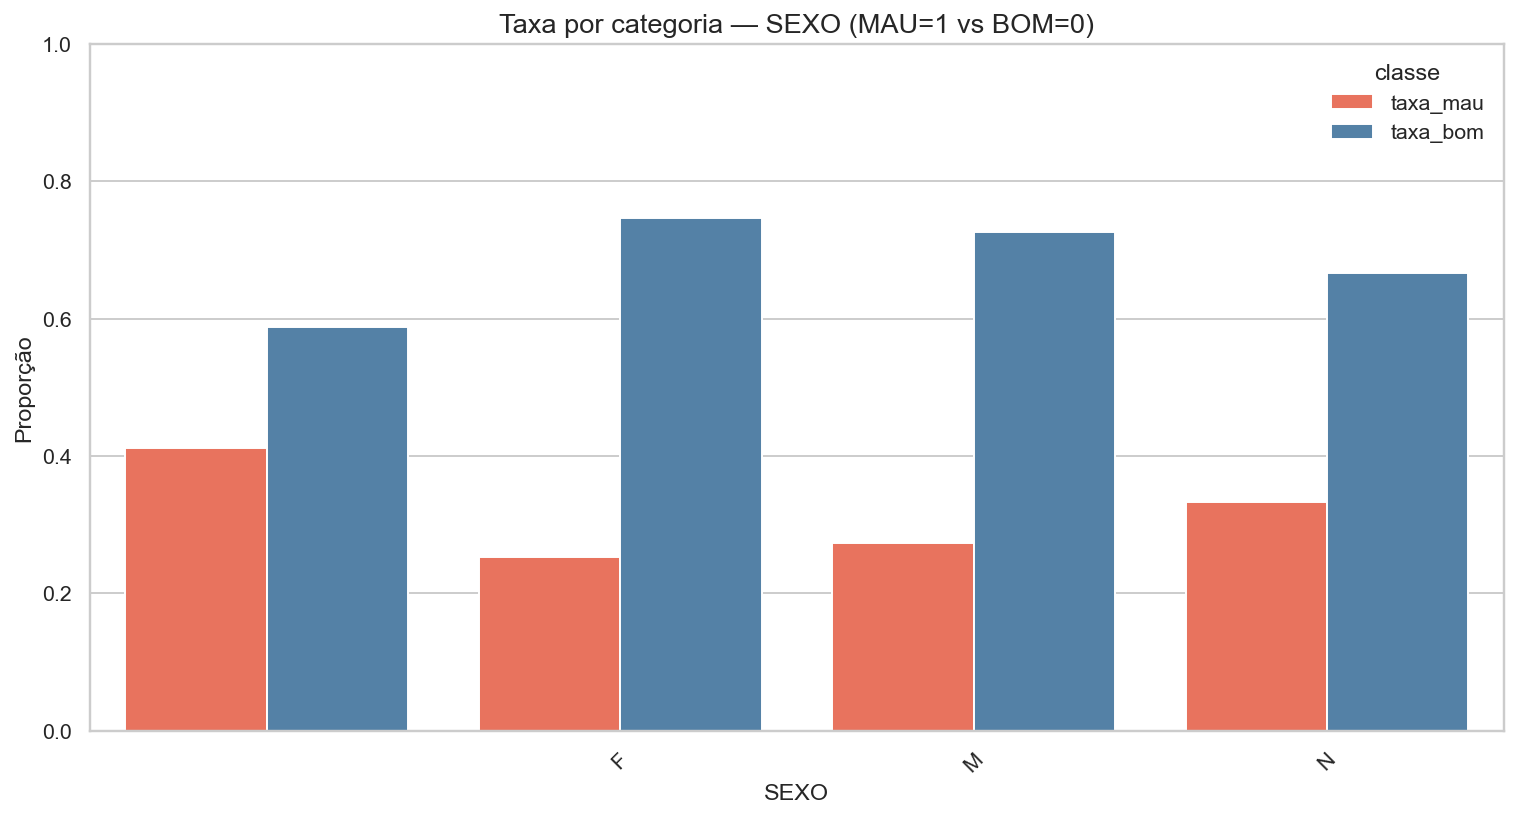


=== ESTADO_CIVIL — Qui-quadrado & Cramér's V ===


target_num,0,1
ESTADO_CIVIL,,
0,147,55
1,10631,4655
2,19690,6277
3,493,139
4,3309,897
5,967,329
6,1330,547
7,392,142


Qui-quadrado: chi2=265.013, p-valor=1.76e-53, gl=7
Cramér's V: 0.073 (0=sem associação; ~0.1=fraca; ~0.3=média; ~0.5=f Forte)


,taxa_mau,freq,taxa_bom
ESTADO_CIVIL,,,
1,0.304527,15286,0.695473
6,0.291422,1877,0.708578
0,0.272277,202,0.727723
7,0.265918,534,0.734082
5,0.253858,1296,0.746142
2,0.241730,25967,0.758270
3,0.219937,632,0.780063
4,0.213267,4206,0.786733


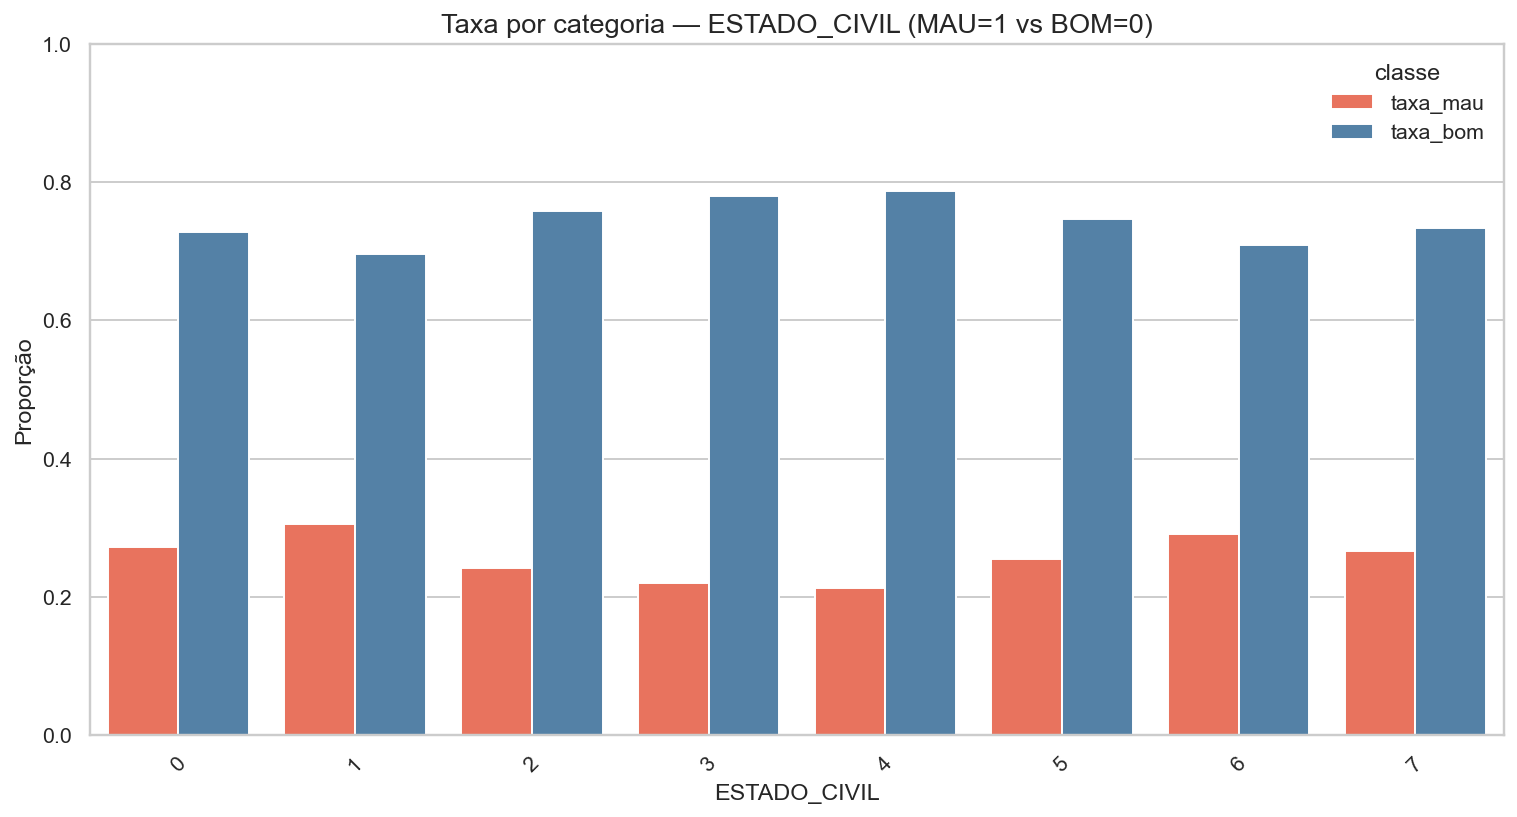


=== NIVEL_EDUCACIONAL — Qui-quadrado & Cramér's V ===


target_num,0,1
NIVEL_EDUCACIONAL,,
0,36959,13041


Qui-quadrado não aplicável (contingência insuficiente).


,taxa_mau,freq,taxa_bom
NIVEL_EDUCACIONAL,,,
0,0.26082,50000,0.73918


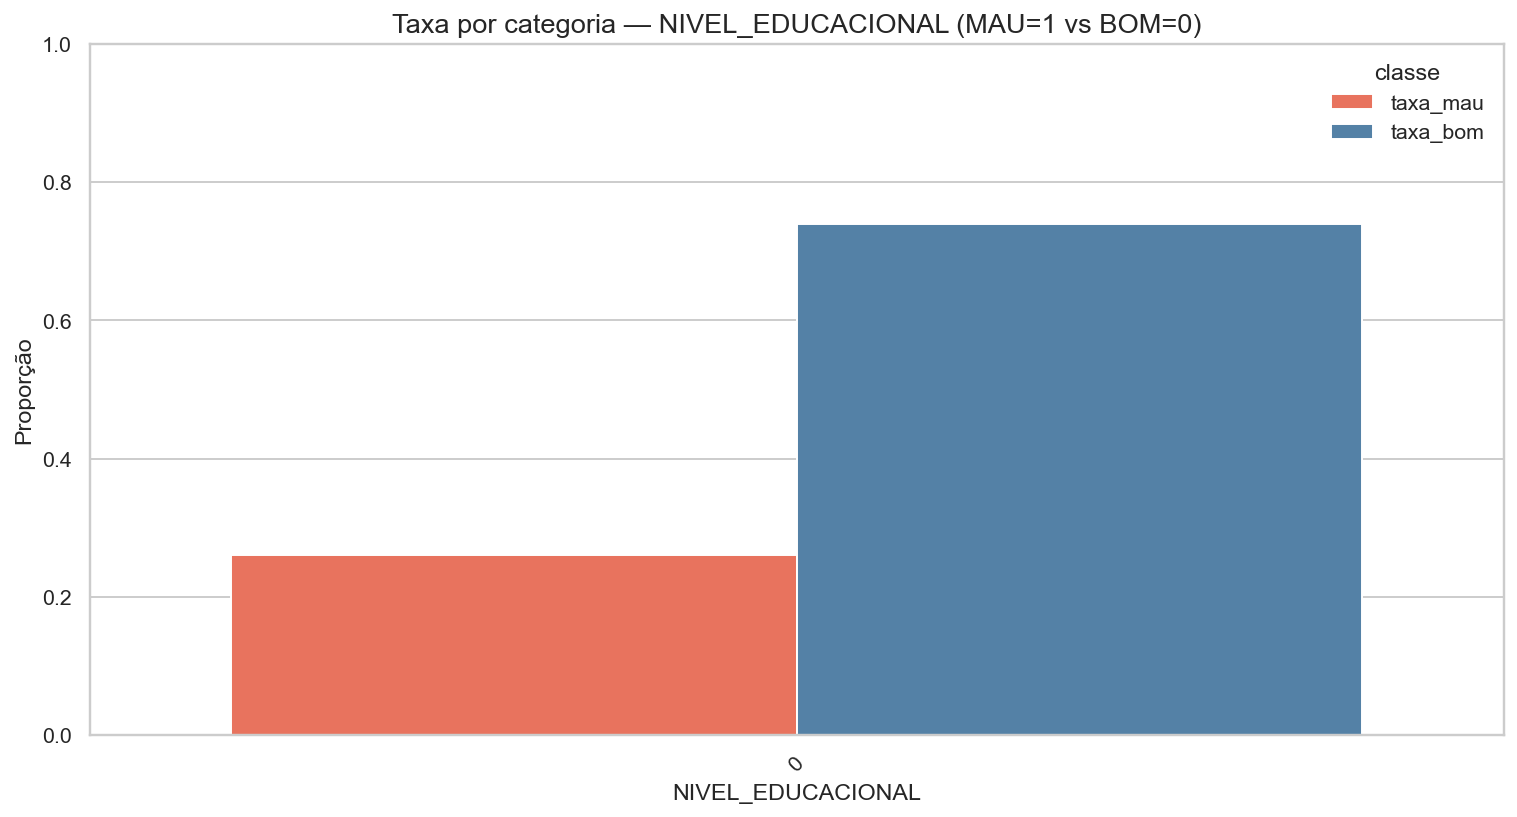


=== DEP_BIN — Qui-quadrado & Cramér's V ===


target_num,0,1
DEP_BIN,,
0,24914,8741
1-2,9195,3172
3-4,2388,937
5+,462,191


Qui-quadrado: chi2=12.406, p-valor=0.00611, gl=3
Cramér's V: 0.016 (0=sem associação; ~0.1=fraca; ~0.3=média; ~0.5=f Forte)


,taxa_mau,freq,taxa_bom
DEP_BIN,,,
5+,0.292496,653,0.707504
3-4,0.281805,3325,0.718195
0,0.259724,33655,0.740276
1-2,0.256489,12367,0.743511


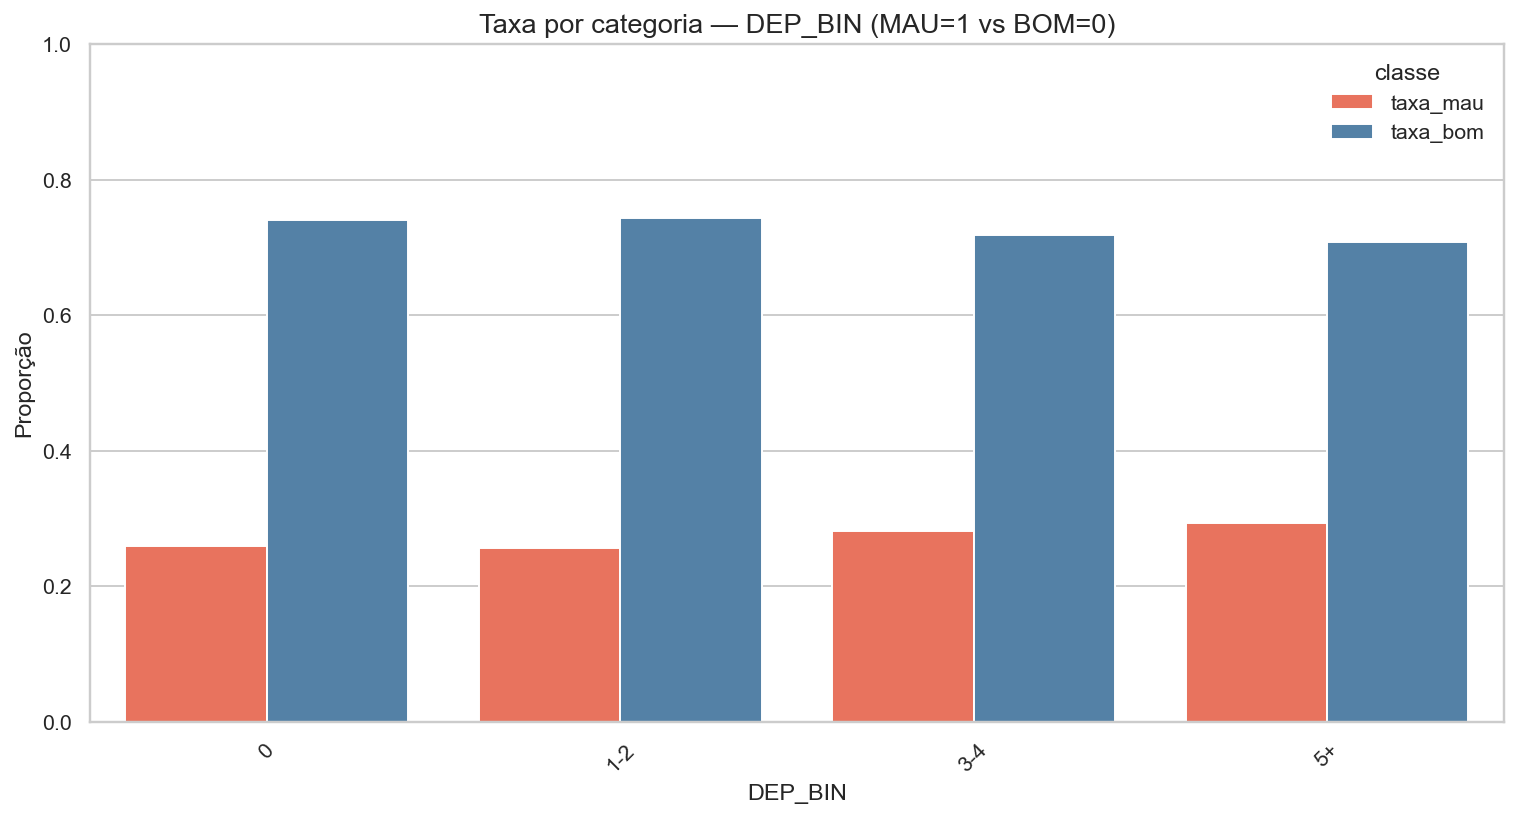

In [24]:

# %% Qui-quadrado + Cramér's V e taxas MAU/BOM
from scipy import stats

def chi2_cramers_v(df, col, target='target_num', min_freq=1, mostrar_graficos=True):
    """
    Calcula: contingência, qui-quadrado, p-valor, gl, Cramér's V.
    Também retorna tabela com taxa de MAU e BOM por categoria.
    """
    print(f'\n=== {col} — Qui-quadrado & Cramér\'s V ===')
    # Filtrar categorias com freq >= min_freq
    freq = df[col].value_counts()
    categorias_validas = freq[freq >= min_freq].index
    df_use = df[df[col].isin(categorias_validas)].copy()

    contingencia = pd.crosstab(df_use[col], df_use[target])
    display(contingencia)

    if contingencia.shape[0] > 1 and contingencia.shape[1] == 2:
        chi2, p, dof, expected = stats.chi2_contingency(contingencia)
        n = contingencia.to_numpy().sum()
        # Cramér's V
        k = min(contingencia.shape)  # min(num linhas, num colunas)
        cramers_v = np.sqrt(chi2 / (n * (k - 1))) if (k - 1) > 0 else np.nan

        print(f'Qui-quadrado: chi2={chi2:.3f}, p-valor={p:.3g}, gl={dof}')
        print(f'Cramér\'s V: {cramers_v:.3f} (0=sem associação; ~0.1=fraca; ~0.3=média; ~0.5=f Forte)')
    else:
        chi2 = p = dof = cramers_v = np.nan
        print('Qui-quadrado não aplicável (contingência insuficiente).')

    # Tabela de taxas (MAU e BOM)
    tab = df_use.groupby(col)[target].agg(['mean','count']).rename(columns={'mean':'taxa_mau','count':'freq'})
    tab['taxa_bom'] = 1.0 - tab['taxa_mau']
    display(tab.sort_values('taxa_mau', ascending=False))

    if mostrar_graficos:
        # Barras lado a lado (taxa MAU vs BOM)
        tab_plot = tab[['taxa_mau','taxa_bom']].reset_index().melt(id_vars=col, var_name='classe', value_name='taxa')
        ax = sns.barplot(data=tab_plot, x=col, y='taxa', hue='classe', palette=['tomato','steelblue'])
        ax.set_title(f'Taxa por categoria — {col} (MAU=1 vs BOM=0)')
        ax.set_xlabel(col); ax.set_ylabel('Proporção'); ax.set_ylim(0, 1)
        plt.xticks(rotation=45); plt.tight_layout(); plt.show()

    return {'col': col, 'chi2': chi2, 'p': p, 'dof': dof, 'cramers_v': cramers_v, 'tabela': tab}

# Executar para as categorias
resultados_chi2 = []
for col in ['SEXO', 'ESTADO_CIVIL', 'NIVEL_EDUCACIONAL']:
    if col in df.columns:
        res = chi2_cramers_v(df, col, target='target_num', min_freq=1, mostrar_graficos=True)
        resultados_chi2.append(res)

# Opcional: Qui-quadrado para dependentes usando binning (transforma numérico em faixas)
if 'QUANT_DEPENDENTES' in df.columns:
    labels = ['0', '1-2', '3-4', '5+']
    bins = [-np.inf, 0, 2, 4, np.inf]
    df['DEP_BIN'] = pd.cut(df['QUANT_DEPENDENTES'], bins=bins, labels=labels)
    res_dep = chi2_cramers_v(df, 'DEP_BIN', target='target_num', min_freq=1, mostrar_graficos=True)
    resultados_chi2.append(res_dep)


Qui‑quadrado de independência:p‑valor → se p < 0,05, há evidência de associação entre a categoria e BOM/MAU
Cramér’s V (força da associação entre 0 e 1): ~0.10 fraca, ~0.30 média, ~0.50 forte

Relação: Associação entre bom e mau é fraca em gênero, em estado civil e temos associação forte em nível educacional.
Quão forte: Fraca em gênero, em estado civil e nível educacional.
Quem é mais arriscado: homens e estado civil 1.


### 2.2 Plote um gráfico que mostre a distribuição de bons e maus pagadores por estado. Escolha o gráfico que achar mais conveniente

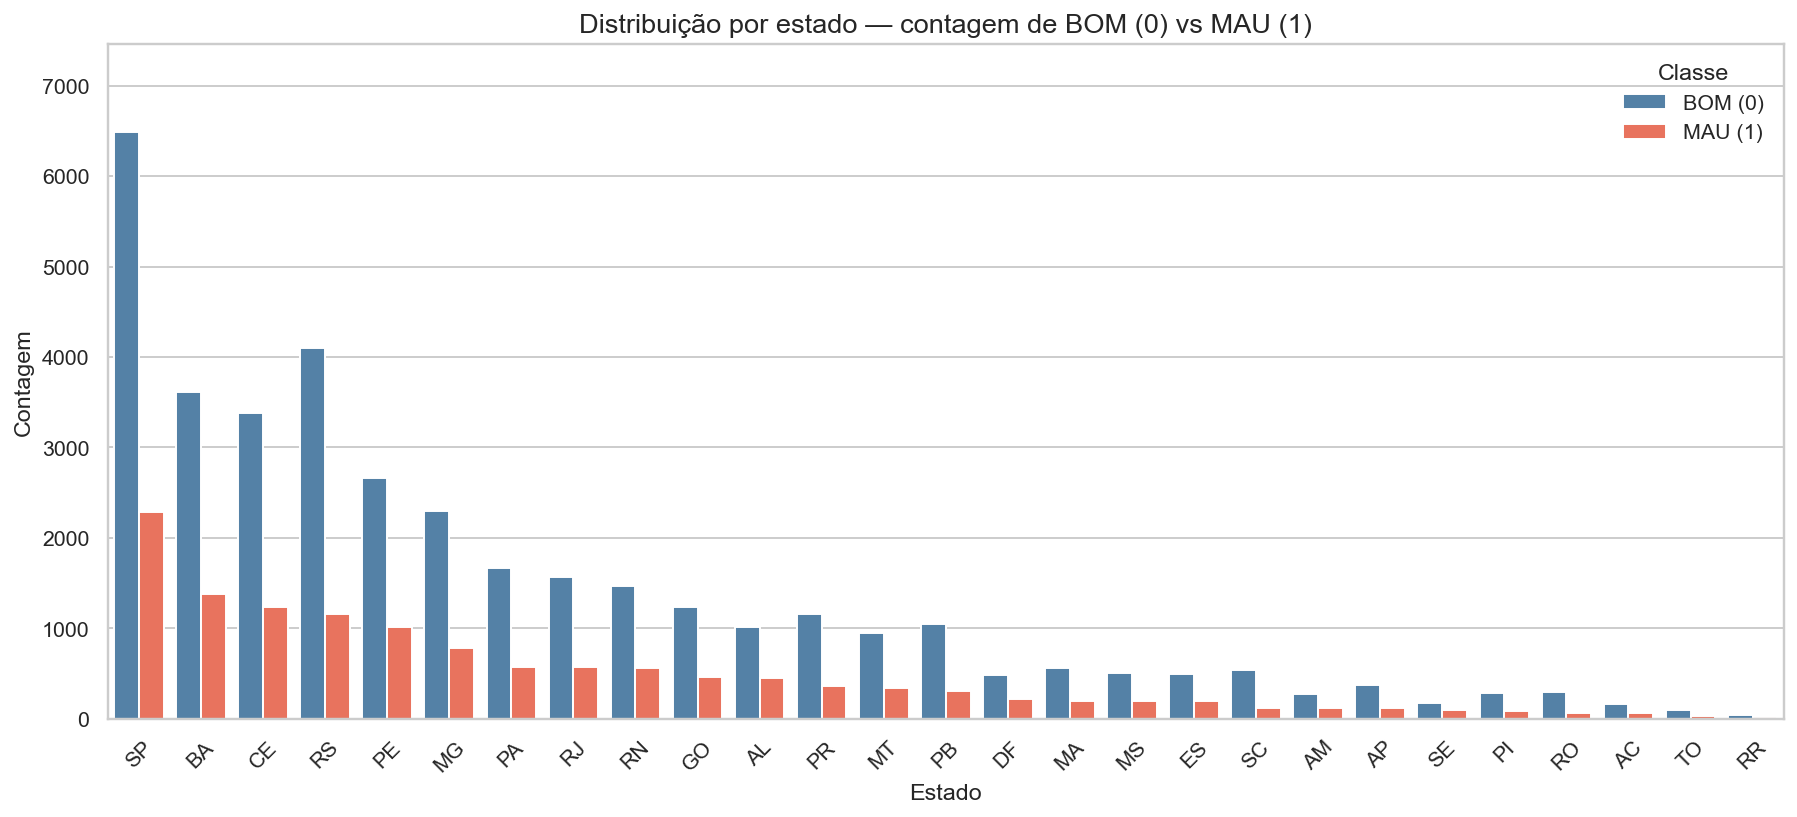

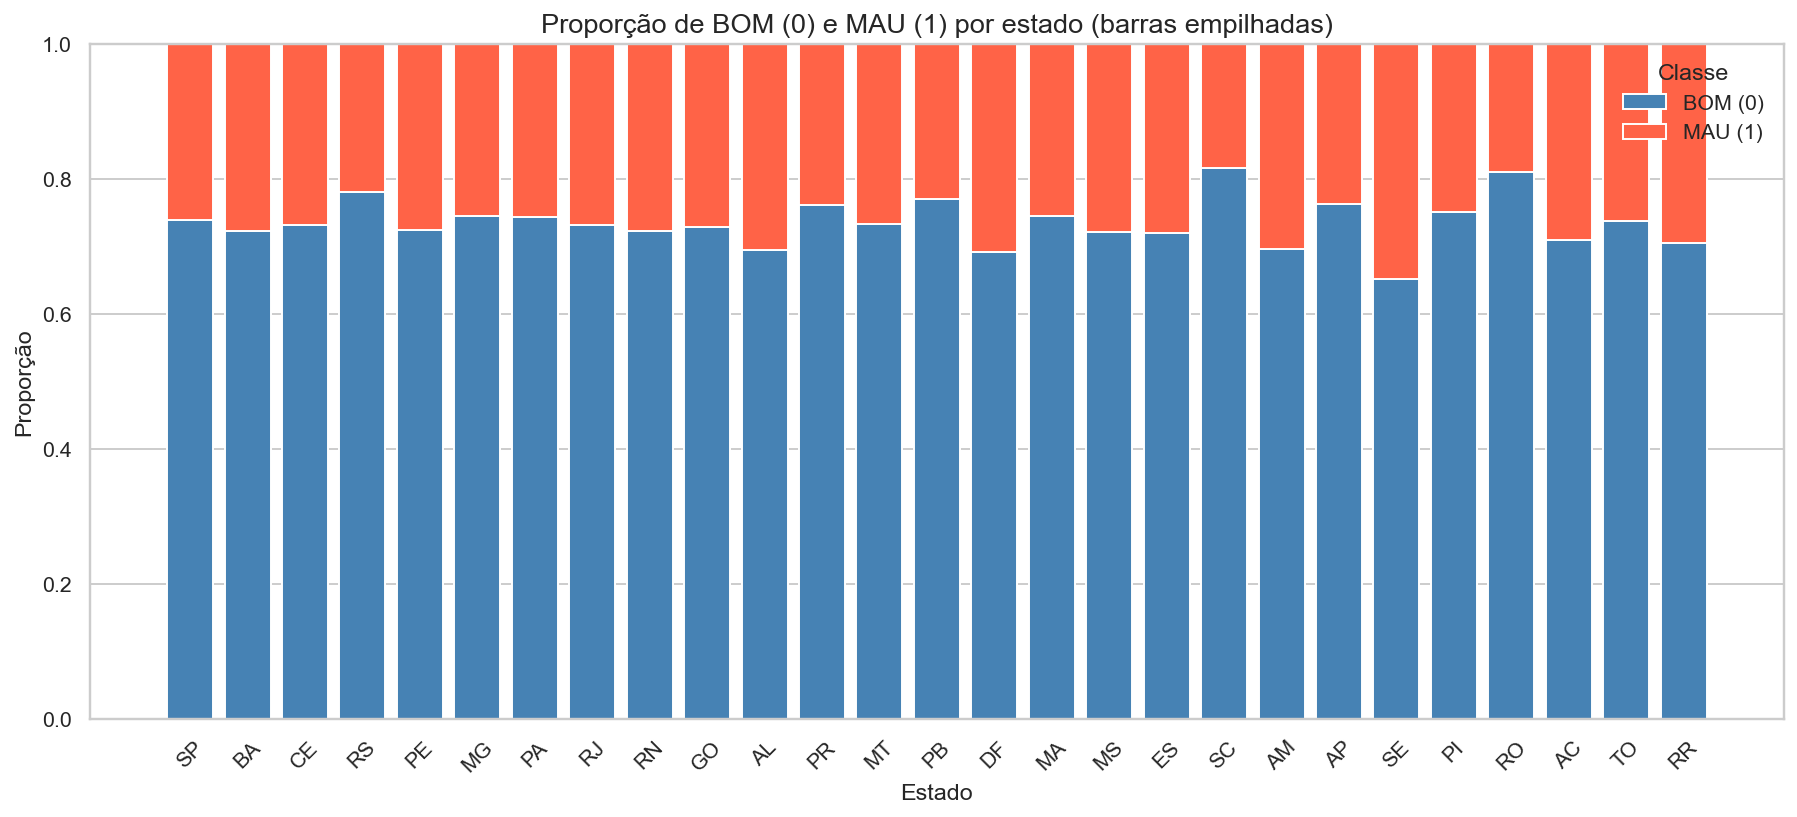

In [25]:
# %% Distribuição de bons e maus pagadores por estado
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ajuste aqui se o nome da coluna for diferente
col_estado = 'ESTADO_RESIDENCIA'
target = 'ROTULO_ALVO_MAU_1'

# Preparação do alvo e do texto da classe
df[target] = pd.to_numeric(df[target], errors='coerce').astype('Int64')
df['target_num'] = df[target].astype('int')
df['classe_txt'] = df['target_num'].map({0: 'BOM (0)', 1: 'MAU (1)'}).astype('category')

# Filtrar estados válidos (evitar NaN ou strings vazias)
df_estado = df.dropna(subset=[col_estado]).copy()
df_estado[col_estado] = df_estado[col_estado].astype('category')

# -------------------------------------------
# 1) Barras lado a lado (contagem BOM vs MAU)
# -------------------------------------------
cont = pd.crosstab(df_estado[col_estado], df_estado['classe_txt'])
cont_plot = cont.reset_index().melt(id_vars=col_estado, var_name='classe', value_name='contagem')

# Ordenar por MAU (1) decrescente para destacar estados com maior número de inadimplentes
ordem_estados = cont.sort_values(by='MAU (1)', ascending=False).index.tolist()
cont_plot[col_estado] = pd.Categorical(cont_plot[col_estado], categories=ordem_estados, ordered=True)

fig, ax = plt.subplots(1, 1)
sns.barplot(data=cont_plot, x=col_estado, y='contagem', hue='classe',
            palette=['steelblue', 'tomato'], ax=ax)
ax.set_title('Distribuição por estado — contagem de BOM (0) vs MAU (1)')
ax.set_xlabel('Estado')
ax.set_ylabel('Contagem')
ymax = cont_plot['contagem'].max() * 1.15
ax.set_ylim(0, ymax)
ax.legend(title='Classe', loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 2) Barras empilhadas normalizadas (proporção por estado)
# ------------------------------------------------------
# Proporção por estado
prop = cont.div(cont.sum(axis=1), axis=0)  # divide cada linha pela soma → 0..1
prop = prop.loc[ordem_estados]  # mesma ordem dos estados

fig, ax = plt.subplots(1, 1)
# Plotar parte BOM (0)
ax.bar(prop.index, prop['BOM (0)'], label='BOM (0)', color='steelblue')
# Empilhar parte MAU (1) por cima
ax.bar(prop.index, prop['MAU (1)'], bottom=prop['BOM (0)'], label='MAU (1)', color='tomato')

ax.set_title('Proporção de BOM (0) e MAU (1) por estado (barras empilhadas)')
ax.set_xlabel('Estado')
ax.set_ylabel('Proporção')
ax.set_ylim(0, 1)  # sempre entre 0 e 1
ax.legend(loc='upper right', title='Classe')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

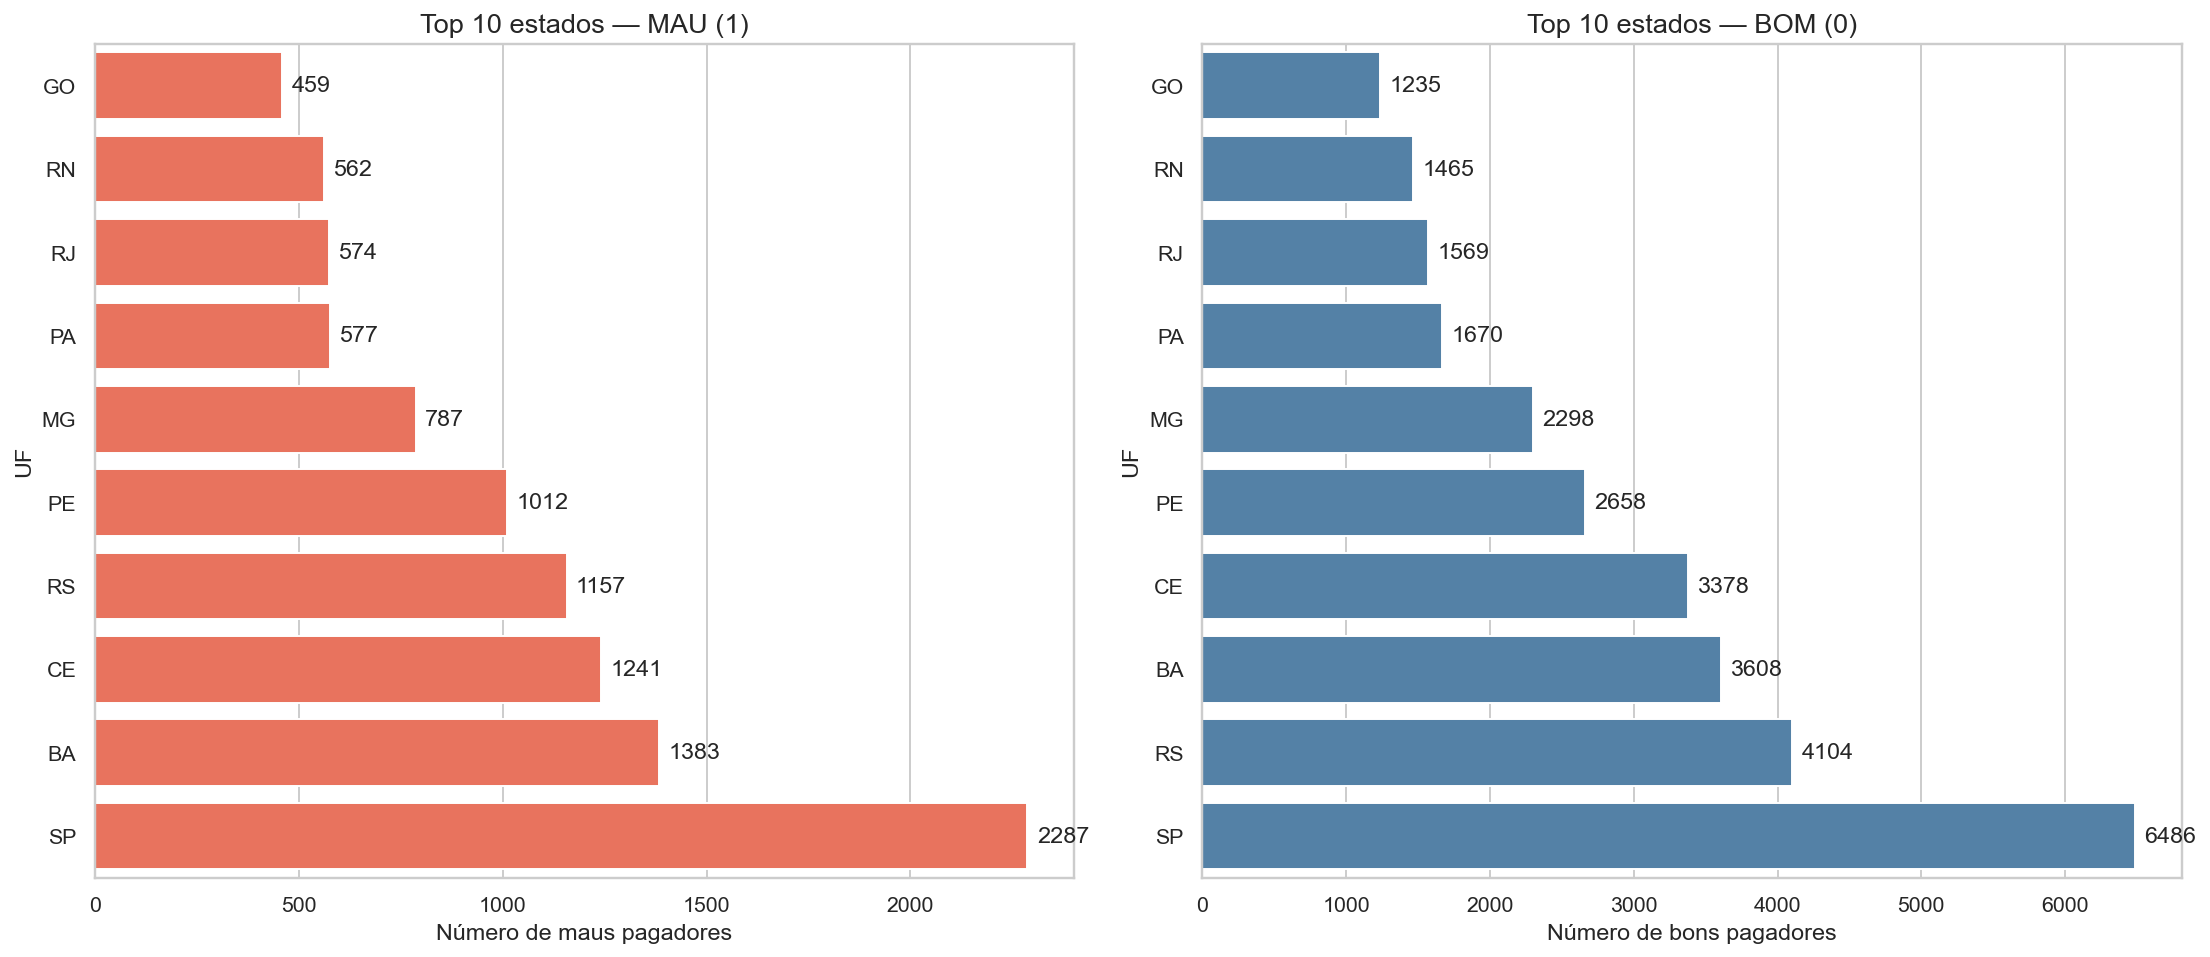

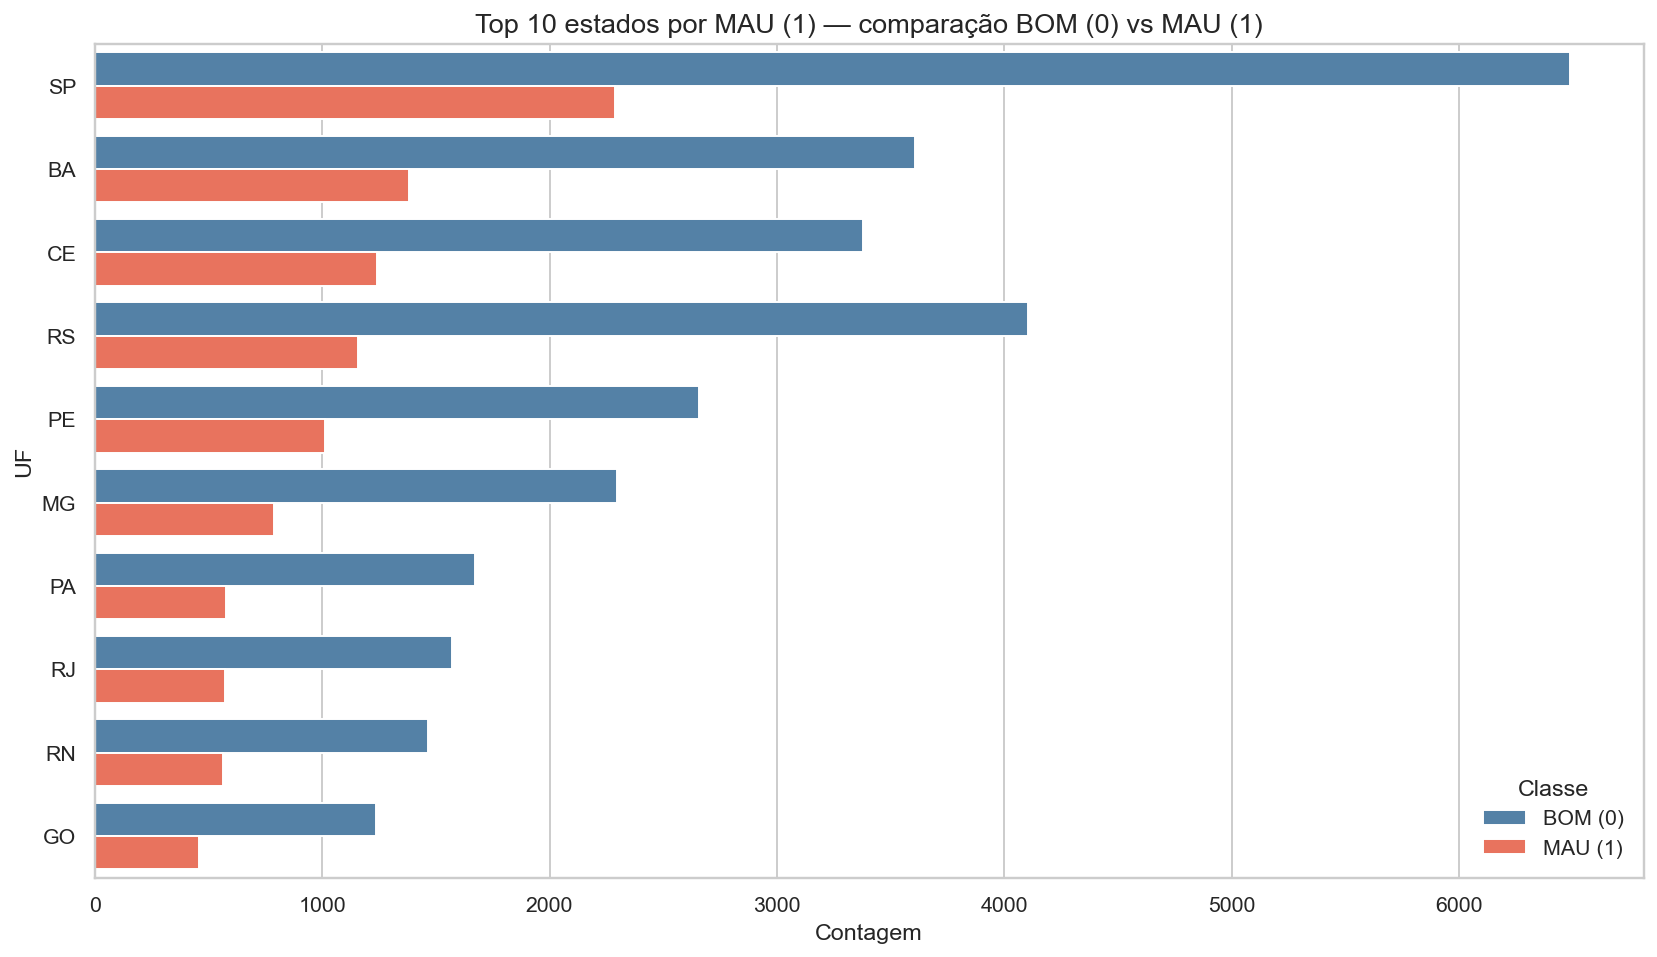

In [26]:
# %% Top 10 estados com maior número de MAU (1) e BOM (0) — gráficos simples e diretos
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# -------- Configurações --------
col_estado = 'ESTADO_RESIDENCIA'     # ajuste se sua coluna de estado tiver outro nome
target = 'ROTULO_ALVO_MAU_1'         # 1 = MAU, 0 = BOM

# Garantir alvo 0/1 numérico
df[target] = pd.to_numeric(df[target], errors='coerce').astype('Int64')
df['target_num'] = df[target].astype('int')

# Padronizar UF (se vier nome completo, mapear para siglas)
df[col_estado] = df[col_estado].astype('string').str.upper().str.strip()
uf_map = {
    'ACRE':'AC','ALAGOAS':'AL','AMAPÁ':'AP','AMAZONAS':'AM','BAHIA':'BA','CEARÁ':'CE','DISTRITO FEDERAL':'DF',
    'ESPÍRITO SANTO':'ES','GOIÁS':'GO','MARANHÃO':'MA','MATO GROSSO':'MT','MATO GROSSO DO SUL':'MS',
    'MINAS GERAIS':'MG','PARÁ':'PA','PARAÍBA':'PB','PARANÁ':'PR','PERNAMBUCO':'PE','PIAUÍ':'PI',
    'RIO DE JANEIRO':'RJ','RIO GRANDE DO NORTE':'RN','RIO GRANDE DO SUL':'RS','RONDÔNIA':'RO','RORAIMA':'RR',
    'SANTA CATARINA':'SC','SÃO PAULO':'SP','SERGIPE':'SE','TOCANTINS':'TO'
}
mask_nome = df[col_estado].str.len() > 2
df.loc[mask_nome, col_estado] = df.loc[mask_nome, col_estado].map(uf_map).fillna(df.loc[mask_nome, col_estado])

ufs_validas = set(['AC','AL','AP','AM','BA','CE','DF','ES','GO','MA','MT','MS','MG','PA','PB','PR','PE','PI','RJ','RN','RS','RO','RR','SC','SP','SE','TO'])
df_uf = df[df[col_estado].isin(ufs_validas)].copy()

# -------- Contagens por classe --------
cont_uf = pd.crosstab(df_uf[col_estado], df_uf['target_num'])  # colunas: 0=BOM, 1=MAU
cont_uf = cont_uf.rename(columns={0:'BOM (0)', 1:'MAU (1)'})

# Top 10 por MAU e Top 10 por BOM
top10_mau = cont_uf.sort_values('MAU (1)', ascending=False).head(10)
top10_bom = cont_uf.sort_values('BOM (0)', ascending=False).head(10)

# -------- Gráficos lado a lado (MAU e BOM) --------
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=False)

# MAU (1)
dados_mau = top10_mau['MAU (1)'].sort_values(ascending=True)  # ascending para barras horizontais ordenadas
sns.barplot(x=dados_mau.values, y=dados_mau.index, color='tomato', ax=axes[0])
axes[0].set_title('Top 10 estados — MAU (1)')
axes[0].set_xlabel('Número de maus pagadores')
axes[0].set_ylabel('UF')
# rótulos com valores
for i, v in enumerate(dados_mau.values):
    axes[0].text(v + max(dados_mau.values)*0.01, i, f'{int(v)}', va='center')

# BOM (0)
dados_bom = top10_bom['BOM (0)'].sort_values(ascending=True)
sns.barplot(x=dados_bom.values, y=dados_bom.index, color='steelblue', ax=axes[1])
axes[1].set_title('Top 10 estados — BOM (0)')
axes[1].set_xlabel('Número de bons pagadores')
axes[1].set_ylabel('UF')
for i, v in enumerate(dados_bom.values):
    axes[1].text(v + max(dados_bom.values)*0.01, i, f'{int(v)}', va='center')

plt.tight_layout()
plt.show()

# -------- Gráfico combinado (comparação direta) --------
# Usa os mesmos estados do Top 10 MAU e plota BOM vs MAU lado a lado para esses estados (comparabilidade no “top risco”)
comb = top10_mau[['BOM (0)','MAU (1)']].copy()
comb = comb.sort_values('MAU (1)', ascending=False)

comb_plot = comb.reset_index().melt(id_vars=col_estado, var_name='classe', value_name='contagem')
plt.figure(figsize=(12, 7))
sns.barplot(data=comb_plot, y=col_estado, x='contagem', hue='classe', palette=['steelblue','tomato'])
plt.title('Top 10 estados por MAU (1) — comparação BOM (0) vs MAU (1)')
plt.xlabel('Contagem'); plt.ylabel('UF')
plt.legend(title='Classe', loc='lower right')
plt.tight_layout()
plt.show()

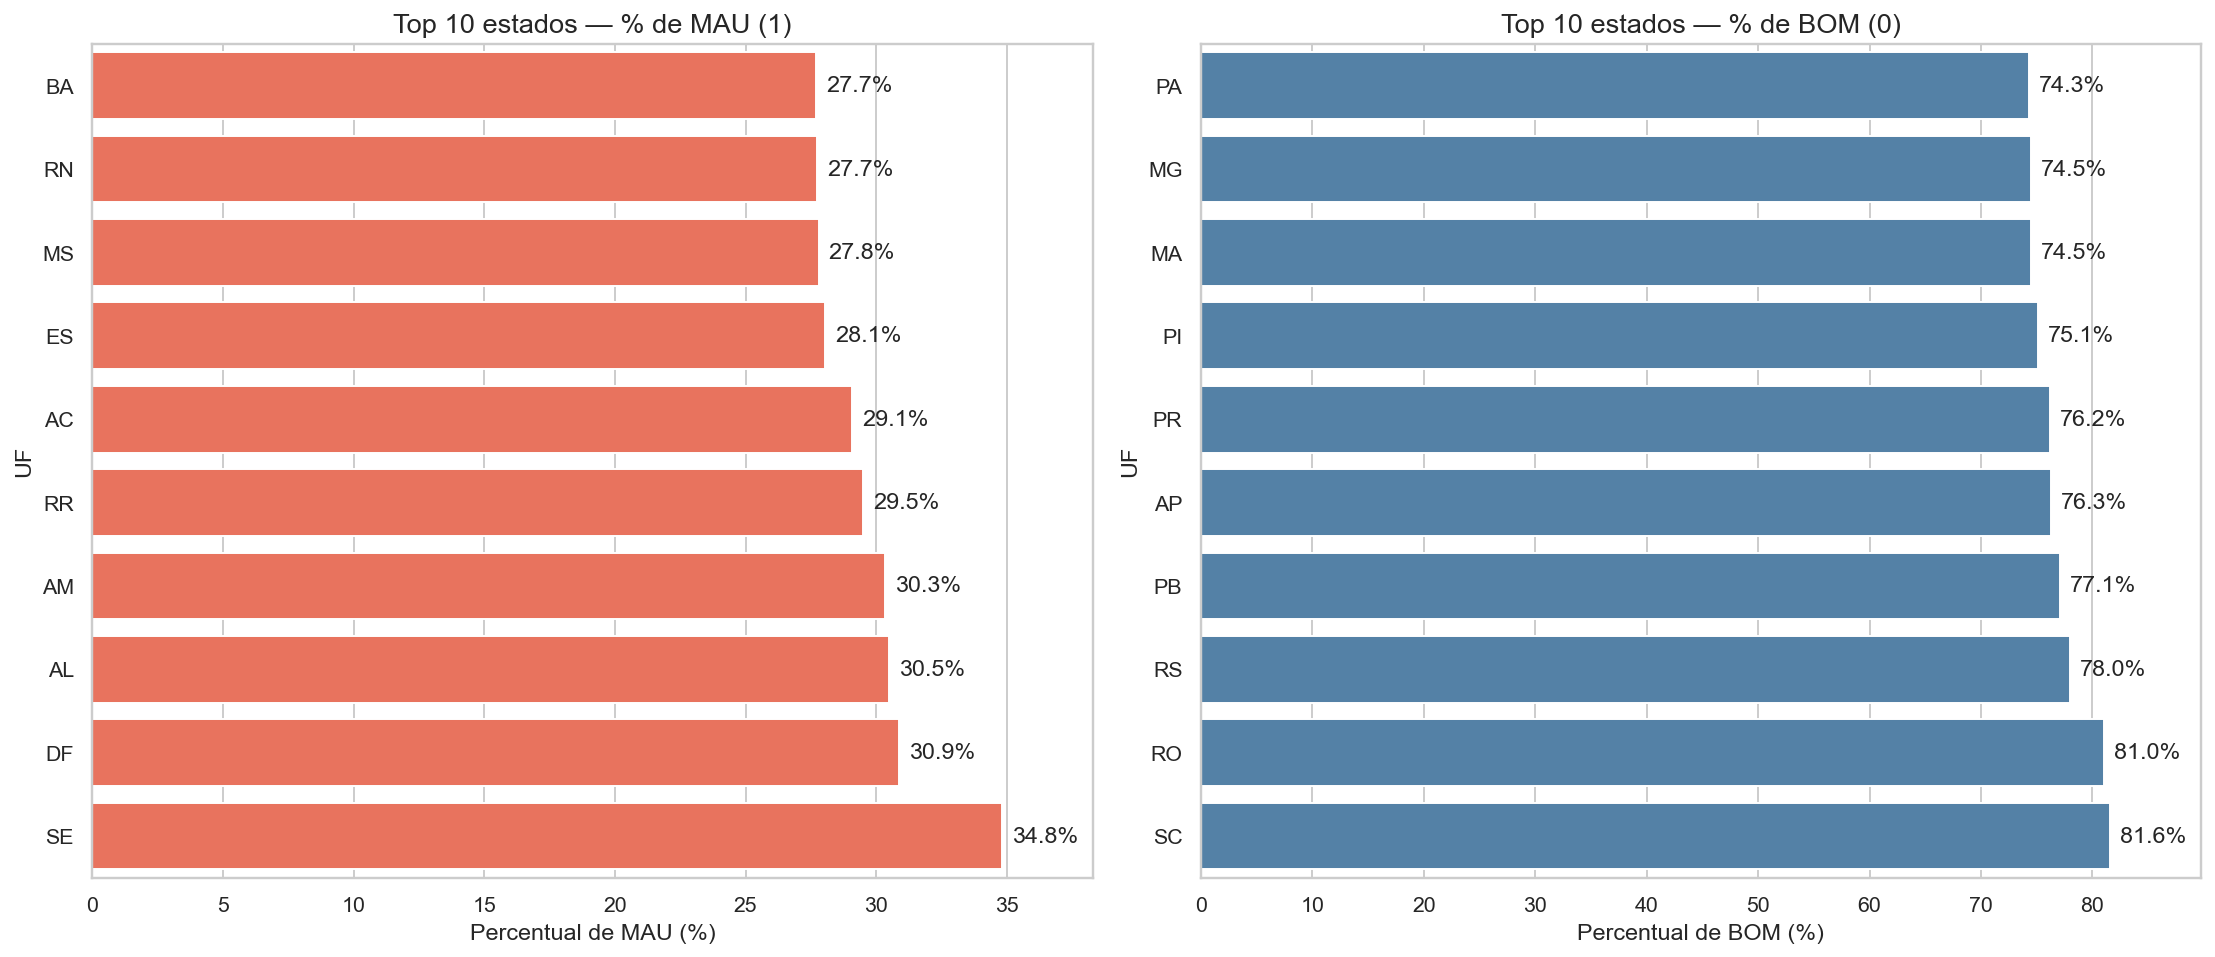


Interpretação:
- Os gráficos mostram os Top 10 estados por PROPORÇÃO (%), não por contagem absoluta.
- Em “% MAU”, ordenamos do maior para o menor risco relativo na UF; “% BOM” mostra o inverso.
- Use as proporções para comparar estados independentemente do tamanho da base em cada UF.


In [27]:
# %% Top 10 estados por percentual de MAU (1) e BOM (0)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# -------- Configurações --------
col_estado = 'ESTADO_RESIDENCIA'     # ajuste se sua coluna de estado tiver outro nome
target = 'ROTULO_ALVO_MAU_1'         # 1 = MAU, 0 = BOM

# Garantir alvo 0/1 numérico
df[target] = pd.to_numeric(df[target], errors='coerce').astype('Int64')
df['target_num'] = df[target].astype('int')

# Padronizar UF (se vier nome completo, mapear para siglas)
df[col_estado] = df[col_estado].astype('string').str.upper().str.strip()
uf_map = {
    'ACRE':'AC','ALAGOAS':'AL','AMAPÁ':'AP','AMAZONAS':'AM','BAHIA':'BA','CEARÁ':'CE','DISTRITO FEDERAL':'DF',
    'ESPÍRITO SANTO':'ES','GOIÁS':'GO','MARANHÃO':'MA','MATO GROSSO':'MT','MATO GROSSO DO SUL':'MS',
    'MINAS GERAIS':'MG','PARÁ':'PA','PARAÍBA':'PB','PARANÁ':'PR','PERNAMBUCO':'PE','PIAUÍ':'PI',
    'RIO DE JANEIRO':'RJ','RIO GRANDE DO NORTE':'RN','RIO GRANDE DO SUL':'RS','RONDÔNIA':'RO','RORAIMA':'RR',
    'SANTA CATARINA':'SC','SÃO PAULO':'SP','SERGIPE':'SE','TOCANTINS':'TO'
}
mask_nome = df[col_estado].str.len() > 2
df.loc[mask_nome, col_estado] = df.loc[mask_nome, col_estado].map(uf_map).fillna(df.loc[mask_nome, col_estado])

ufs_validas = set(['AC','AL','AP','AM','BA','CE','DF','ES','GO','MA','MT','MS','MG','PA','PB','PR','PE','PI','RJ','RN','RS','RO','RR','SC','SP','SE','TO'])
df_uf = df[df[col_estado].isin(ufs_validas)].copy()

# -------- Percentuais por UF --------
# Tabela de contagens por UF e classe (0=BOM, 1=MAU)
cont_uf = pd.crosstab(df_uf[col_estado], df_uf['target_num']).rename(columns={0:'BOM', 1:'MAU'})

# Evitar divisão por zero e calcular proporções
totais = cont_uf.sum(axis=1).replace(0, np.nan)
prop = cont_uf.div(totais, axis=0)  # proporção 0..1
prop = prop.fillna(0.0)             # se UF sem dados válidos, zera

# Top 10 por % MAU e Top 10 por % BOM
top10_mau_pct = prop.sort_values('MAU', ascending=False).head(10)
top10_bom_pct = prop.sort_values('BOM', ascending=False).head(10)

# -------- Gráficos (percentuais) --------
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=False)

# MAU (1) — percentuais
dados_mau = (top10_mau_pct['MAU'] * 100).sort_values(ascending=True)  # em %
sns.barplot(x=dados_mau.values, y=dados_mau.index, color='tomato', ax=axes[0])
axes[0].set_title('Top 10 estados — % de MAU (1)')
axes[0].set_xlabel('Percentual de MAU (%)')
axes[0].set_ylabel('UF')
xmax = max(dados_mau.values) * 1.10 if len(dados_mau) else 1
axes[0].set_xlim(0, xmax)
for i, v in enumerate(dados_mau.values):
    axes[0].text(v + xmax*0.01, i, f'{v:.1f}%', va='center')

# BOM (0) — percentuais
dados_bom = (top10_bom_pct['BOM'] * 100).sort_values(ascending=True)
sns.barplot(x=dados_bom.values, y=dados_bom.index, color='steelblue', ax=axes[1])
axes[1].set_title('Top 10 estados — % de BOM (0)')
axes[1].set_xlabel('Percentual de BOM (%)')
axes[1].set_ylabel('UF')
xmax2 = max(dados_bom.values) * 1.10 if len(dados_bom) else 1
axes[1].set_xlim(0, xmax2)
for i, v in enumerate(dados_bom.values):
    axes[1].text(v + xmax2*0.01, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

# -------- Interpretação (console) --------
print('\nInterpretação:')
print('- Os gráficos mostram os Top 10 estados por PROPORÇÃO (%), não por contagem absoluta.')
print('- Em “% MAU”, ordenamos do maior para o menor risco relativo na UF; “% BOM” mostra o inverso.')
print('- Use as proporções para comparar estados independentemente do tamanho da base em cada UF.')


Segundo os gráficos, nos estados do Sul vemos uma maior taxa de bons pagadores enquanto no nordeste e norte temos os maiores percentuais de maus pagadores.

### 2.3 Use boxplot para explicar como o tipo de residência interfere na classificação do pagador

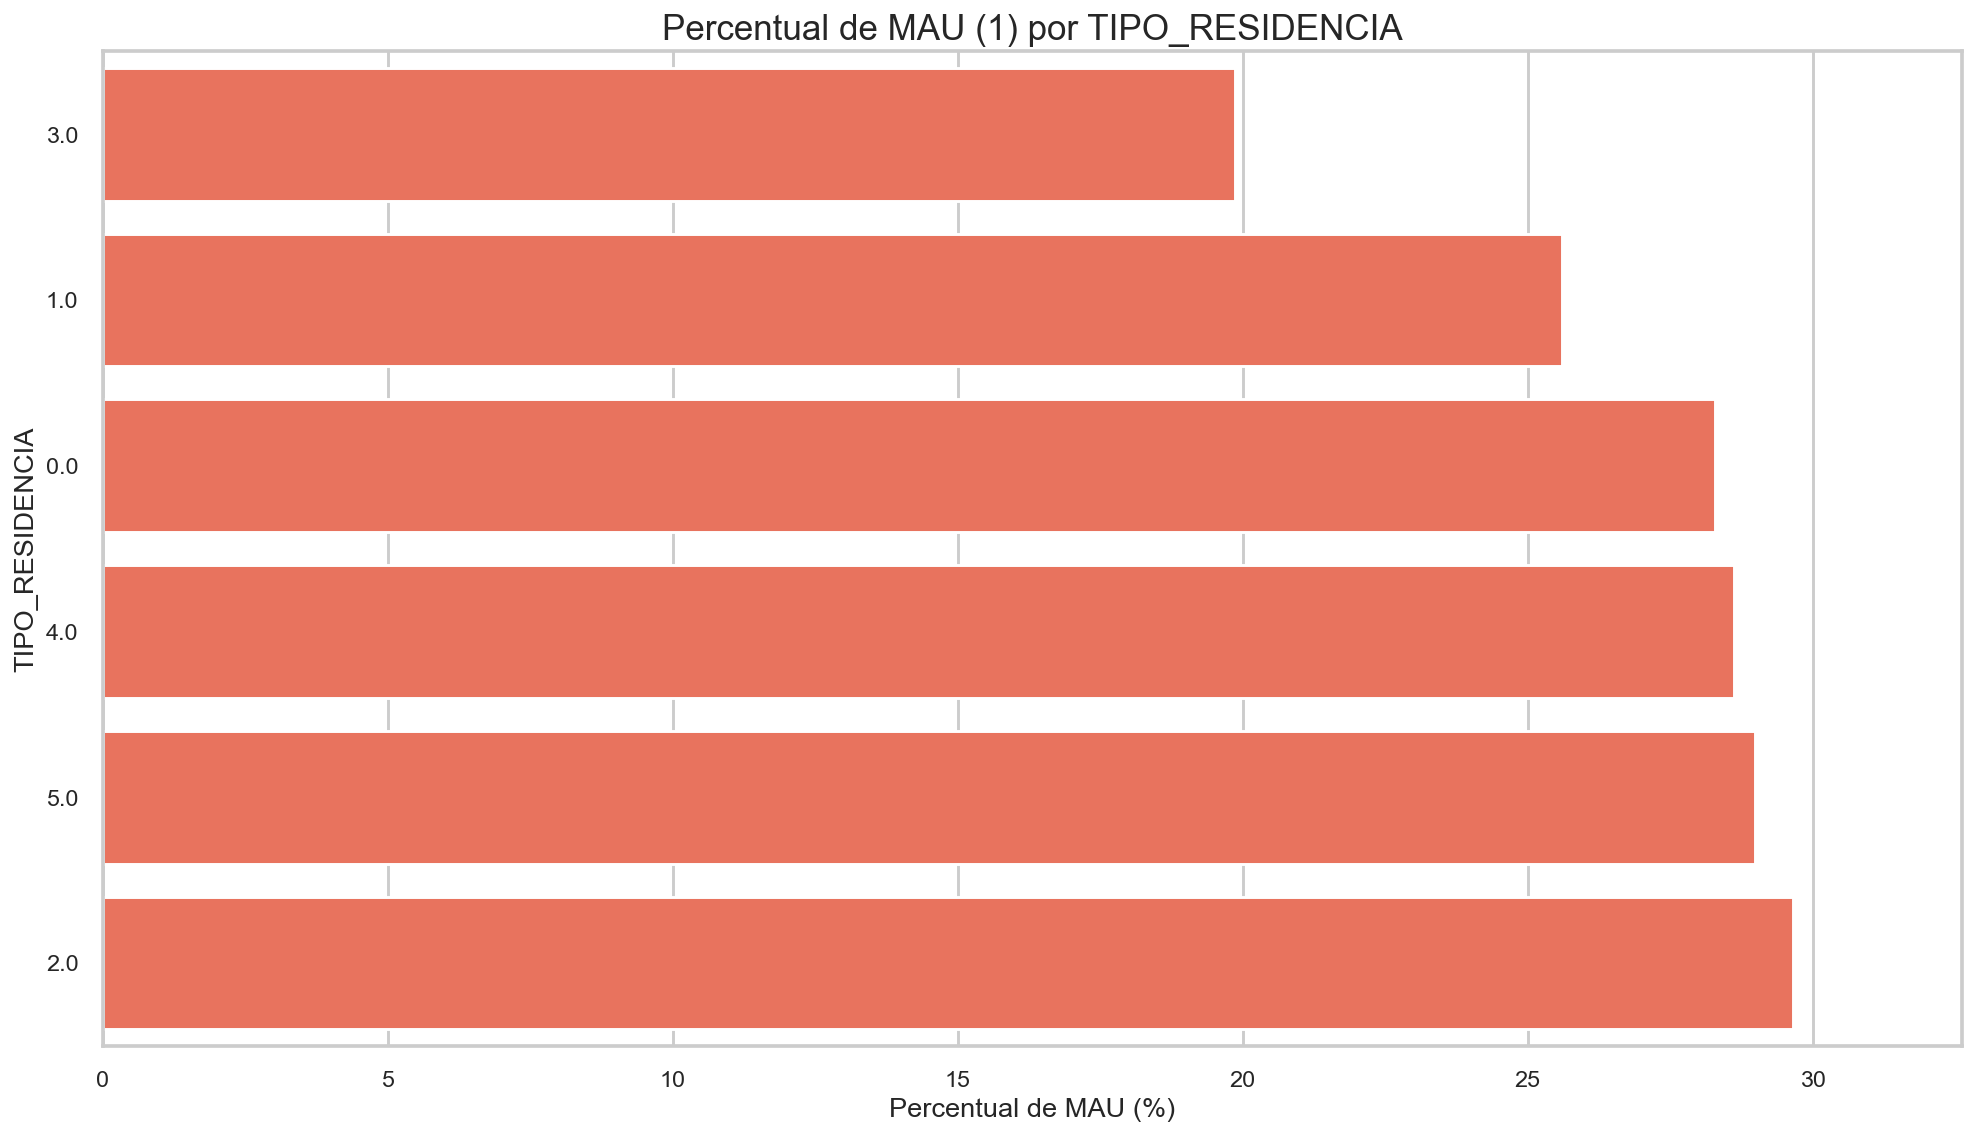

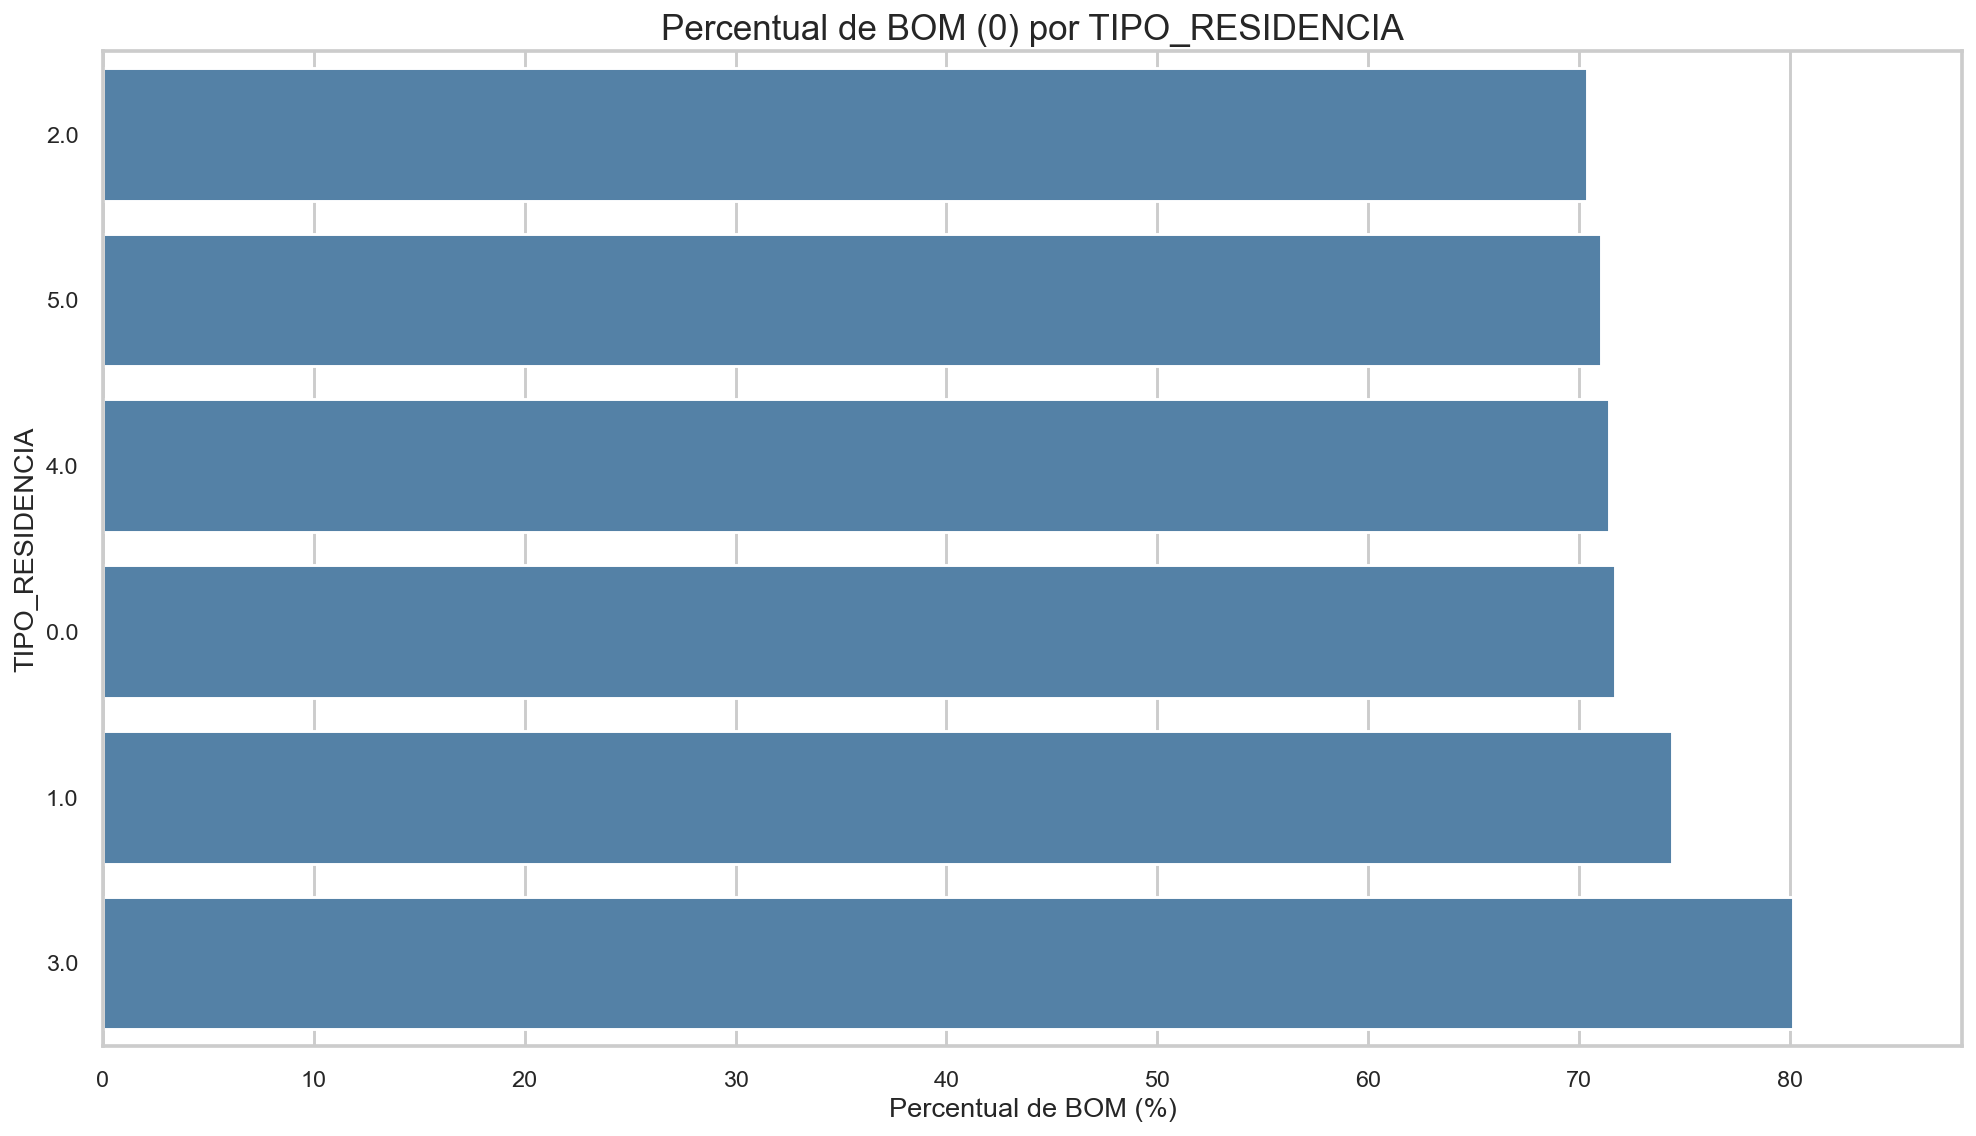

In [28]:

# %% VISUALIZAÇÕES HARMONIZADAS — % MAU (1) e % BOM (0) por categoria (layout semelhante)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ------------------------
# Configurações gerais (mantém layout anterior)
# ------------------------
sns.set_theme(style='whitegrid', context='talk')  # fonte maior e grade leve
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

def plot_bom_mau_by_category(
    df: pd.DataFrame,
    cat_col: str,
    target_col: str = 'ROTULO_ALVO_MAU_1',
    min_freq: int = 30,
    save: bool = False,
    outdir: str = 'plots'
):
    """
    Gera dois gráficos independentes e harmonizados:
      - Gráfico 1: % MAU (1) por categoria (barras horizontais em 'tomato').
      - Gráfico 2: % BOM (0) por categoria (barras horizontais em 'steelblue').
    Mantém o layout e estilo do código anterior.
    Retorna (prop, prop_mau, prop_bom) para reuso.
    """
    # ------------------------
    # Checagens e preparação
    # ------------------------
    if cat_col not in df.columns:
        raise KeyError(f"A coluna '{cat_col}' não foi encontrada no DataFrame.")
    if target_col not in df.columns:
        raise KeyError(f"A coluna de alvo '{target_col}' não foi encontrada no DataFrame.")

    # Alvo 0/1 (nullable) e categórica limpa
    df_local = df.copy()
    df_local[target_col] = pd.to_numeric(df_local[target_col], errors='coerce').astype('Int64')
    df_local['target_num'] = df_local[target_col]  # Int64 para suportar NaN
    df_local[cat_col] = df_local[cat_col].astype('string').str.strip()

    # Mantém apenas linhas com alvo válido
    df_valid = df_local.dropna(subset=['target_num']).copy()

    # Crosstab: contagens por categoria e classe
    cont = pd.crosstab(df_valid[cat_col], df_valid['target_num'])

    # Garante colunas BOM/MAU mesmo que estejam ausentes
    if 0 not in cont.columns:
        cont[0] = 0
    if 1 not in cont.columns:
        cont[1] = 0
    cont = cont.rename(columns={0: 'BOM', 1: 'MAU'})
    cont['total'] = cont[['BOM', 'MAU']].sum(axis=1)

    # Filtra categorias com frequência mínima (corrigindo &gt;= -> >=)
    cont_f = cont[cont['total'] >= min_freq].copy()
    if cont_f.empty:
        print(f"[INFO] Nenhuma categoria em '{cat_col}' atingiu frequência >= {min_freq}. "
              f"Reduzindo limite para {max(1, min_freq // 2)} para exibir algo.")
        cont_f = cont[cont['total'] >= max(1, min_freq // 2)].copy()
        if cont_f.empty:
            cont_f = cont.copy()

    # Proporções 0..1 (evita div/0)
    prop = cont_f[['BOM', 'MAU']].div(cont_f['total'].replace(0, np.nan), axis=0).fillna(0.0)

    # Ordenações separadas (crescente no gráfico, igual ao layout anterior)
    ordem_mau = prop.sort_values('MAU', ascending=False).index.tolist()
    ordem_bom = prop.sort_values('BOM', ascending=False).index.tolist()

    # DataFrames prontos para plot (percentual)
    prop_mau = (
        (prop.loc[ordem_mau, 'MAU'] * 100.0)
        .to_frame('pct_mau')
        .reset_index()
        .rename(columns={cat_col: 'categoria'})
    )

    prop_bom = (
        (prop.loc[ordem_bom, 'BOM'] * 100.0)
        .to_frame('pct_bom')
        .reset_index()
        .rename(columns={cat_col: 'categoria'})
    )

    # ------------------------
    # Gráfico 1 — % MAU (1) por categoria
    # ------------------------
    fig1, ax1 = plt.subplots(constrained_layout=True)
    sns.barplot(
        data=prop_mau.sort_values('pct_mau', ascending=True),  # barras horizontais, ordem crescente
        x='pct_mau', y='categoria',
        color='tomato', ax=ax1
    )
    ax1.set_title(f'Percentual de MAU (1) por {cat_col}')
    ax1.set_xlabel('Percentual de MAU (%)')
    ax1.set_ylabel(cat_col)

    xmax_mau = (prop_mau['pct_mau'].max() if len(prop_mau) else 1.0) * 1.10
    ax1.set_xlim(0, xmax_mau)

    # Quebra de linha para rótulos longos
    for label in ax1.get_yticklabels():
        label.set_wrap(True)

    if save:
        os.makedirs(outdir, exist_ok=True)
        f1 = os.path.join(outdir, f"pct_mau_por_{cat_col}.png")
        fig1.savefig(f1, dpi=160, bbox_inches="tight")
        print(f"[OK] Salvo: {f1}")

    plt.show()

    # ------------------------
    # Gráfico 2 — % BOM (0) por categoria
    # ------------------------
    fig2, ax2 = plt.subplots(constrained_layout=True)
    sns.barplot(
        data=prop_bom.sort_values('pct_bom', ascending=True),
        x='pct_bom', y='categoria',
        color='steelblue', ax=ax2
    )
    ax2.set_title(f'Percentual de BOM (0) por {cat_col}')
    ax2.set_xlabel('Percentual de BOM (%)')
    ax2.set_ylabel(cat_col)

    xmax_bom = (prop_bom['pct_bom'].max() if len(prop_bom) else 1.0) * 1.10
    ax2.set_xlim(0, xmax_bom)

    for label in ax2.get_yticklabels():
        label.set_wrap(True)

    if save:
        os.makedirs(outdir, exist_ok=True)
        f2 = os.path.join(outdir, f"pct_bom_por_{cat_col}.png")
        fig2.savefig(f2, dpi=160, bbox_inches="tight")
        print(f"[OK] Salvo: {f2}")

    plt.show()

    # >>> Retorna os dataframes para você poder guardar/inspecionar
    return prop, prop_mau, prop_bom

# ------------------------
# Exemplo de uso (mesmo layout)
# ------------------------
prop_res, prop_mau_res, prop_bom_res = plot_bom_mau_by_category(
    df, cat_col='TIPO_RESIDENCIA',
    min_freq=30,
    save=False  # mude para True para salvar PNG em ./plots
)


Target MAU=1: Predominantemente possuem residência do tipo 2, 5 e 4
Target BOM=0: Predominantemente possuem residência do tipo 3, 1 e 0

### 2.4 Como as features renda pessoal mensal e outras rendas se relacionam com a variável meta? (obs: não é correlação estatística)

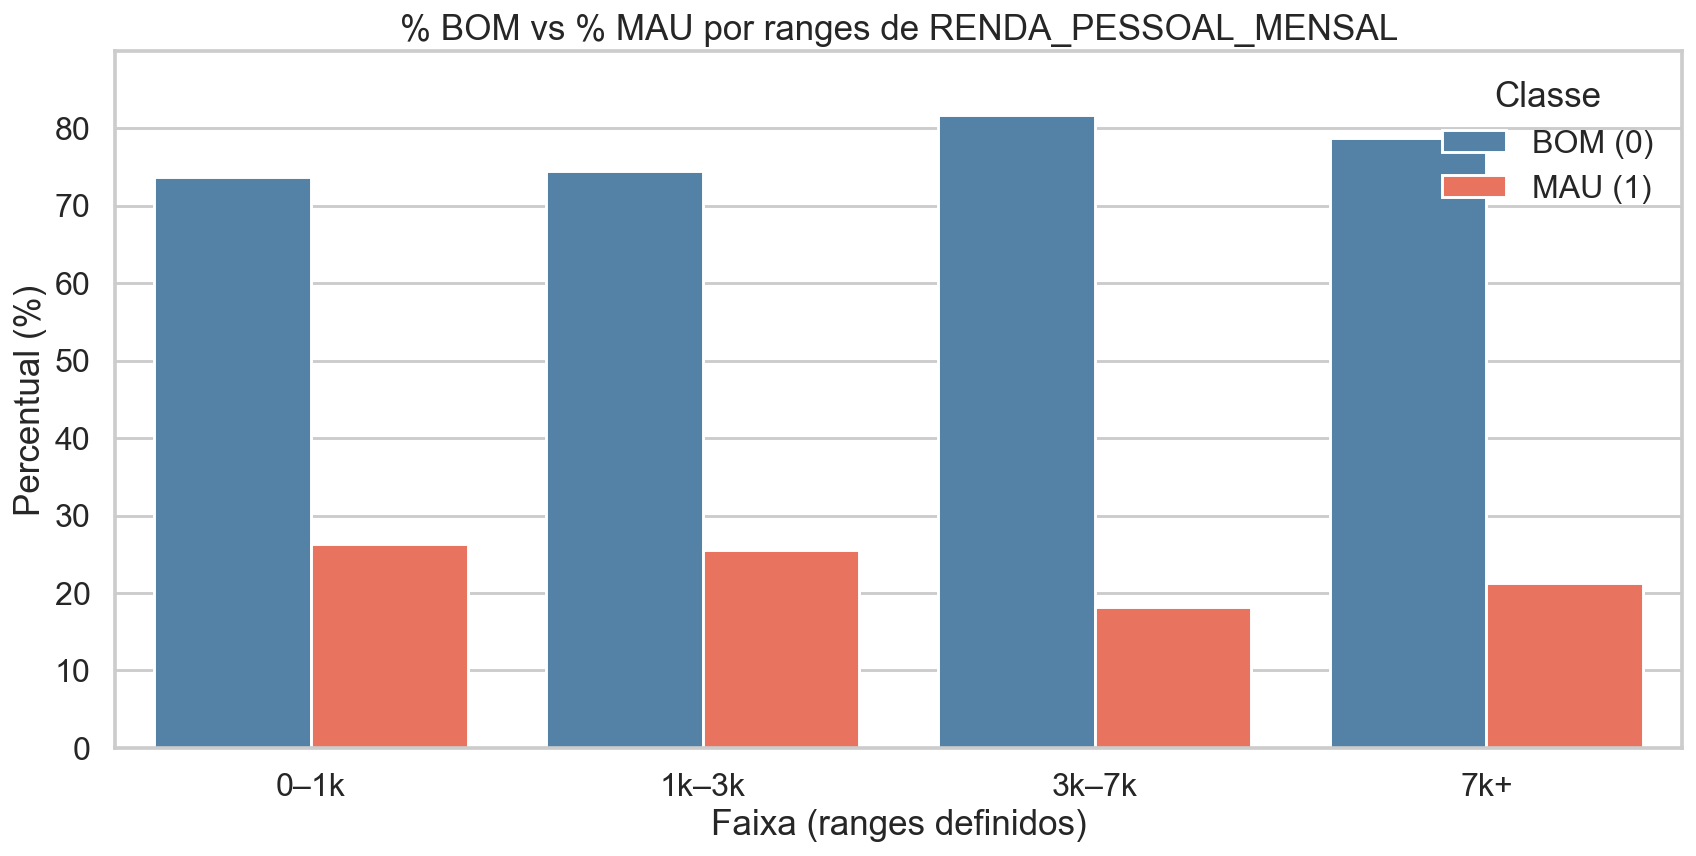

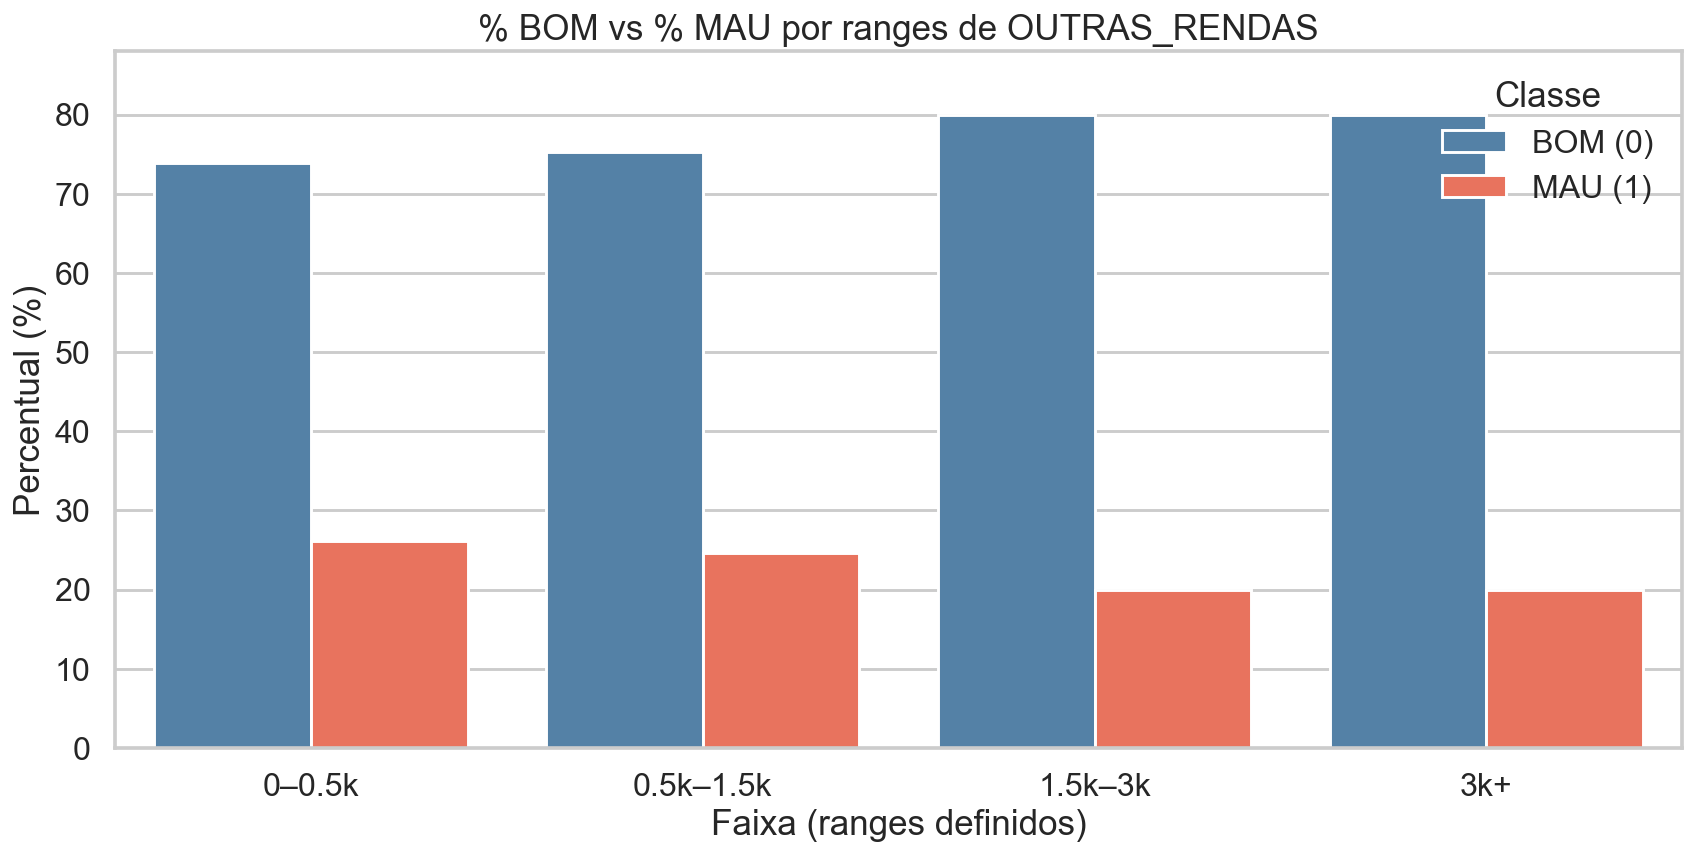

In [29]:
# %% Barras lado a lado (% BOM vs % MAU) por RANGES definidos de RENDA_PESSOAL_MENSAL e OUTRAS_RENDAS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------
# Configuração visual
# --------------------------
sns.set_theme(style='whitegrid', context='talk')
PALETTE = {'BOM (0)': 'steelblue', 'MAU (1)': 'tomato'}

# --------------------------
# Parâmetros / colunas
# --------------------------
target = 'ROTULO_ALVO_MAU_1'                     # 1 = MAU, 0 = BOM
vars_num = ['RENDA_PESSOAL_MENSAL', 'OUTRAS_RENDAS']  # ajuste se necessário

# >>>>> DEFINA AQUI OS RANGES (bordas) PARA CADA VARIÁVEL <<<<<
# Exemplo de ranges (em unidades da sua base). Você pode adaptar: salário, outras rendas, etc.
RANGES = {
    'RENDA_PESSOAL_MENSAL': [0, 1000, 3000, 7000, np.inf],  # 0–1000, 1000–3000, 3000–7000, 7000+
    'OUTRAS_RENDAS':        [0, 500, 1500, 3000, np.inf]    # 0–500, 500–1500, 1500–3000, 3000+
}
# Labels correspondentes (se quiser nomes custom). Se não fornecer, serão gerados automaticamente.
RANGE_LABELS = {
    'RENDA_PESSOAL_MENSAL': ['0–1k', '1k–3k', '3k–7k', '7k+'],
    'OUTRAS_RENDAS':        ['0–0.5k', '0.5k–1.5k', '1.5k–3k', '3k+']
}

# --------------------------
# Preparação do DataFrame
# --------------------------
df[target] = pd.to_numeric(df[target], errors='coerce').astype('Int64')
df['target_num'] = df[target].astype('int')
df['classe_txt'] = df['target_num'].map({0: 'BOM (0)', 1: 'MAU (1)'}).astype('category')

for c in vars_num:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    else:
        raise KeyError(f'Coluna não encontrada: {c}')

# --------------------------
# Utilitários pythônicos
# --------------------------
def faixa_por_ranges(s: pd.Series, edges: list[float], labels: list[str] | None = None) -> pd.Series:
    """
    Faz binning de s em ranges definidos por 'edges' (lista de bordas).
    Retorna Series categórica com os rótulos das faixas.
    """
    if labels is None or len(labels) != (len(edges) - 1):
        # Gera labels automaticamente (ex.: [0,1000,3000,np.inf] -> '0–1k', '1k–3k', '3k+')
        auto_labels = []
        for i in range(len(edges) - 1):
            lo, hi = edges[i], edges[i + 1]
            if np.isinf(hi):
                auto_labels.append(f'{int(lo)}+')
            else:
                auto_labels.append(f'{int(lo)}–{int(hi)}')
        labels = auto_labels
    return pd.cut(s, bins=edges, labels=labels, include_lowest=True, right=False)

def percentuais_bom_mau_por_faixa(df_in: pd.DataFrame, faixa_col: str) -> pd.DataFrame:
    """
    A partir de df_in com coluna de faixa e target_num, retorna % BOM e % MAU por faixa.
    """
    tab = pd.crosstab(df_in[faixa_col], df_in['target_num']).rename(columns={0: 'BOM', 1: 'MAU'}).astype(float)
    totais = tab.sum(axis=1).replace(0, np.nan)
    pct = tab.div(totais, axis=0).fillna(0.0)  # proporções
    pct = pct.assign(pct_bom=pct['BOM'] * 100, pct_mau=pct['MAU'] * 100, freq=totais).reset_index()
    pct = pct.rename(columns={faixa_col: 'faixa'})
    return pct

def plot_barras_lado_a_lado(pct_df: pd.DataFrame, titulo: str) -> None:
    """
    Plota barras lado a lado (% BOM vs % MAU) por faixa, com layout harmonizado.
    """
    plot_df = pct_df.melt(id_vars=['faixa', 'freq'], value_vars=['pct_bom', 'pct_mau'],
                          var_name='classe', value_name='percentual')
    plot_df['classe'] = plot_df['classe'].map({'pct_bom': 'BOM (0)', 'pct_mau': 'MAU (1)'})
    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
    sns.barplot(data=plot_df, x='faixa', y='percentual', hue='classe', palette=PALETTE, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel('Faixa (ranges definidos)')
    ax.set_ylabel('Percentual (%)')
    ax.legend(title='Classe', loc='upper right')
    ymax = plot_df['percentual'].max() * 1.10 if len(plot_df) else 100
    ax.set_ylim(0, ymax)
    for tick in ax.get_xticklabels():
        tick.set_rotation(0)
        tick.set_horizontalalignment('center')
    plt.show()

# --------------------------
# Execução para cada variável
# --------------------------
for col in vars_num:
    # construir faixas (bins) com edges definidos
    edges = RANGES.get(col)
    if not edges or len(edges) < 2:
        raise ValueError(f'Defina ao menos 2 bordas em RANGES para a coluna {col}.')
    labels = RANGE_LABELS.get(col)

    base = df.dropna(subset=[col, 'target_num']).copy()
    base['faixa_' + col] = faixa_por_ranges(base[col], edges=edges, labels=labels)

    # percentuais por faixa
    pct_df = percentuais_bom_mau_por_faixa(base, faixa_col=('faixa_' + col))

    # plot
    plot_barras_lado_a_lado(pct_df, titulo=f'% BOM vs % MAU por ranges de {col}')

A incidência de maus pagadores ocorrem com mais frequência em rendas mensais até R$1k mas acima de R$7K também, o que pode indicar endividamento. Outro fator a se considerar é que bons pagadores geralmente possuem recursos vindos de outras rendas. 

###  2.5 A idade interfere na classificação do pagador?


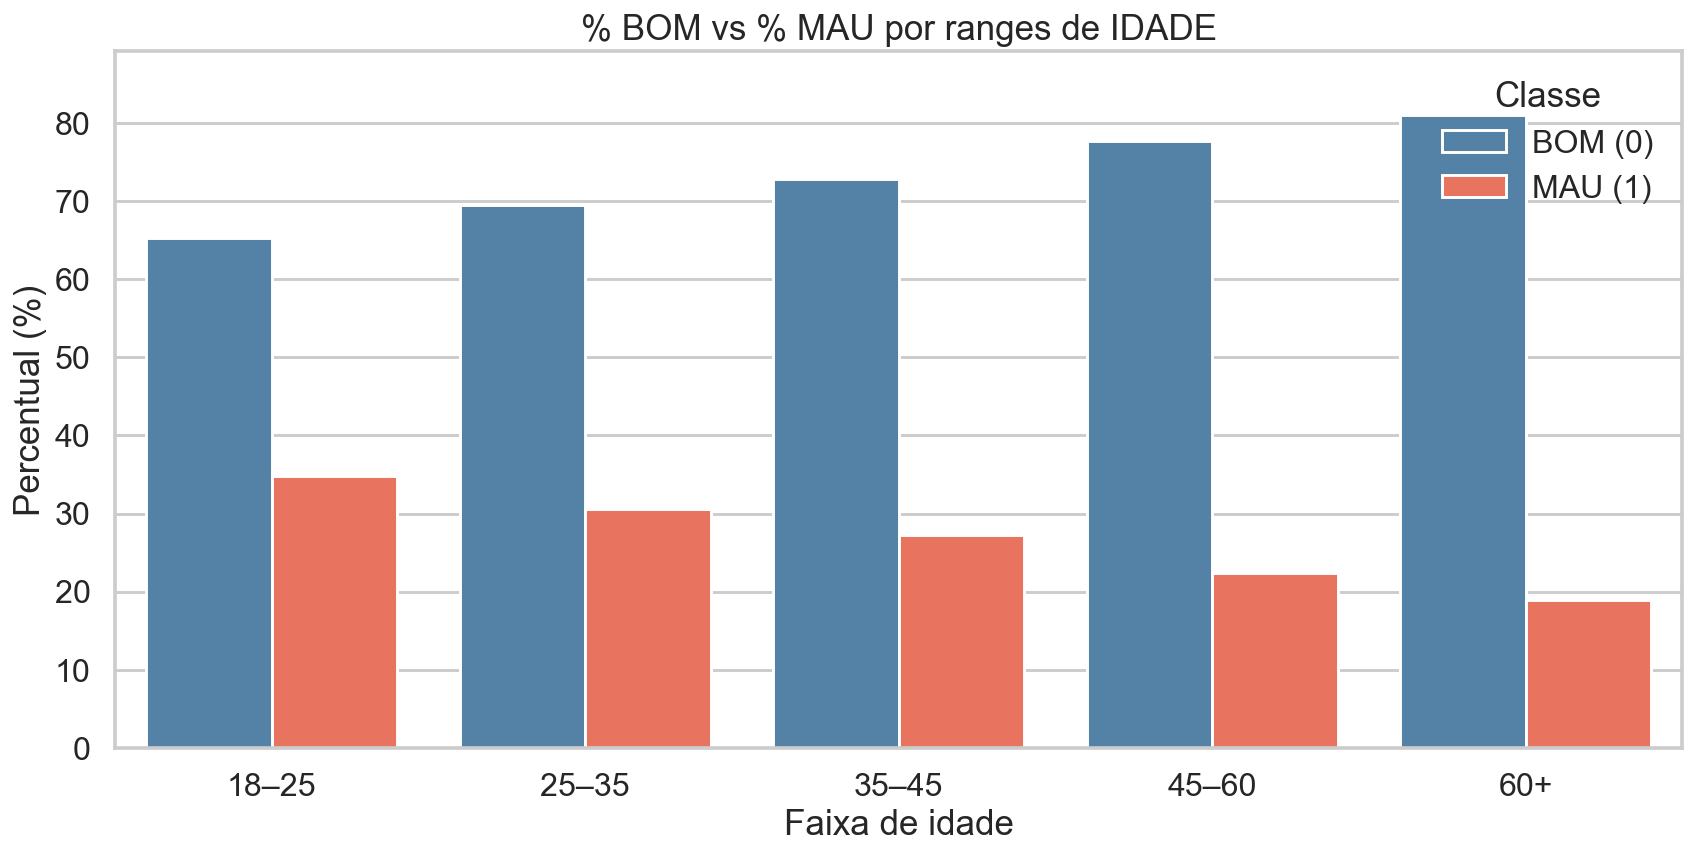

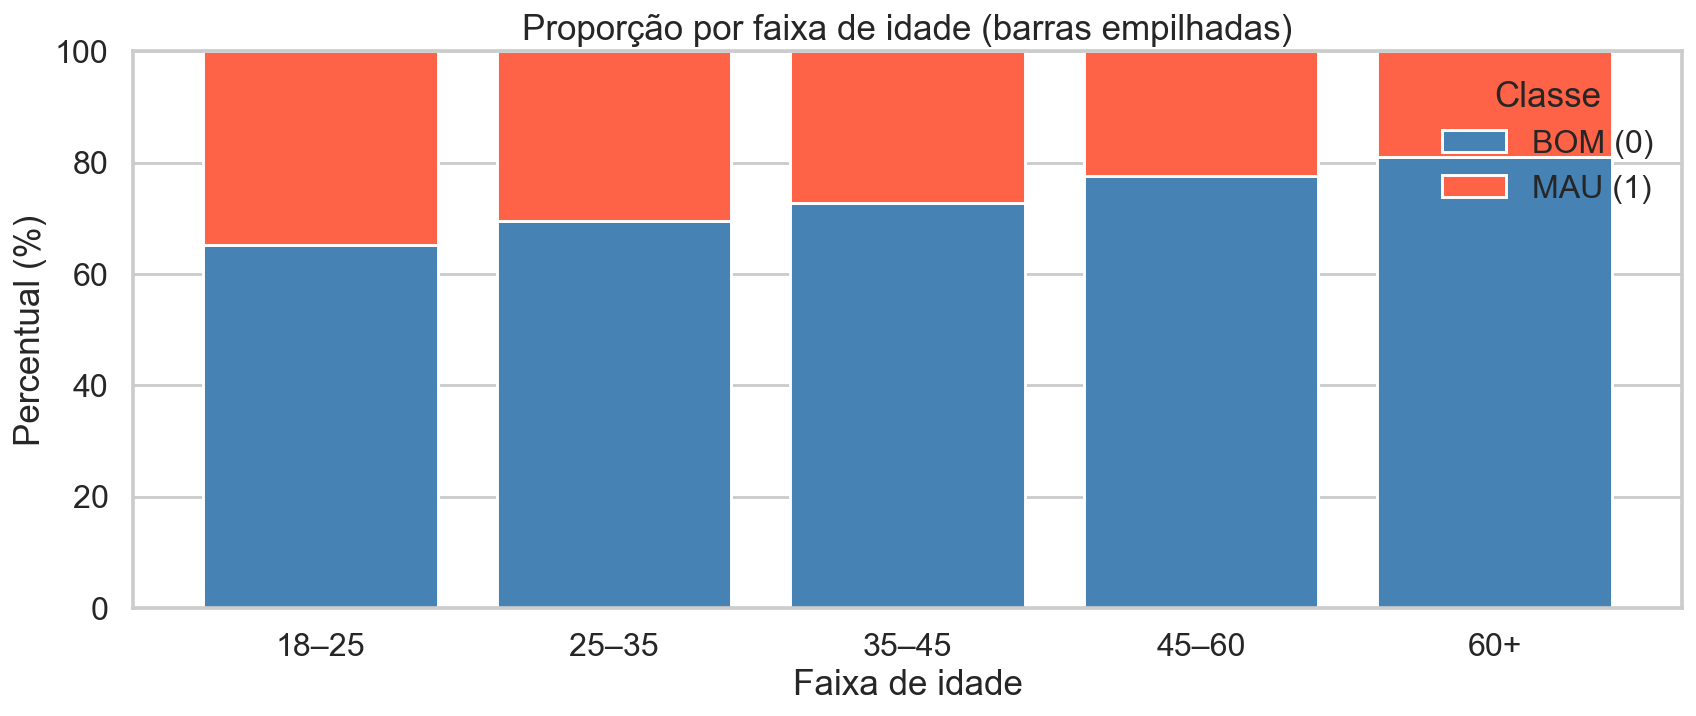

In [30]:
# %% Distribuição por ranges de IDADE — % BOM (0) vs % MAU (1)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------
# Configuração visual
# --------------------------
sns.set_theme(style='whitegrid', context='talk')
PALETTE = {'BOM (0)': 'steelblue', 'MAU (1)': 'tomato'}

# --------------------------
# Parâmetros / colunas
# --------------------------
target = 'ROTULO_ALVO_MAU_1'   # 1 = MAU, 0 = BOM
col_idade = 'IDADE'            # ajuste se necessário

# >>>>> DEFINA AQUI OS RANGES (bordas) PARA IDADE <<<<<
# Exemplo (em anos): 18–25, 25–35, 35–45, 45–60, 60+ (ajuste conforme seu contexto)
AGE_EDGES = [18, 25, 35, 45, 60, np.inf]
AGE_LABELS = ['18–25', '25–35', '35–45', '45–60', '60+']  # deve ter len = len(AGE_EDGES) - 1

# --------------------------
# Preparação do DataFrame
# --------------------------
# alvo 0/1 + rótulo textual
df[target] = pd.to_numeric(df[target], errors='coerce').astype('Int64')
df['target_num'] = df[target].astype('int')
df['classe_txt'] = df['target_num'].map({0: 'BOM (0)', 1: 'MAU (1)'}).astype('category')

# idade numérica
df[col_idade] = pd.to_numeric(df[col_idade], errors='coerce')

# manter apenas linhas válidas
base = df.dropna(subset=[col_idade, 'target_num']).copy()

# --------------------------
# Binning por ranges de idade
# --------------------------
# Se os labels não tiverem o comprimento correto, gerar automaticamente
if AGE_LABELS is None or len(AGE_LABELS) != (len(AGE_EDGES) - 1):
    auto_labels = []
    for i in range(len(AGE_EDGES) - 1):
        lo, hi = AGE_EDGES[i], AGE_EDGES[i + 1]
        auto_labels.append(f'{int(lo)}–{int(hi) if np.isfinite(hi) else "+"}')
    AGE_LABELS = auto_labels

base['faixa_idade'] = pd.cut(
    base[col_idade], bins=AGE_EDGES, labels=AGE_LABELS,
    include_lowest=True, right=False
)

# --------------------------
# Percentual de BOM e MAU por faixa de idade
# --------------------------
tab = pd.crosstab(base['faixa_idade'], base['target_num']).rename(columns={0:'BOM', 1:'MAU'}).astype(float)
totais = tab.sum(axis=1).replace(0, np.nan)
pct = tab.div(totais, axis=0).fillna(0.0)  # proporções
pct = pct.assign(
    pct_bom=pct['BOM'] * 100,
    pct_mau=pct['MAU'] * 100,
    freq=totais
).reset_index().rename(columns={'faixa_idade': 'faixa'})

# --------------------------
# Gráfico de barras lado a lado (% BOM vs % MAU por faixa)
# --------------------------
plot_df = pct.melt(
    id_vars=['faixa', 'freq'],
    value_vars=['pct_bom', 'pct_mau'],
    var_name='classe', value_name='percentual'
)
plot_df['classe'] = plot_df['classe'].map({'pct_bom': 'BOM (0)', 'pct_mau': 'MAU (1)'})

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
sns.barplot(
    data=plot_df, x='faixa', y='percentual', hue='classe',
    palette=PALETTE, ax=ax
)
ax.set_title('% BOM vs % MAU por ranges de IDADE')
ax.set_xlabel('Faixa de idade')
ax.set_ylabel('Percentual (%)')
ax.legend(title='Classe', loc='upper right')

# Escala Y com margem
ymax = plot_df['percentual'].max() * 1.10 if len(plot_df) else 100
ax.set_ylim(0, ymax)

# Melhorar legibilidade dos rótulos no eixo X
for tick in ax.get_xticklabels():
    tick.set_rotation(0)
    tick.set_horizontalalignment('center')

plt.show()

# --------------------------
# (Opcional) Gráfico empilhado normalizado — proporção por faixa
# --------------------------
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.bar(pct['faixa'], pct['pct_bom'], label='BOM (0)', color='steelblue')
ax.bar(pct['faixa'], pct['pct_mau'], bottom=pct['pct_bom'], label='MAU (1)', color='tomato')
ax.set_title('Proporção por faixa de idade (barras empilhadas)')
ax.set_xlabel('Faixa de idade')
ax.set_ylabel('Percentual (%)')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', title='Classe')
plt.show()


Por fim, depreende-se que idade interfere na classificação de pagador, as variáveis são diretamente proporcionais, ou seja, quanto maior a idade, maior é a proporção de bom pagador.